# Speech Modality — an illustrated, runnable primer

**Audience:** ML engineers who know Transformers but not necessarily DSP.
**Core path (~45 min):** waveform → sampling/bit-depth → speech anatomy →
mel spectrogram → Whisper → WER → timestamps → translation.
**Optional extension (~15 min):** CLAP audio↔text retrieval (§8).

Concept illustrations are **embedded directly in the notebook** (base64), so
it is a single self-contained file that renders anywhere — no `images/`
folder to ship. Live/data figures (waveforms, spectrograms) are produced
**by code** from the actual audio. Sources for the illustrations live in
`./diagram_sources/` if you ever want to regenerate them.

**What runs where:** the signal-processing path (§1–§3) and all live plots
run **offline** — if Hugging Face is unreachable they use a deterministic
synthetic speech sample. The model sections (§4–§6, §8: Whisper, WER on a
real clip, timestamps, translation, CLAP) need `torch` + `transformers` +
`datasets` and network/model cache; without them they print a clear notice
plus the expected output rather than crashing.

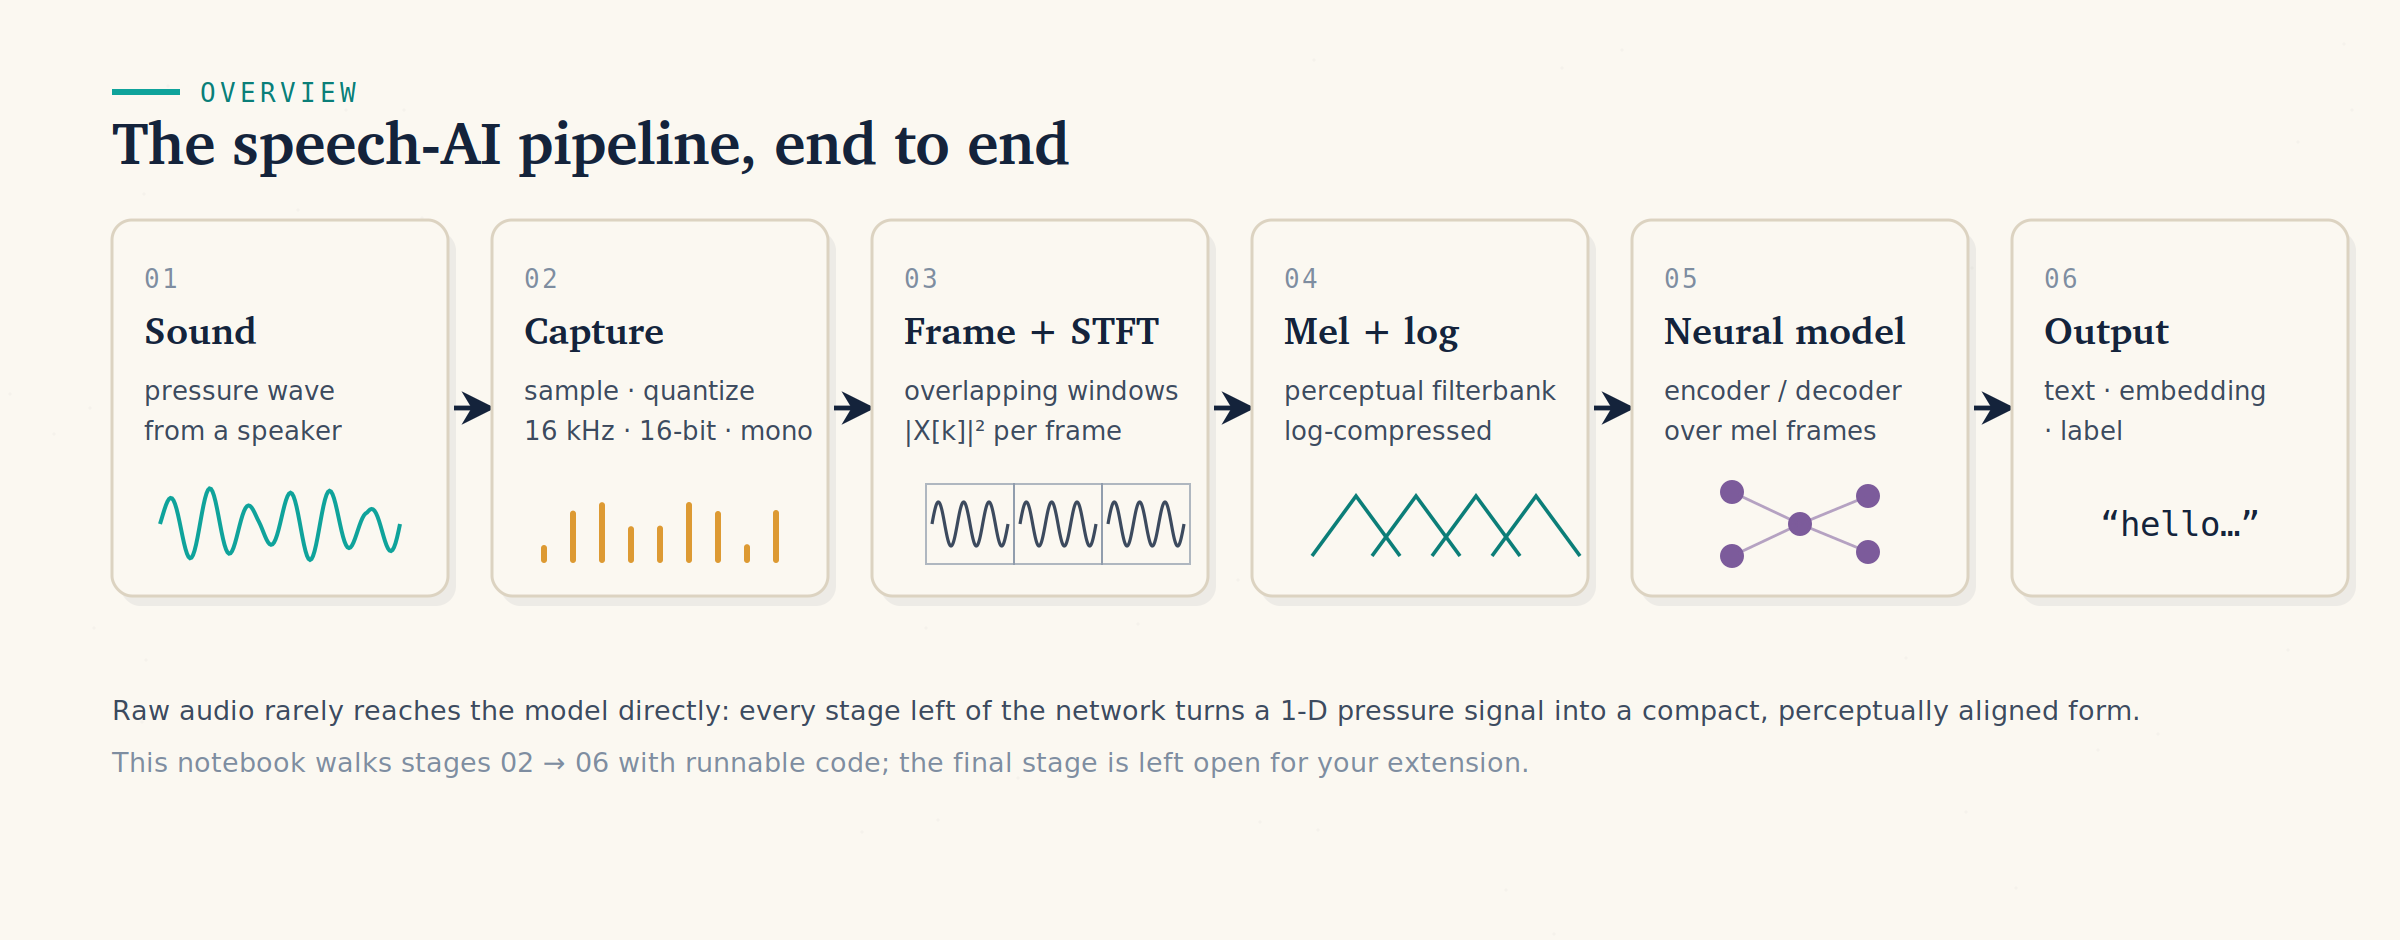

<sub><i>Everything left of the network turns a 1-D pressure signal into a compact, perceptually aligned representation.</i></sub>

> Anchor idea for the whole notebook: **a model never "hears" audio — it
> consumes a tensor.** Most speech bugs are bugs in how that tensor was made.

| Stage | What the model sees |
|---|---|
| Waveform | raw pressure samples |
| Spectrogram | time–frequency energy |
| Log-mel | perceptual speech features |
| Whisper tokens | decoded text |
| CLAP embedding | one semantic audio vector |


## 0 · Setup

The install targets the **running kernel** and tolerates "externally managed"
environments. If it still fails (locked-down host), run the notebook in
Colab, a venv/conda env, or the approved workspace kernel — the §1–§3 path
will run regardless; only the model sections need the packages.

Some environments also need system **ffmpeg** for compressed audio
(`librosa`/`soundfile` cover the PCM paths here). `torchcodec` is optional
(only very recent `transformers` audio loaders).

**Expected after setup:** `torch`, `transformers`, `datasets` → *available*,
`device` → `cuda`/`mps`/`cpu`. If any are *NOT available*, only the DSP
sections (§1–§3) will produce real output.

**Expected runtime:** core ≈ 3–5 min GPU / ≈ 8–15 min CPU (first-run model
downloads dominate). Optional CLAP adds ≈ 2–4 min + a model download.

In [ ]:
import sys
# Install into THIS kernel; --break-system-packages survives PEP-668 hosts.
!{sys.executable} -m pip install -q --break-system-packages \
    transformers datasets librosa soundfile jiwer accelerate scipy
# Optional, recent transformers audio decoders (safe to skip if it fails):
# !{sys.executable} -m pip install -q --break-system-packages torchcodec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 54.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import librosa                       # always available (core DSP path)
import matplotlib

print("numpy   ", np.__version__)
print("librosa ", librosa.__version__)

# torch / transformers / datasets are optional for the DSP path; report
# them but don't hard-fail if a no-network build lacks them.
TORCH_OK = HF_OK = DATASETS_OK = False
try:
    import torch
    TORCH_OK = True
    print("torch   ", torch.__version__)
except Exception as e:
    print("torch    NOT available ->", type(e).__name__)
try:
    import transformers
    HF_OK = True
    print("transformers", transformers.__version__)
except Exception as e:
    print("transformers NOT available ->", type(e).__name__)
try:
    import datasets
    DATASETS_OK = True
    print("datasets", datasets.__version__)
except Exception as e:
    print("datasets NOT available ->", type(e).__name__)

if TORCH_OK:
    device = ("cuda" if torch.cuda.is_available()
              else "mps" if torch.backends.mps.is_available() else "cpu")
else:
    device = "cpu"
# HF pipeline wants an int device, not a string, across versions:
pipe_device = 0 if device == "cuda" else -1
print("device        ", device, "| pipeline device:", pipe_device)
# NOTE: if MPS raises errors in the pipeline sections, set device = "cpu".

numpy    2.0.2
librosa  0.11.0
torch    2.10.0+cpu
transformers 5.0.0
datasets 4.0.0
device         cpu | pipeline device: -1


In [ ]:
# ---- Model configuration ------------------------------------------------
# Fast classroom default (English-only, ~74M params):
ASR_MODEL_ID = "openai/whisper-base.en"
# Assignment / production target (multilingual, much larger):
# ASR_MODEL_ID = "openai/whisper-large-v3-turbo"

# base.en CANNOT translate -> translation uses a small multilingual model.
TRANSLATE_MODEL_ID = "openai/whisper-small"
print("ASR model    ", ASR_MODEL_ID)
print("translate    ", TRANSLATE_MODEL_ID)

ASR model     openai/whisper-base.en
translate     openai/whisper-small


In [ ]:
# Shared example. Try a real LibriSpeech clip; if HF is unreachable, fall
# back to a DETERMINISTIC synthetic speech-like signal so every DSP/plot
# cell below still runs and looks realistic.
SR = 16_000

def synthetic_speech(seconds=14.0, sr=SR, seed=0):
    """Voiced (formant) + unvoiced (noise) + silence — speech-like enough
    for the energy/ZCR/mel demonstrations."""
    import itertools
    rng = np.random.default_rng(seed)
    n = int(seconds * sr)
    y = np.zeros(n, np.float32)
    t_all = np.arange(n) / sr
    pos = 0
    base = [("v", .28), ("v", .22), ("u", .12), ("sil", .10),
            ("v", .30), ("u", .10), ("v", .24), ("sil", .12),
            ("v", .26), ("u", .14), ("v", .20), ("sil", .10)]
    for kind, dur in itertools.cycle(base):
        if pos >= n:
            break
        m = int(dur * sr)
        if pos + m > n:
            m = n - pos
        if m <= 0:
            break
        tt = t_all[pos:pos + m]
        if kind == "v":
            f0 = rng.uniform(110, 160)
            sig = np.zeros(m)
            for h, (fmt, bw) in enumerate(
                    [(600, 80), (1700, 110), (2600, 140)], 1):
                for k in range(1, 18):
                    fk = k * f0
                    g = np.exp(-((fk - fmt) ** 2) / (2 * (bw * 4) ** 2))
                    sig += g / k * np.sin(2 * np.pi * fk * tt)
            env = np.hanning(m) ** 0.4
            y[pos:pos + m] = (0.5 * sig / (np.abs(sig).max() + 1e-9)
                              * env)
        elif kind == "u":
            nz = rng.standard_normal(m)
            from scipy.signal import butter, filtfilt
            b, a = butter(4, 0.45, "high")
            y[pos:pos + m] = (0.12 * filtfilt(b, a, nz)
                              * np.hanning(m)).astype(np.float32)
        pos += m
    y += 0.002 * rng.standard_normal(n).astype(np.float32)
    return y.astype(np.float32)

y = None
ref_text = "(synthetic offline sample — no reference transcript)"
USING_SYNTH = True
if DATASETS_OK:
    try:
        from datasets import load_dataset
        ds = load_dataset("hf-internal-testing/librispeech_asr_dummy",
                           "clean", split="validation")
        s = ds[0]
        y = np.asarray(s["audio"]["array"], np.float32)
        SR = s["audio"]["sampling_rate"]
        ref_text = s["text"]
        USING_SYNTH = False
    except Exception as e:
        print("LibriSpeech unavailable (", type(e).__name__,
              ") -> synthetic fallback.")
if y is None:
    y = synthetic_speech()

print("source     :", "SYNTHETIC fallback" if USING_SYNTH
      else "LibriSpeech dummy")
print(f"samples    : {len(y):,}")
print(f"sr         : {SR} Hz")
print(f"duration   : {len(y)/SR:.2f} s")
print(f"reference  : {ref_text!r}")

from IPython.display import Audio, display
print("\n▶ listen to the clip:")
display(Audio(y, rate=SR))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/520 [00:00<?, ?B/s]

clean/validation-00000-of-00001.parquet:   0%|          | 0.00/9.19M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/73 [00:00<?, ? examples/s]

source     : LibriSpeech dummy
samples    : 93,680
sr         : 16000 Hz
duration   : 5.86 s
reference  : 'MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL'

▶ listen to the clip:


In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white",
    "axes.facecolor": "#FCFAF4", "axes.edgecolor": "#C9CCD1",
    "axes.grid": True, "grid.color": "#E6E0D4", "grid.linewidth": 0.6,
    "axes.titlesize": 12, "axes.titleweight": "bold", "font.size": 10,
    "axes.labelcolor": "#14233B", "text.color": "#14233B",
    "xtick.color": "#3C4A5E", "ytick.color": "#3C4A5E",
})
INKC, CY, AM, PL, RD = "#14233B","#0FA39B","#DD9A33","#7C5B9B","#C3543F"
print("plot style ready")

plot style ready


## 1 · Digital foundations (≈ 8 min)

### 1.1 Sample rate and the Nyquist limit

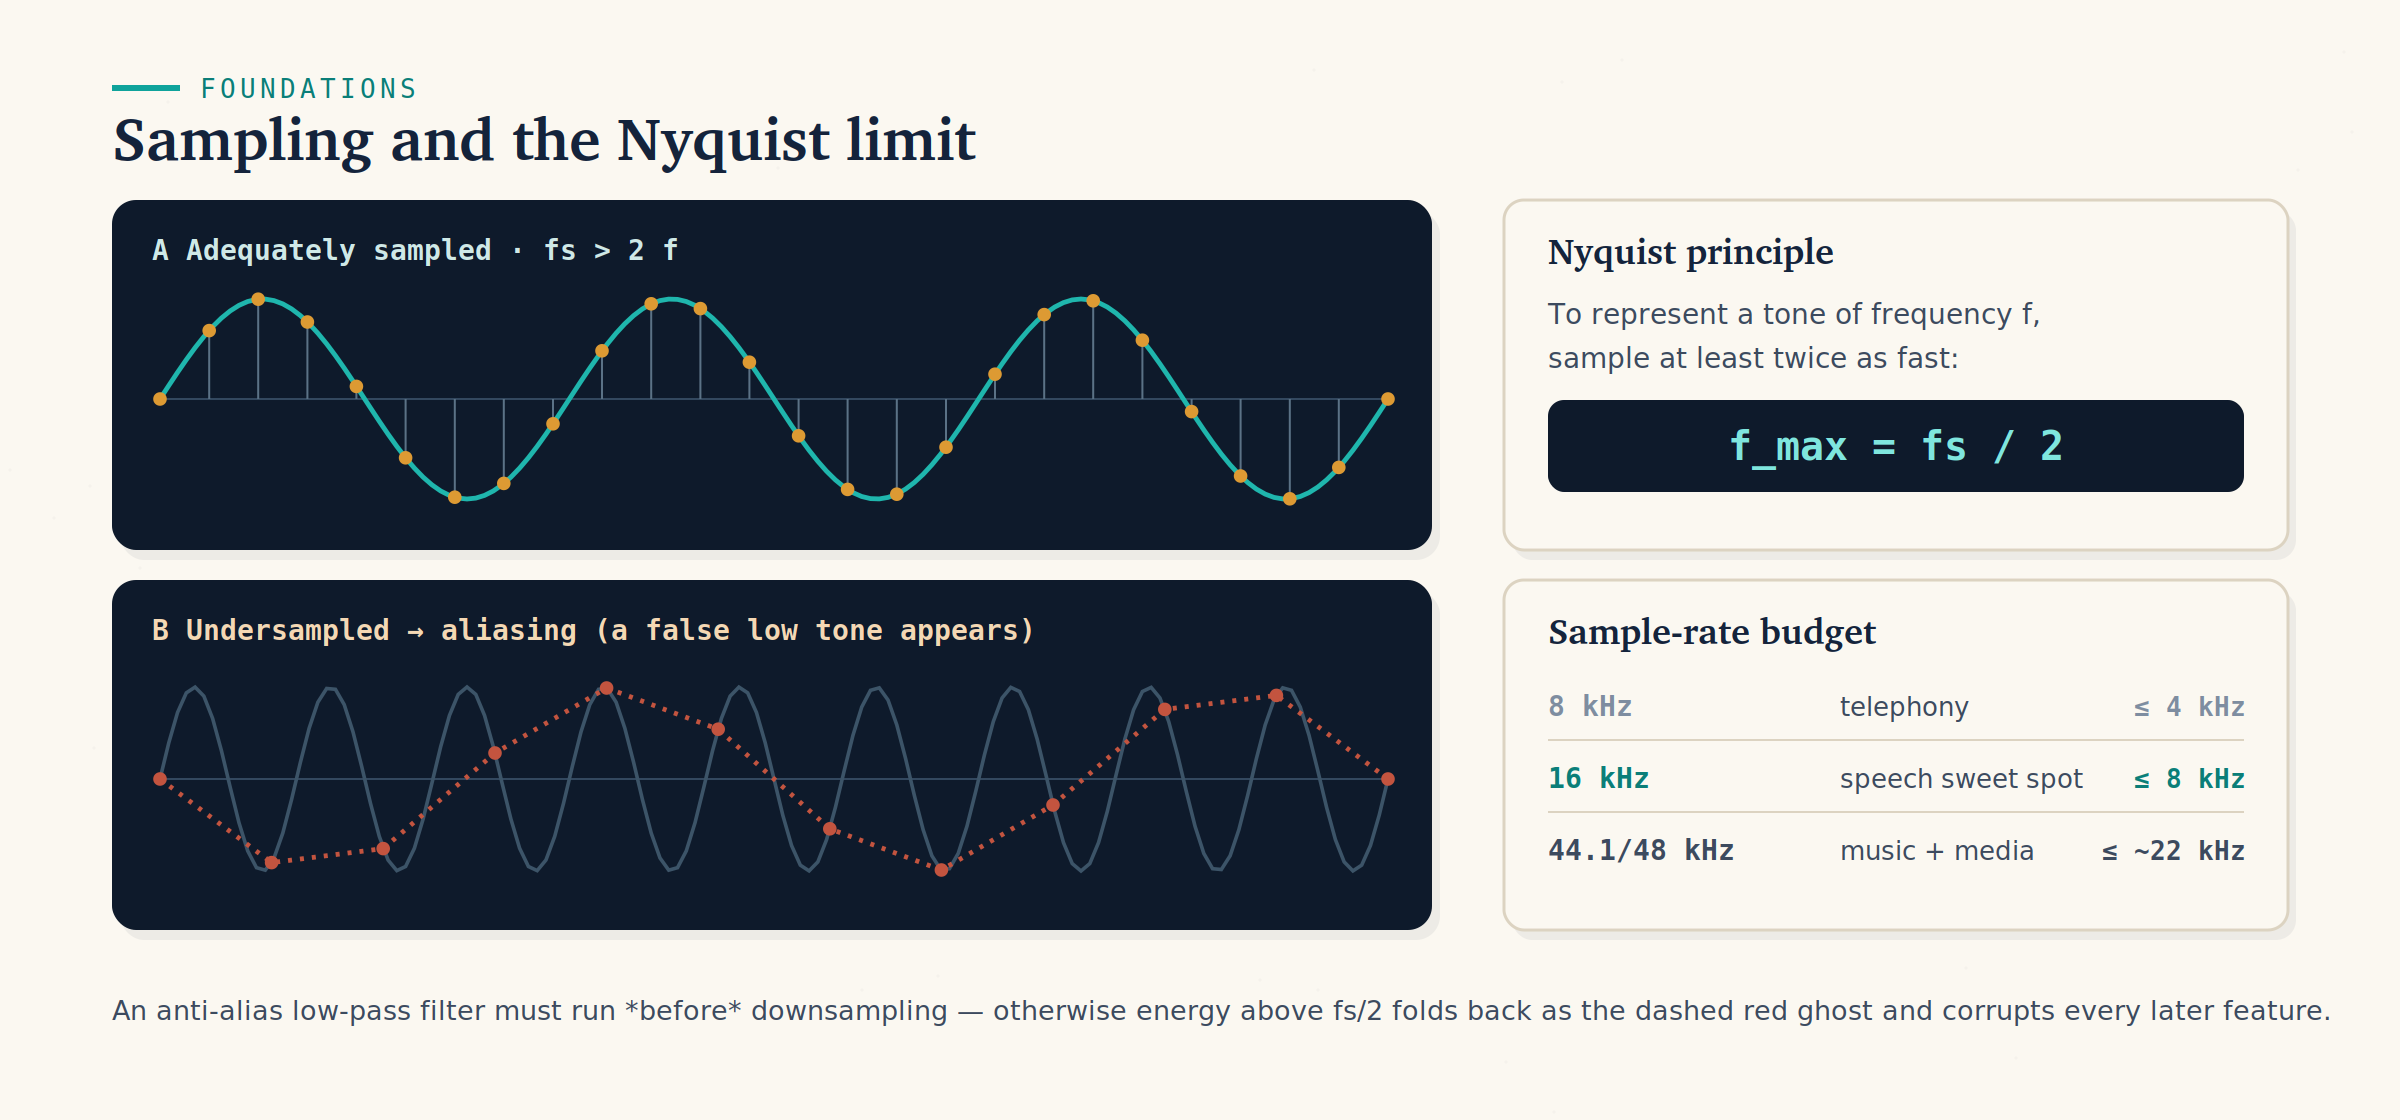

<sub><i>Adequate sampling reconstructs the tone; undersampling folds a high tone down to a permanent false low one (red).</i></sub>

A continuous wave becomes `fs` measurements/second. **Nyquist:** only
frequencies below `fs/2` survive. Speech intelligibility is mostly < 4 kHz
with consonant energy to ~8 kHz — hence **16 kHz** for speech. Content above
`fs/2` doesn't vanish; it **aliases**, so an anti-alias low-pass must run
*before* downsampling (`librosa.resample` does; naive `y[::k]` does not).

In [ ]:
# Resample to 16 kHz for the model path; also make an 8 kHz copy purely to
# VISUALISE the point-density drop (16 kHz vs a 16 kHz source is a no-op).
y16 = librosa.resample(y, orig_sr=SR, target_sr=16_000) if SR != 16_000 else y
y8  = librosa.resample(y, orig_sr=SR, target_sr=8_000)
y_naive = y[:: max(1, SR // 8_000)]

print(f"source           : {len(y):,} @ {SR} Hz  -> Nyquist {SR//2} Hz")
print(f"y16 (model path) : {len(y16):,} @ 16000 Hz")
print(f"y8  (anti-alias) : {len(y8):,} @  8000 Hz -> Nyquist 4000 Hz")
print(f"naive y[::k]     : {len(y_naive):,} samples (aliased: no filter)")
for rate, use in [(8_000,"telephony"),(16_000,"speech AI"),
                  (44_100,"music/media")]:
    print(f"  {rate:>6} Hz -> usable < {rate//2:>5} Hz   ({use})")

from IPython.display import Audio, display
print("\n▶ native (full band):");  display(Audio(y,  rate=SR))
print("▶ 8 kHz (telephony-band, anti-aliased — note the duller, "
      "muffled high end):"); display(Audio(y8, rate=8_000))

source           : 93,680 @ 16000 Hz  -> Nyquist 8000 Hz
y16 (model path) : 93,680 @ 16000 Hz
y8  (anti-alias) : 46,840 @  8000 Hz -> Nyquist 4000 Hz
naive y[::k]     : 46,840 samples (aliased: no filter)
    8000 Hz -> usable <  4000 Hz   (telephony)
   16000 Hz -> usable <  8000 Hz   (speech AI)
   44100 Hz -> usable < 22050 Hz   (music/media)

▶ native (full band):


▶ 8 kHz (telephony-band, anti-aliased — note the duller, muffled high end):


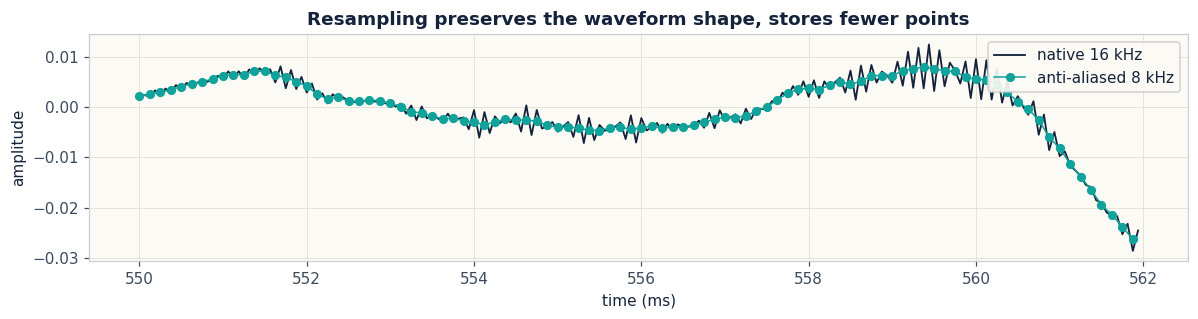

In [ ]:
# LIVE: a 12 ms window, native vs anti-aliased 8 kHz — visible density drop.
t0, dur = 0.55, 0.012
o = slice(int(t0*SR), int((t0+dur)*SR))
e = slice(int(t0*8000), int((t0+dur)*8000))
to = np.arange(o.start, o.stop)/SR*1e3
te = np.arange(e.start, e.stop)/8000*1e3

fig1, ax = plt.subplots(figsize=(11, 3))
ax.plot(to, y[o], color=INKC, lw=1.2, label=f"native {SR//1000} kHz")
ax.plot(te, y8[e], "o-", color=CY, ms=5, lw=1.0, label="anti-aliased 8 kHz")
ax.set(xlabel="time (ms)", ylabel="amplitude",
       title="Resampling preserves the waveform shape, stores fewer points")
ax.legend(loc="upper right", framealpha=.9); plt.tight_layout(); plt.show()

### 1.2 Bit depth and dynamic range

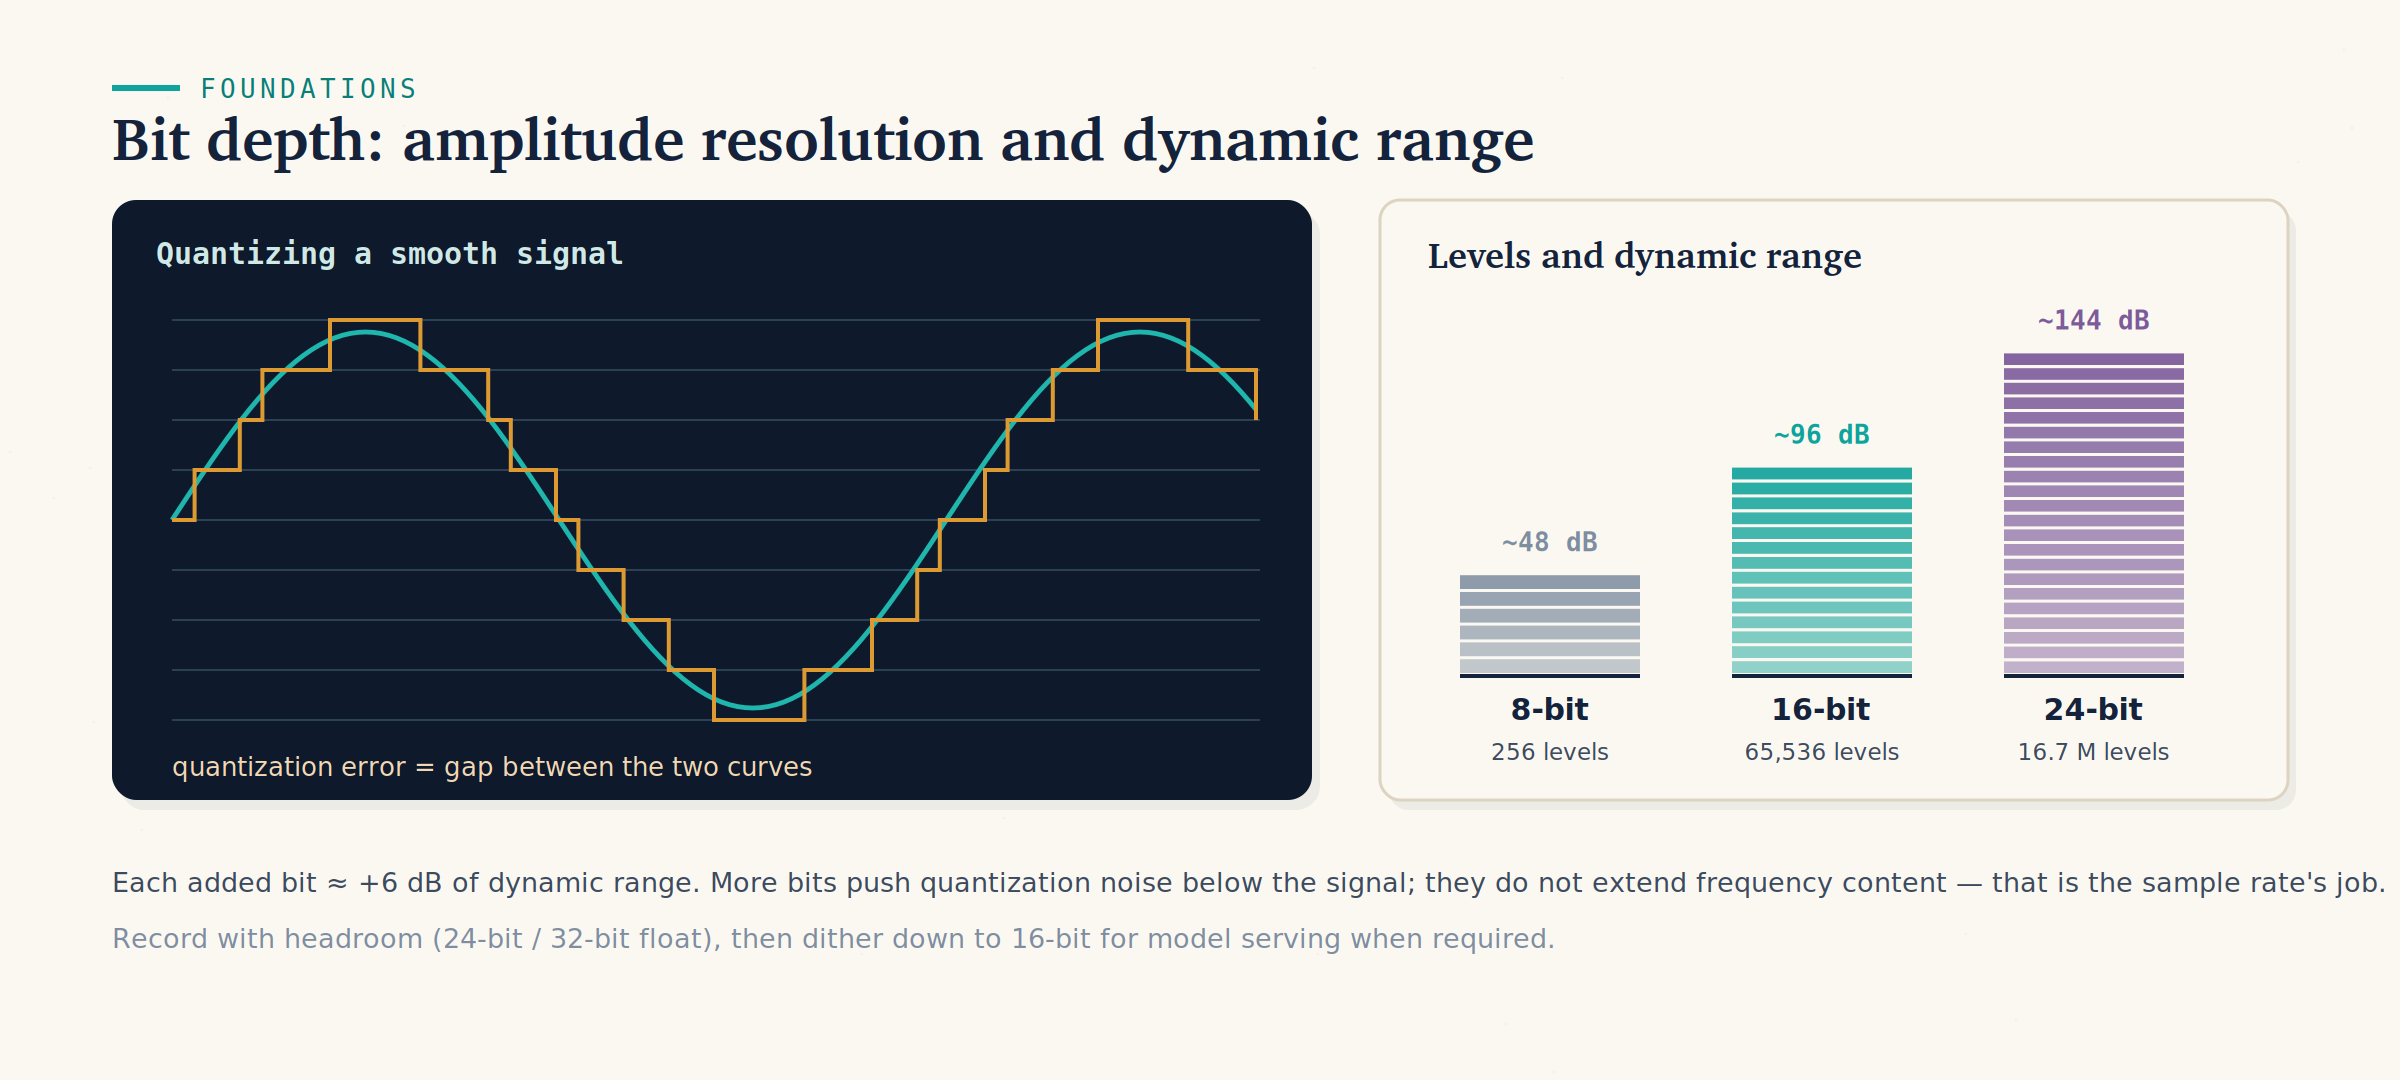

<sub><i>Bit depth sets amplitude resolution. ~6 dB dynamic range per bit; it does not add bandwidth.</i></sub>

Rounding each sample to a finite set of levels injects *quantization noise*;
SNR improves ~**6 dB per bit**.

In [ ]:
def quantize(x, bits):
    L = 2 ** bits
    return (np.round((x*0.5+0.5)*(L-1))/(L-1) - 0.5) * 2.0

x = y16 / (np.max(np.abs(y16)) + 1e-9)
print(f"{'bits':>4} | {'levels':>10} | {'SNR (dB)':>9}")
print("-"*30)
prev = None
for b in (4, 8, 12, 16):
    snr = 20*np.log10(np.linalg.norm(x) /
                      (np.linalg.norm(x - quantize(x, b)) + 1e-12))
    tag = "" if prev is None else f"  (+{snr-prev:4.1f} for +{b-pb} bits)"
    print(f"{b:>4} | {2**b:>10,} | {snr:>9.2f}{tag}")
    prev, pb = snr, b

bits |     levels |  SNR (dB)
------------------------------
   4 |         16 |     10.67
   8 |        256 |     36.64  (+26.0 for +4 bits)
  12 |      4,096 |     61.06  (+24.4 for +4 bits)
  16 |     65,536 |     85.18  (+24.1 for +4 bits)


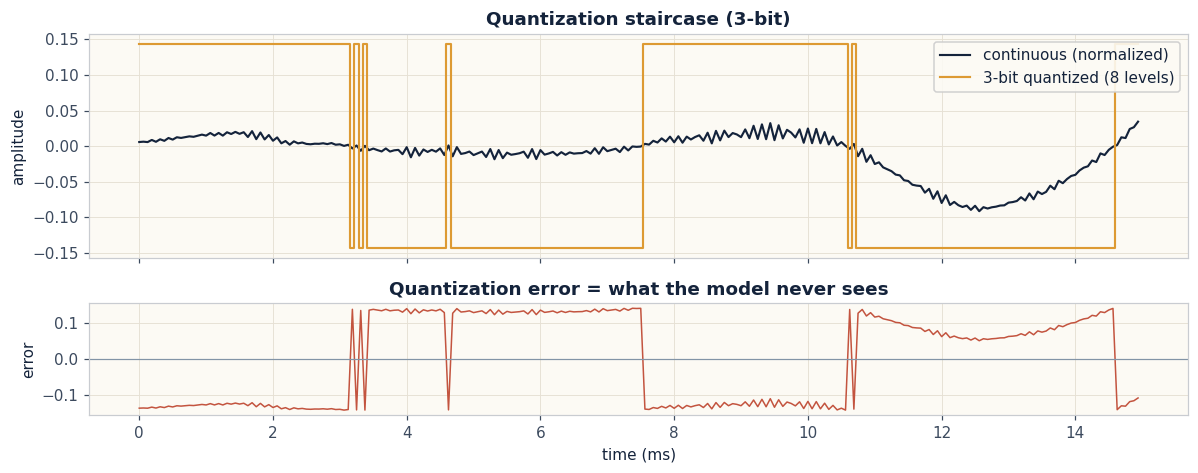

▶ original (normalized):


▶ 3-bit quantized — listen for the gritty, fuzzy quantization noise:


In [ ]:
# LIVE: 3-bit quantization on a short zoom + the error signal.
xq3 = quantize(x, 3)
g = slice(int(0.55*16000), int(0.565*16000))
ts = (np.arange(g.start, g.stop)/16000 - 0.55)*1e3
fig2, ax = plt.subplots(2, 1, figsize=(11, 4.4), sharex=True,
                        gridspec_kw={"height_ratios":[2,1]})
ax[0].plot(ts, x[g], color=INKC, lw=1.4, label="continuous (normalized)")
ax[0].step(ts, xq3[g], where="mid", color=AM, lw=1.4,
           label="3-bit quantized (8 levels)")
ax[0].set(ylabel="amplitude", title="Quantization staircase (3-bit)")
ax[0].legend(loc="upper right", framealpha=.9)
ax[1].plot(ts, (x-xq3)[g], color=RD, lw=1.0)
ax[1].axhline(0, color="#8294A6", lw=.8)
ax[1].set(xlabel="time (ms)", ylabel="error",
          title="Quantization error = what the model never sees")
plt.tight_layout(); plt.show()

from IPython.display import Audio, display
print("▶ original (normalized):");      display(Audio(x, rate=16_000))
print("▶ 3-bit quantized — listen for the gritty, fuzzy "
      "quantization noise:");               display(Audio(xq3, rate=16_000))

## 2 · Anatomy of a speech signal (≈ 8 min)

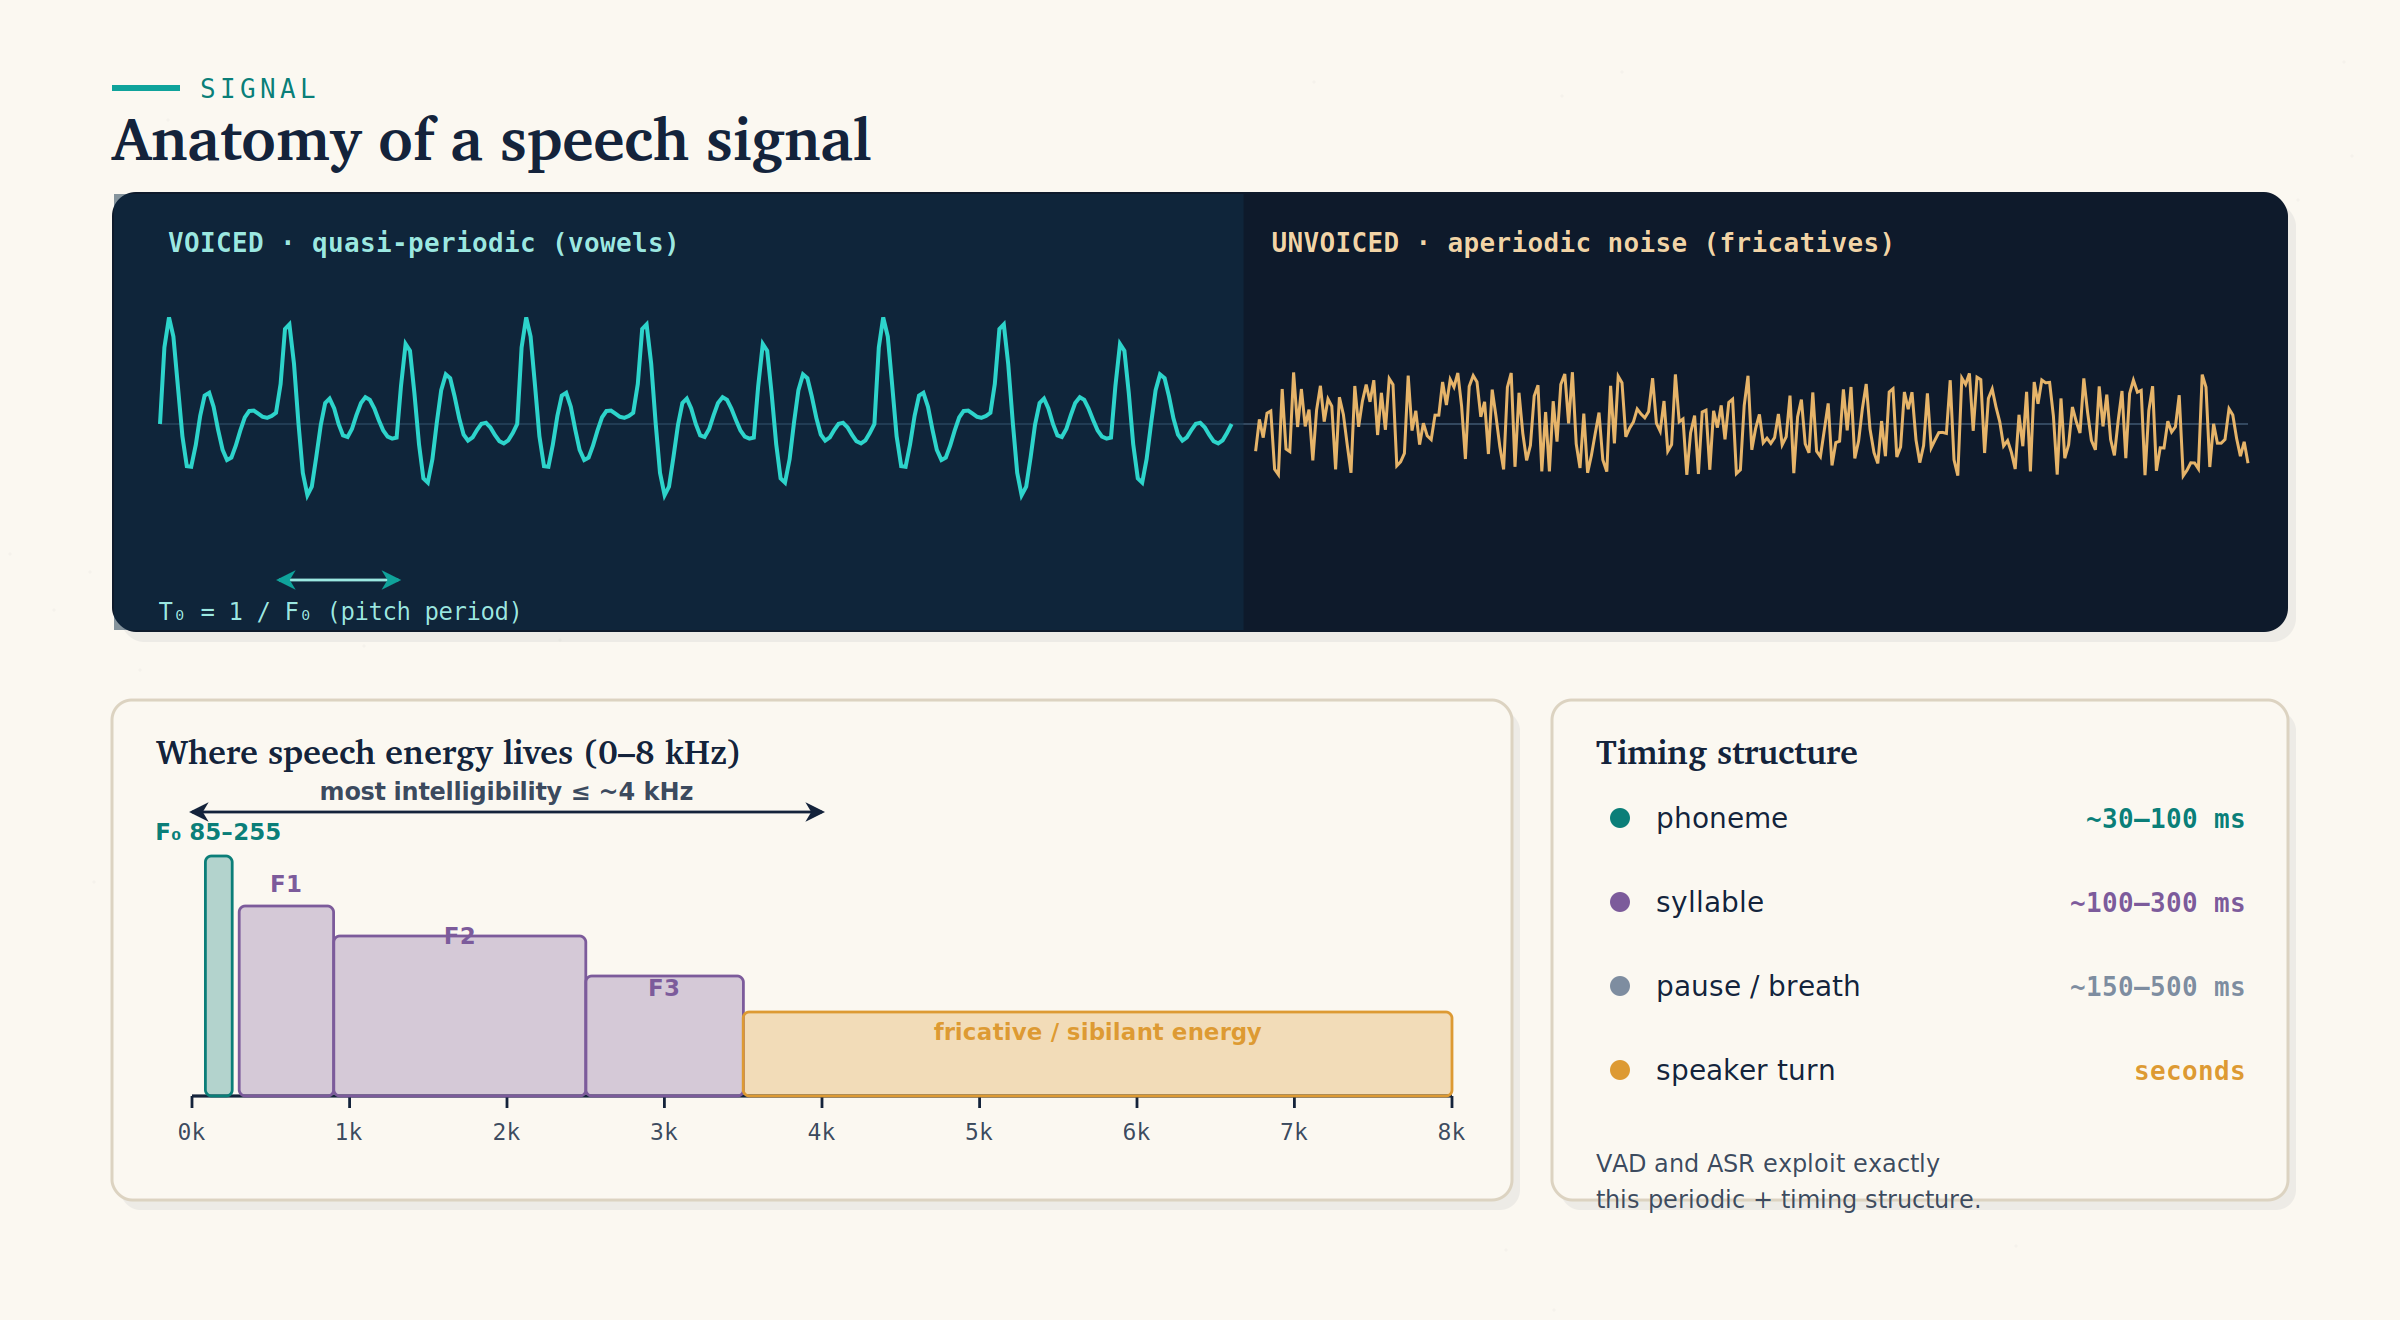

<sub><i>Voiced = quasi-periodic (T₀=1/F₀); unvoiced = noise. Energy: F₀ + formants. Timing: phonemes → syllables → turns.</i></sub>

Speech alternates **voiced** (quasi-periodic) and **unvoiced** (noise).
Two cheap features separate them: short-time **RMS** and **zero-crossing
rate**.

> ⚠️ **Caveat:** RMS + ZCR is a *toy heuristic for intuition only*.
> Production VAD / voiced-unvoiced uses pitch trackers, spectral features, or
> learned models (Silero VAD, pyannote). Do not ship this.

Mechanistically, the periodic/noise split comes from the **source–filter
model**: a source (periodic glottal pulses for voiced, turbulent noise for
unvoiced) is shaped by the vocal tract acting as a resonant filter. F₀ lives
in the source; vowel identity (the formants) lives in the filter.

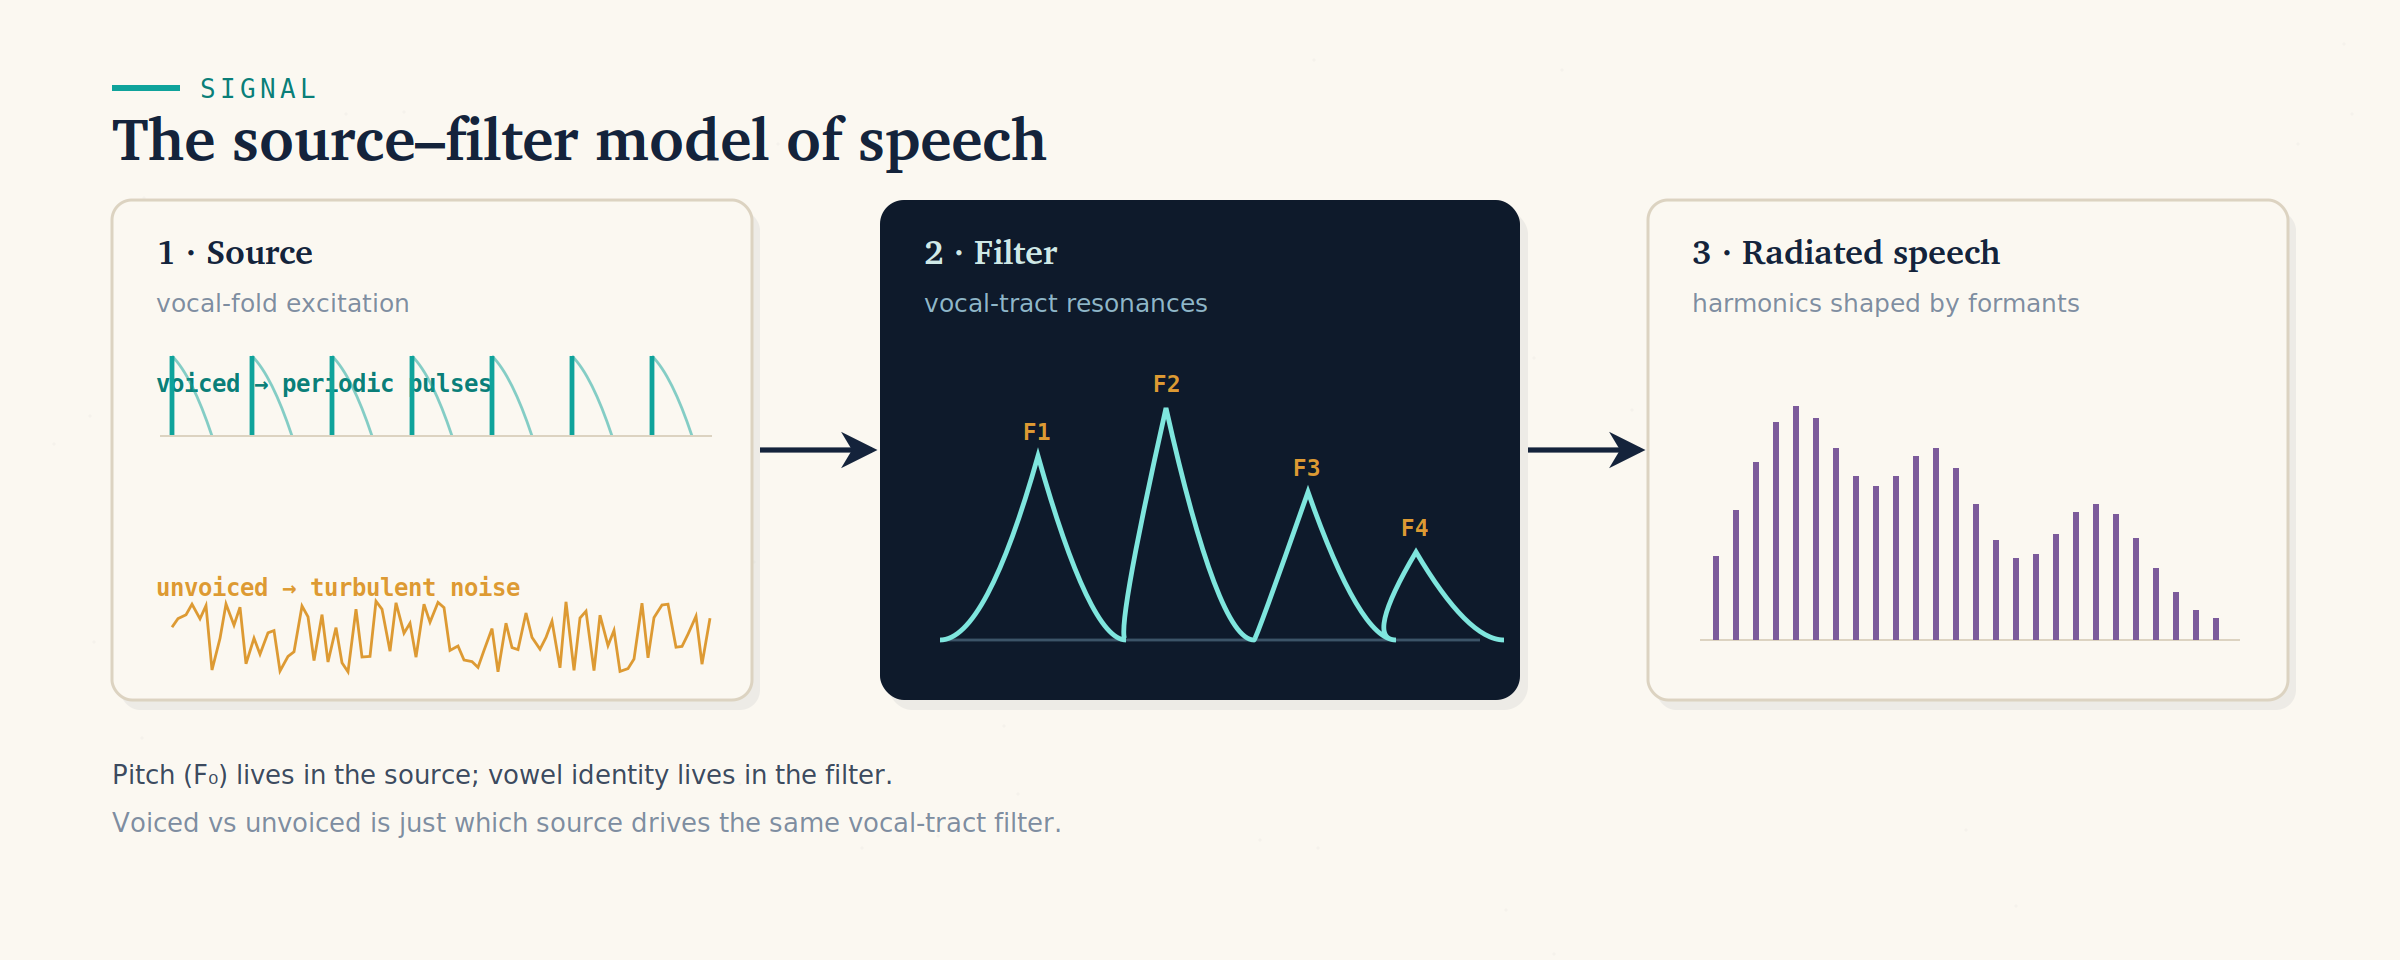

<sub><i>Voiced/unvoiced is which source drives the same vocal-tract filter; formants are the filter resonances.</i></sub>

In [ ]:
fl, hop = 1024, 256
fr = librosa.util.frame(y16, frame_length=fl, hop_length=hop)
rms = np.sqrt((fr**2).mean(0))
zcr = (np.abs(np.diff(np.sign(fr), axis=0)) > 0).mean(0)
speech   = rms > rms.max()*0.10
voiced   = speech & (zcr < np.median(zcr[speech]))
unvoiced = speech & ~voiced
def stat(m, nm):
    if m.sum()==0: print(f"{nm:<9}: (none)"); return
    print(f"{nm:<9}: {m.sum():4d} frames | RMS {rms[m].mean():.4f}"
          f" | ZCR {zcr[m].mean():.3f}")
print(f"total frames: {fr.shape[1]}")
stat(~speech,"silence"); stat(voiced,"voiced"); stat(unvoiced,"unvoiced")

from IPython.display import Audio, display
def montage(frame_mask, target_s=8.0):
    ch = [y16[i*hop:(i+1)*hop] for i in range(len(frame_mask))
          if frame_mask[i]]
    if not ch:
        return np.zeros(0, np.float32), 0.0
    seg = np.concatenate(ch).astype(np.float32)
    content = len(seg) / 16_000
    need = int(target_s * 16_000)
    if 0 < len(seg) < need:                     # loop until ~target_s
        seg = np.tile(seg, int(np.ceil(need / len(seg))))[:need]
    return seg, content
for m, name in [(voiced,  "voiced frames only (periodic — "
                          "vowel-like buzz)"),
                (unvoiced,"unvoiced frames only (aperiodic — "
                          "hiss/noise)")]:
    seg, content = montage(m)
    if seg.size:
        print(f"▶ {name}  — {seg.size/16000:.1f}s playback "
              f"({content:.1f}s of distinct {name.split()[0]} audio, "
              f"{int(m.sum())} frames, looped to fill)")
        display(Audio(seg, rate=16_000))
    else:
        print(f"({name}: none detected in this clip)")

total frames: 362
silence  :   84 frames | RMS 0.0035 | ZCR 0.182
voiced   :  139 frames | RMS 0.0715 | ZCR 0.044
unvoiced :  139 frames | RMS 0.0579 | ZCR 0.306
▶ voiced frames only (periodic — vowel-like buzz)  — 8.0s playback (2.2s of distinct voiced audio, 139 frames, looped to fill)


▶ unvoiced frames only (aperiodic — hiss/noise)  — 8.0s playback (2.2s of distinct unvoiced audio, 139 frames, looped to fill)


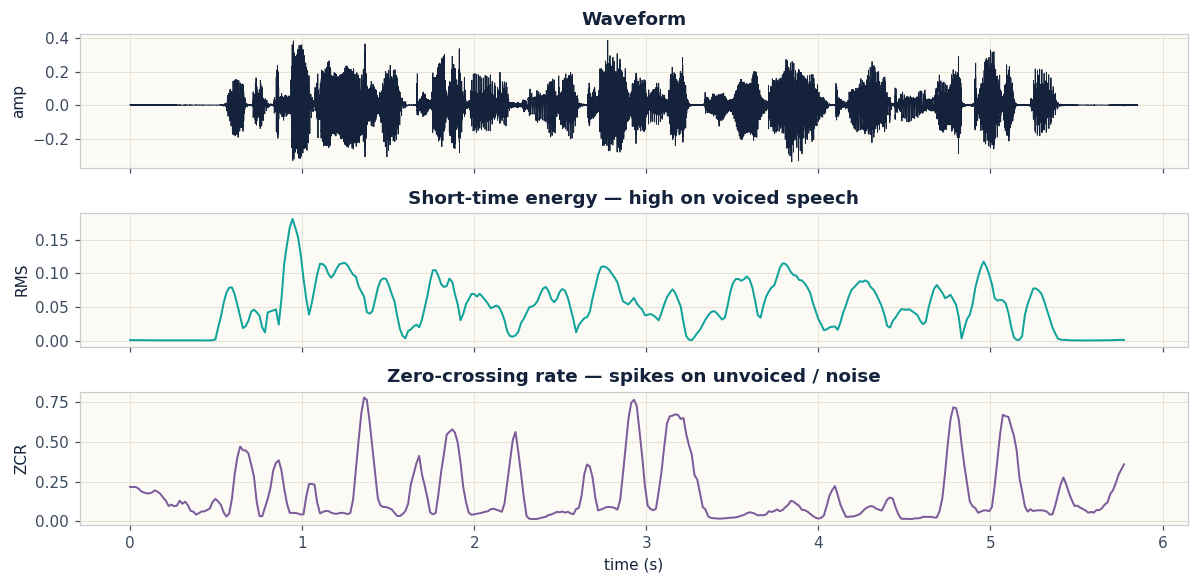

In [ ]:
# LIVE: waveform / RMS / ZCR on a shared time axis.
ft = librosa.frames_to_time(np.arange(len(rms)), sr=16000, hop_length=hop)
wt = np.arange(len(y16))/16000
fig3, ax = plt.subplots(3, 1, figsize=(11, 5.4), sharex=True)
ax[0].plot(wt, y16, color=INKC, lw=.6); ax[0].set(ylabel="amp",
          title="Waveform")
ax[1].plot(ft, rms, color=CY, lw=1.3); ax[1].set(ylabel="RMS",
          title="Short-time energy — high on voiced speech")
ax[2].plot(ft, zcr, color=PL, lw=1.3)
ax[2].set(xlabel="time (s)", ylabel="ZCR",
          title="Zero-crossing rate — spikes on unvoiced / noise")
plt.tight_layout(); plt.show()

## 3 · Mel spectrograms — the workhorse representation (≈ 12 min)

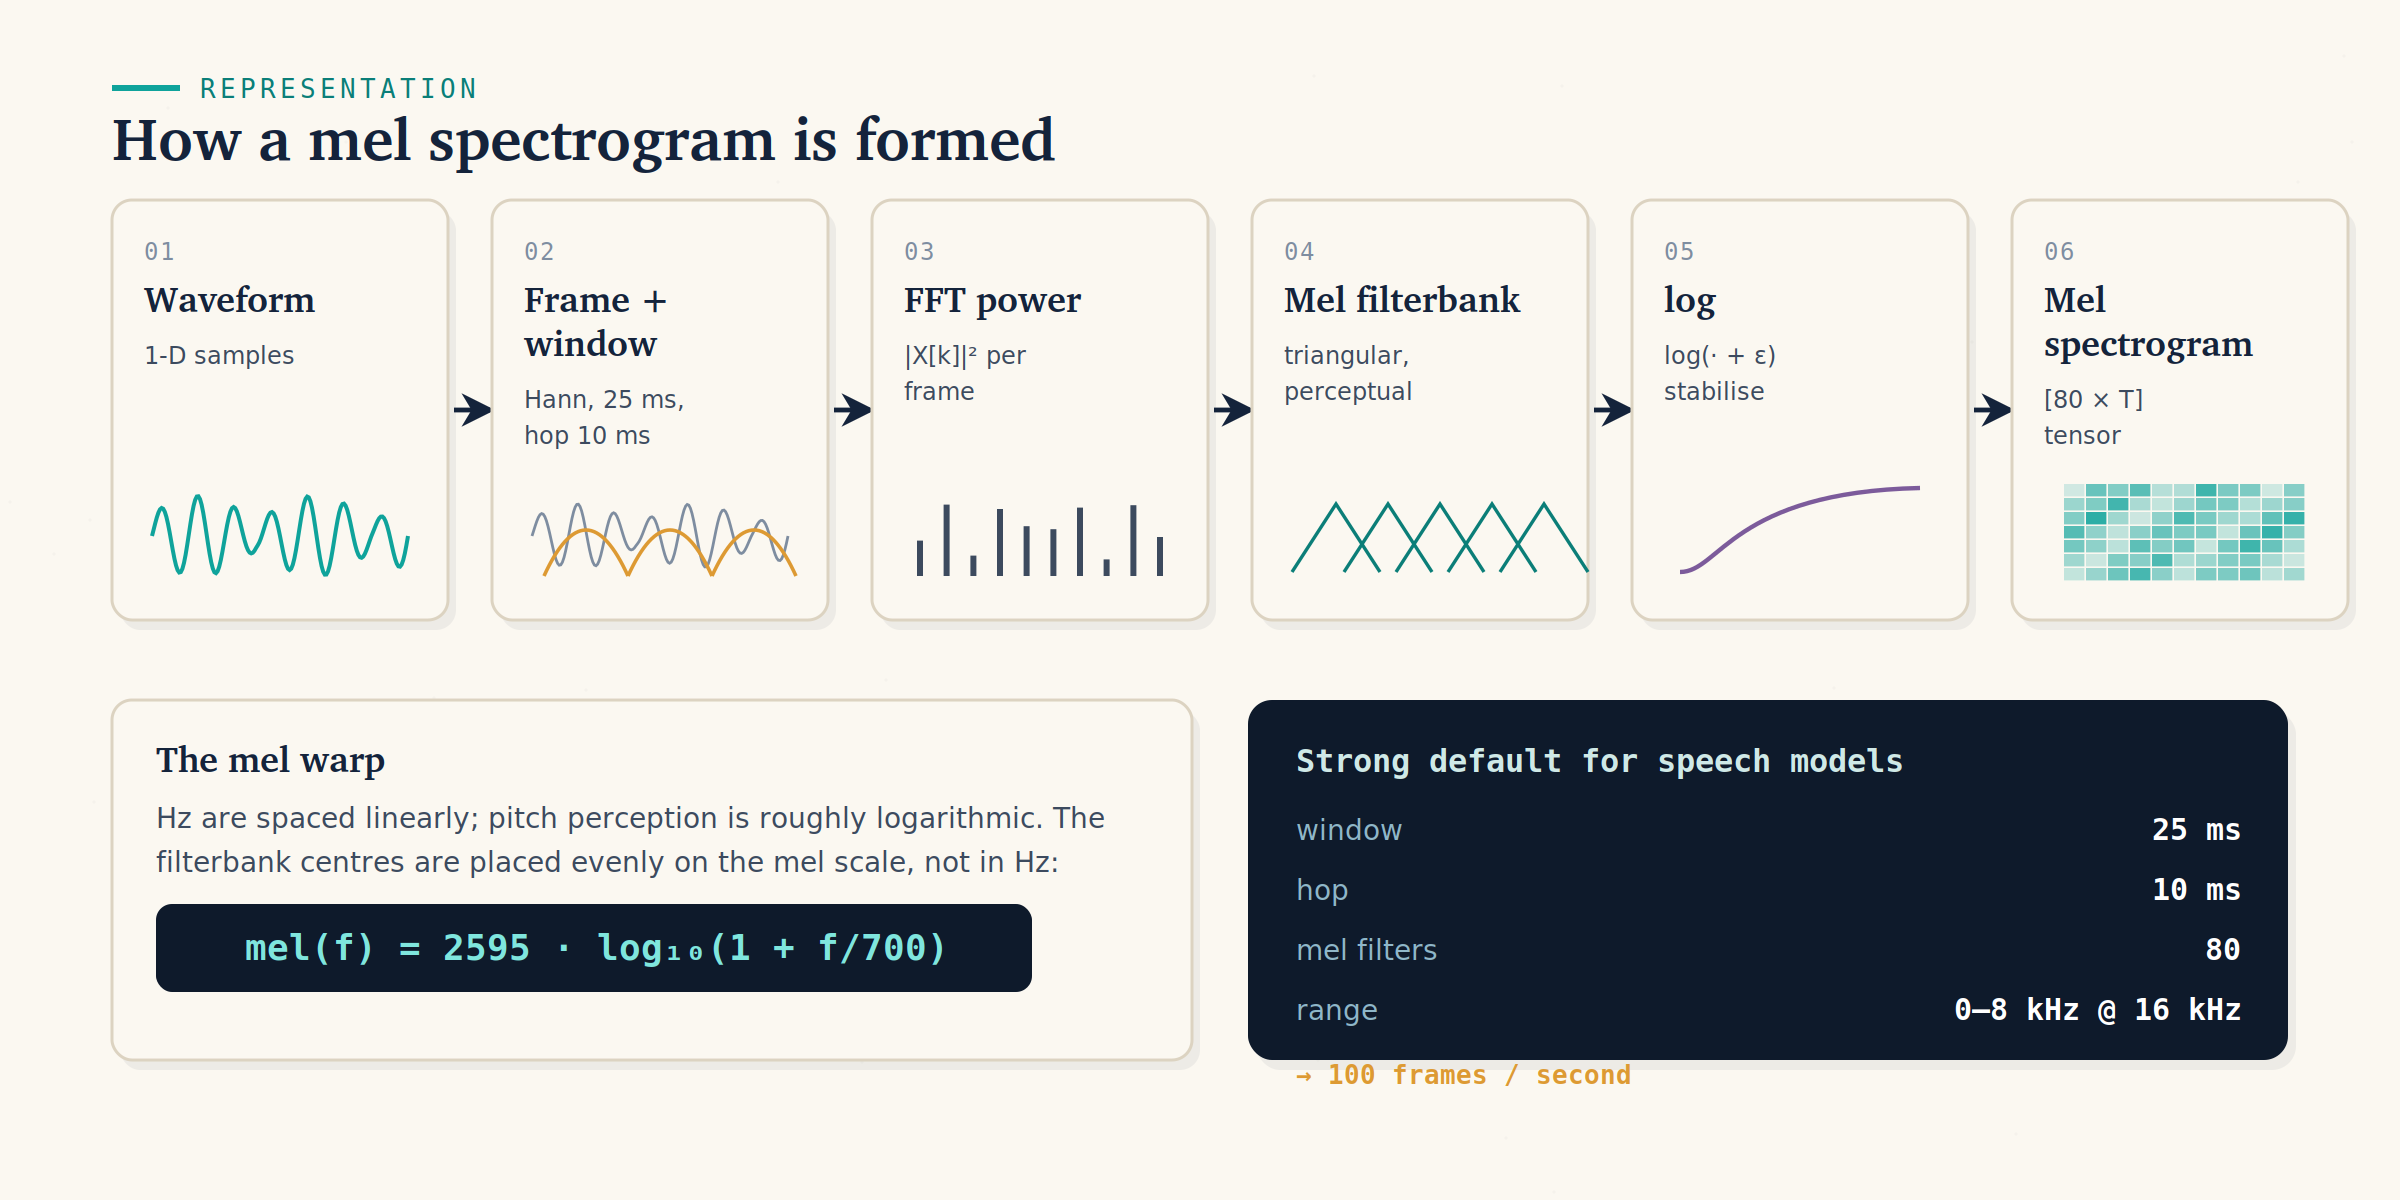

<sub><i>Waveform → windowed frames → FFT power → triangular mel filterbank → log. Filters even on the mel scale, not in Hz.</i></sub>

Frame + Hann window (~25 ms) → `|X[k]|²` → ~80 triangular **mel** bands
(`mel(f)=2595·log₁₀(1+f/700)`) → `log`. Canonical config — **25 ms / 10 ms /
80 bands / 0–8 kHz @ 16 kHz** → exactly **100 frames/second**, which is what
Whisper's feature extractor produces.

**Step 1 — the STFT.** "Frame + FFT" means: slide a windowed frame
along the signal, FFT each frame to a magnitude column, and stack the
columns. Window length sets frequency detail; hop sets the column rate.

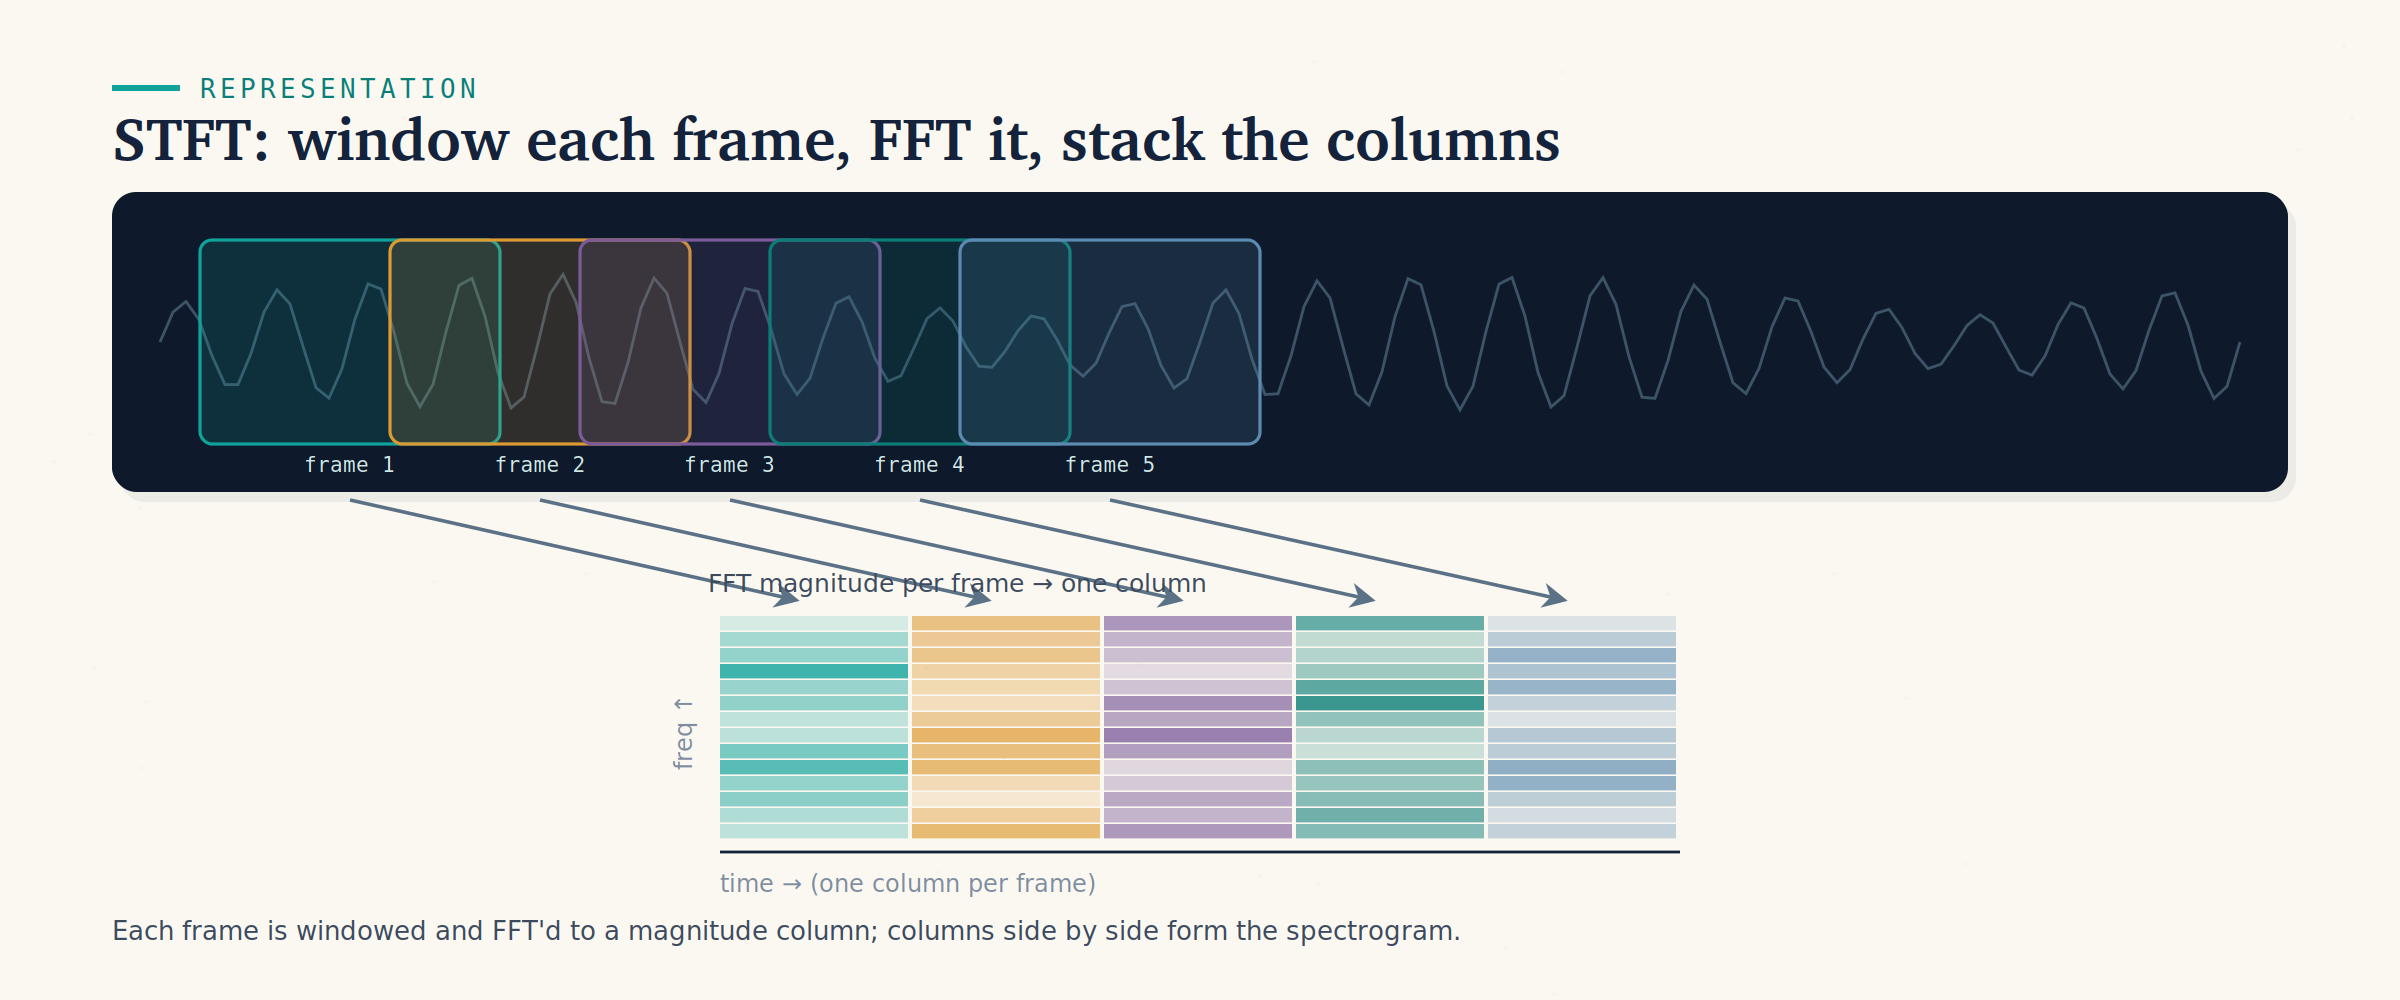

<sub><i>Each overlapping frame becomes one spectral column; columns side by side form the spectrogram.</i></sub>

**Step 2 — the mel filterbank.** The linear FFT bins are collapsed into ~80
triangular bands whose centres are evenly spaced on the *mel* scale, so the
filters widen with frequency — a fixed, sparse matrix multiply.

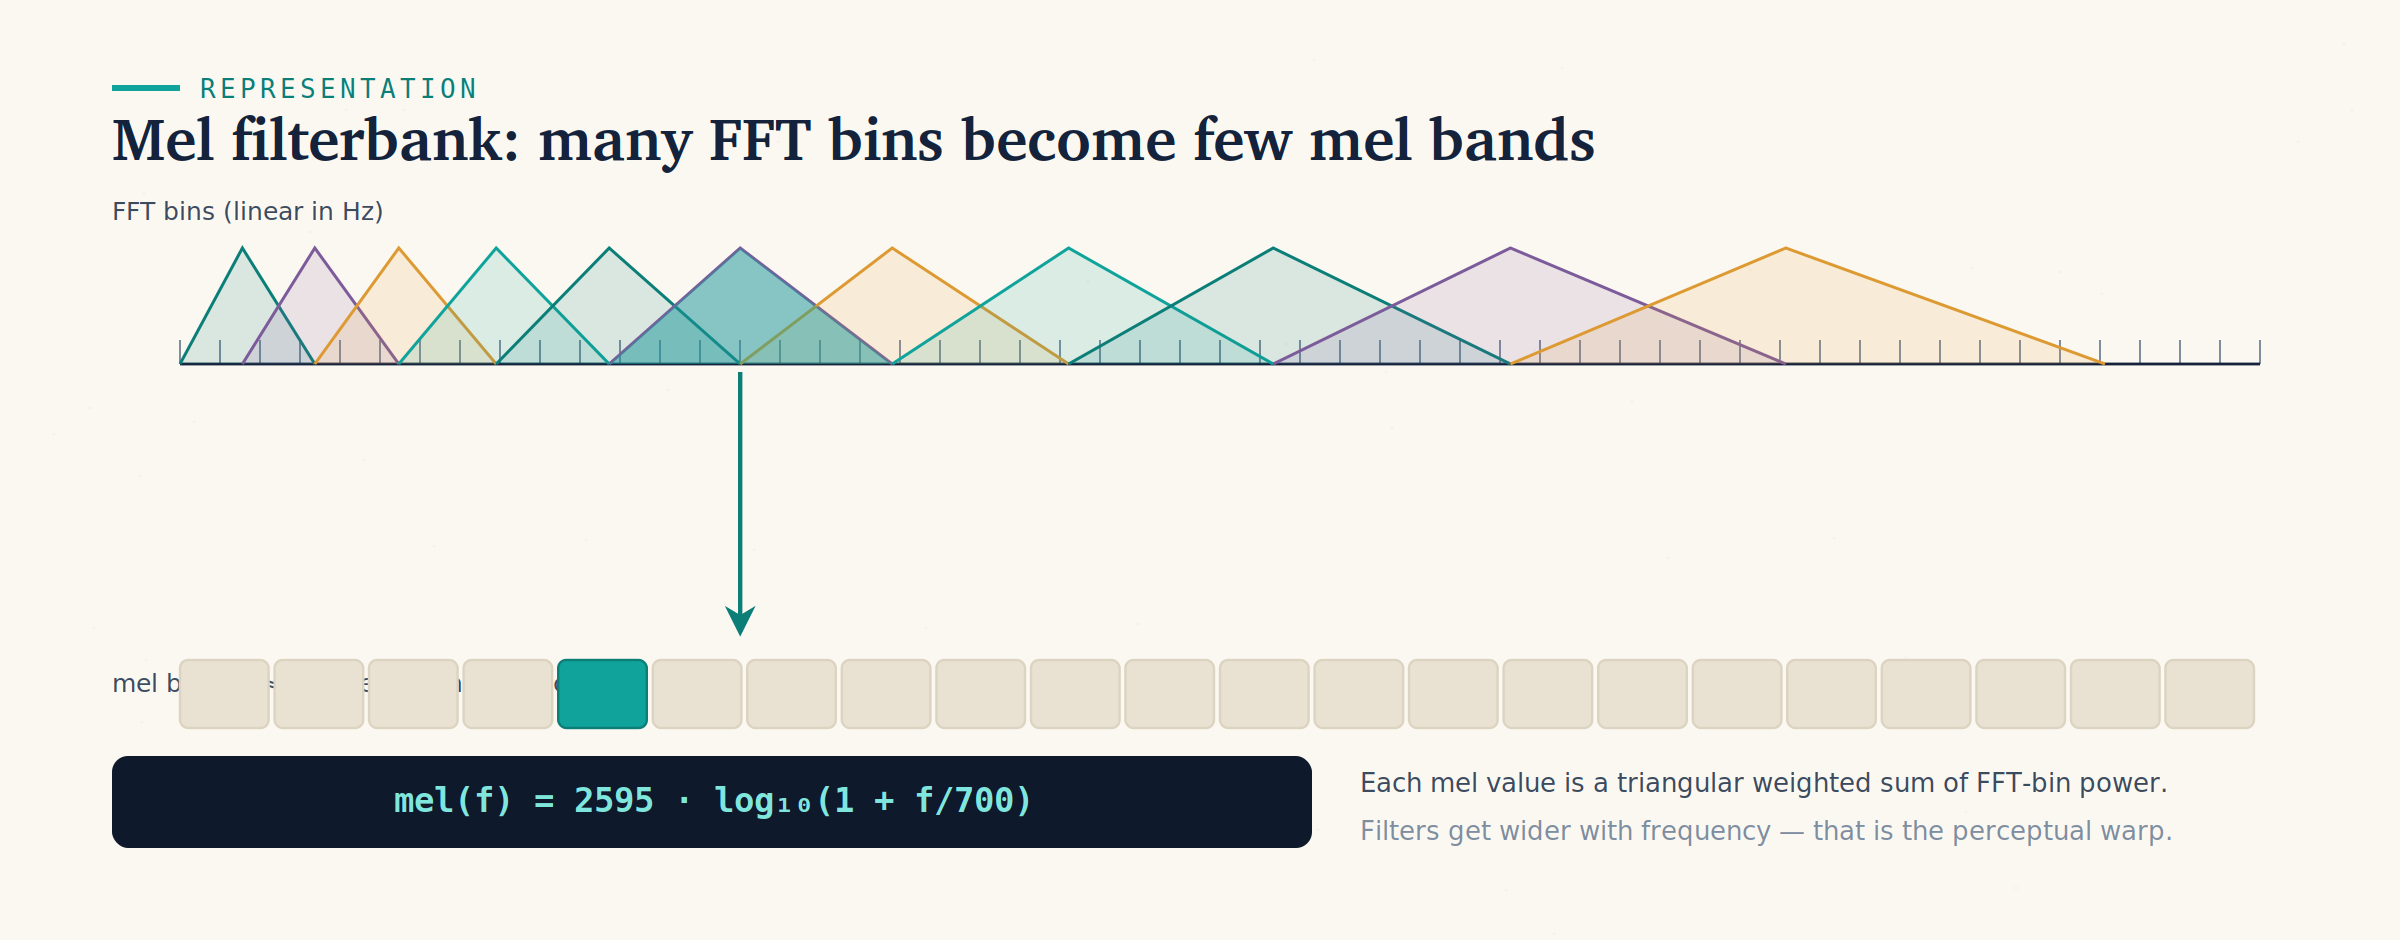

<sub><i>Each mel value is a triangular weighted sum of FFT-bin power; filters widen with frequency — the perceptual warp.</i></sub>

In [ ]:
sr_m = 16_000
n_fft, hop_length, n_mels = int(.025*sr_m), int(.010*sr_m), 80
mel = librosa.feature.melspectrogram(
    y=y16, sr=sr_m, n_fft=n_fft, hop_length=hop_length,
    n_mels=n_mels, fmin=0, fmax=8000, window="hann")
mel_db = librosa.power_to_db(mel, ref=np.max)
fb = librosa.filters.mel(sr=sr_m, n_fft=n_fft, n_mels=n_mels, fmax=8000)
print(f"mel shape       : {mel.shape}  (n_mels, T)")
print(f"frames / second : {sr_m/hop_length:.0f}")
print(f"clip ~ frames   : {len(y16)//hop_length}")
print(f"filterbank      : {fb.shape}, {(fb>0).mean()*100:.1f}% non-zero")

mel shape       : (80, 586)  (n_mels, T)
frames / second : 100
clip ~ frames   : 585
filterbank      : (80, 201), 2.4% non-zero


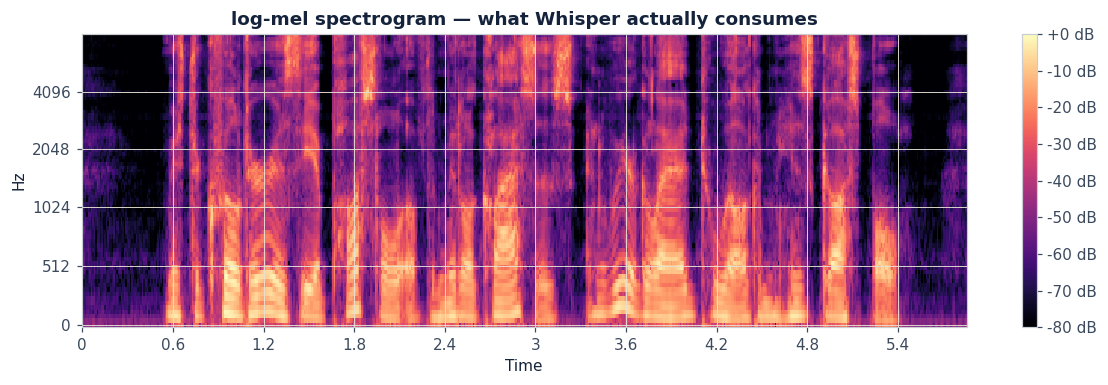

In [ ]:
# LIVE (core): the actual log-mel of our clip.
import librosa.display
fig4, ax = plt.subplots(figsize=(11, 3.6))
im = librosa.display.specshow(mel_db, sr=sr_m, hop_length=hop_length,
        x_axis="time", y_axis="mel", fmax=8000, ax=ax, cmap="magma")
fig4.colorbar(im, ax=ax, format="%+2.0f dB")
ax.set(title="log-mel spectrogram — what Whisper actually consumes")
plt.tight_layout(); plt.show()

### 3.1 Window vs hop: the trade-off you cannot escape

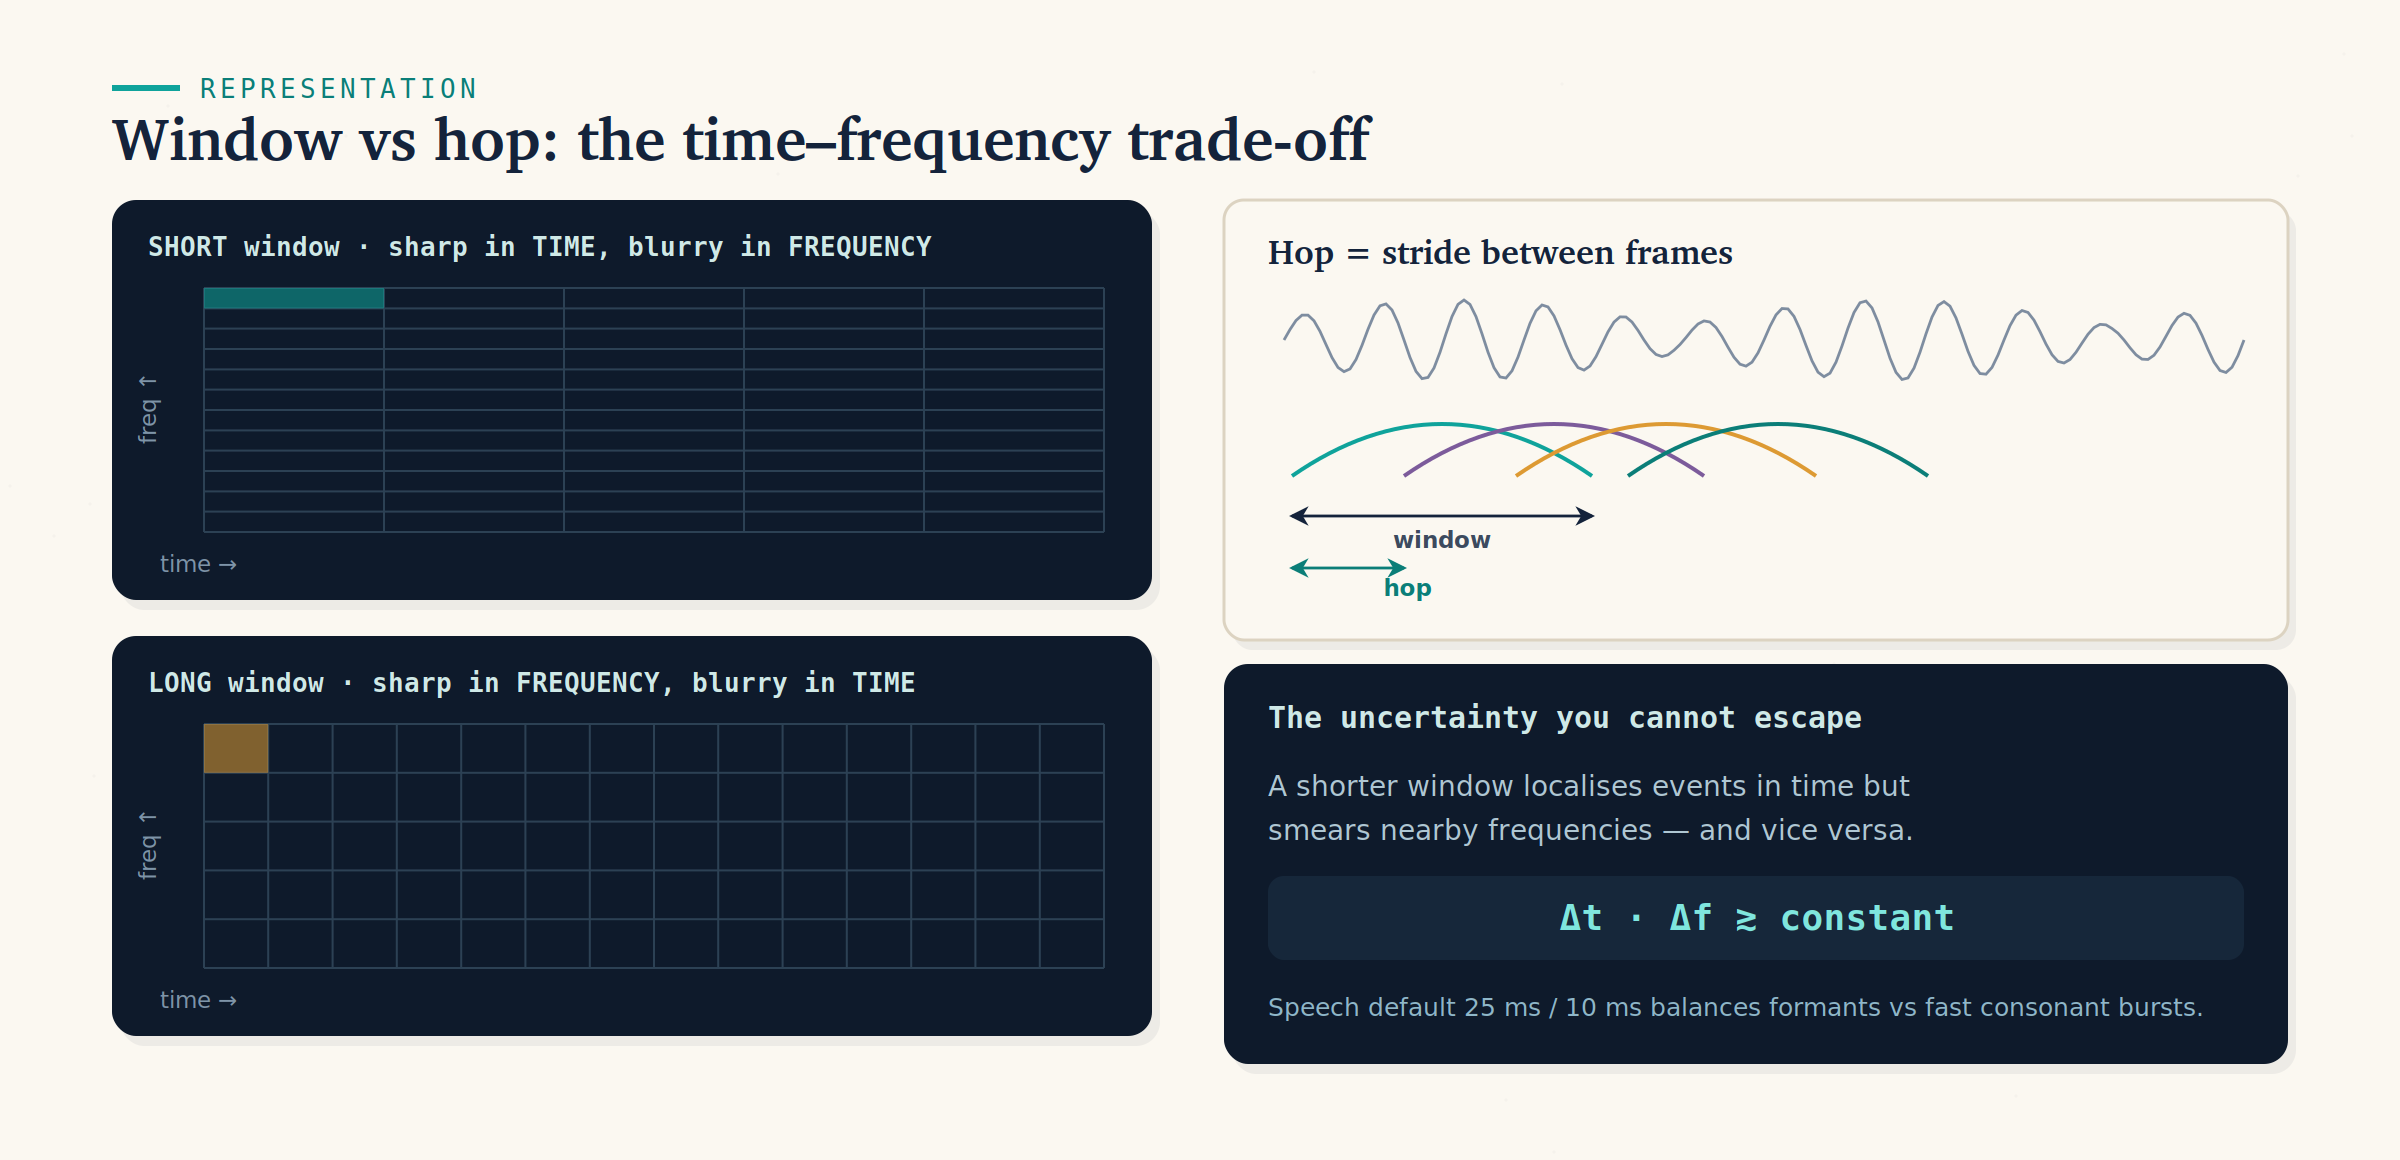

<sub><i>Short window: sharp in time, blurry in frequency. Long window: the reverse. Δt·Δf is bounded below; 25/10 ms is the speech compromise.</i></sub>

The window also has a *shape*, not just a length. A hard rectangular cut
leaks energy across bins; a Hann taper concentrates each tone into a sharp
peak — which is why every STFT frame is Hann-windowed first.

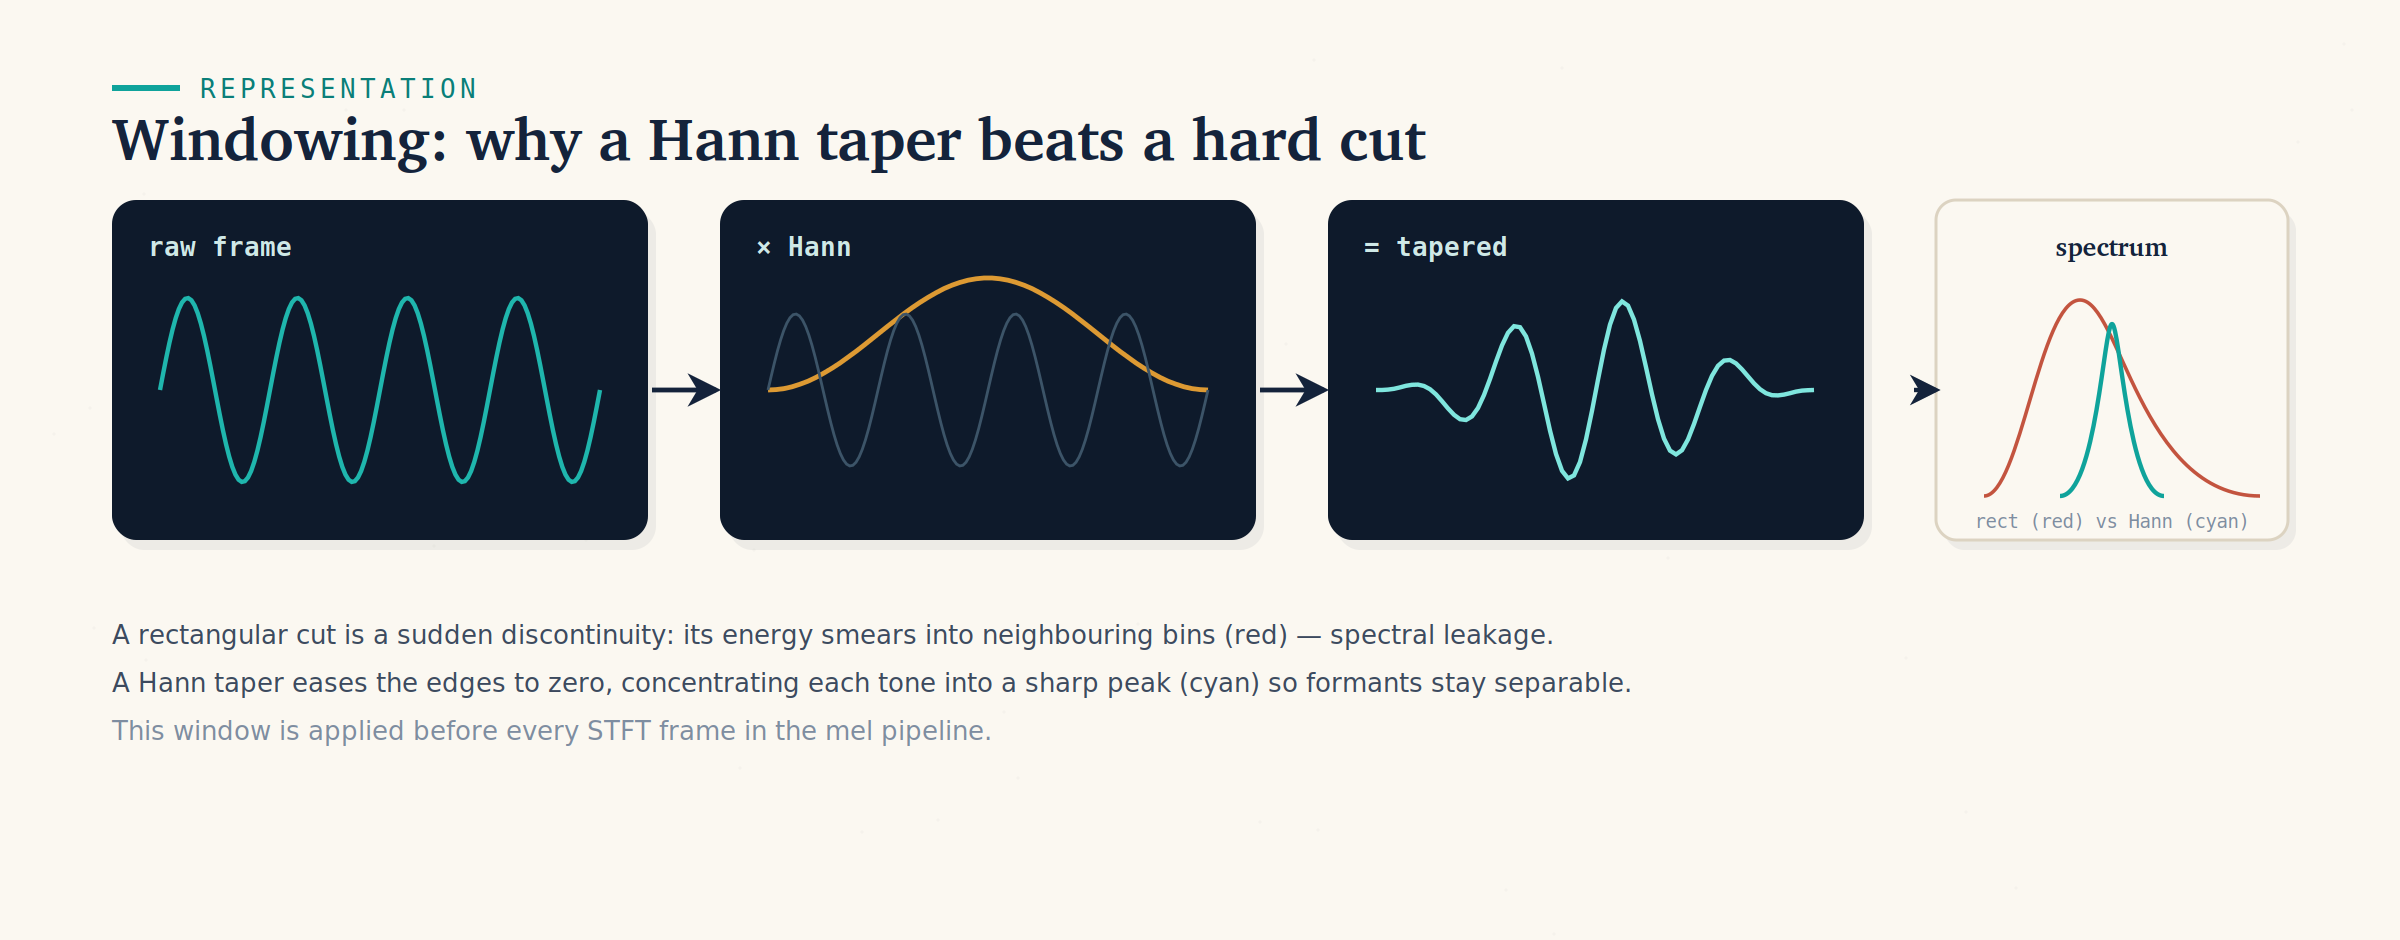

<sub><i>Rectangular cut → spectral leakage (broad skirts); Hann taper → a concentrated peak so formants stay separable.</i></sub>

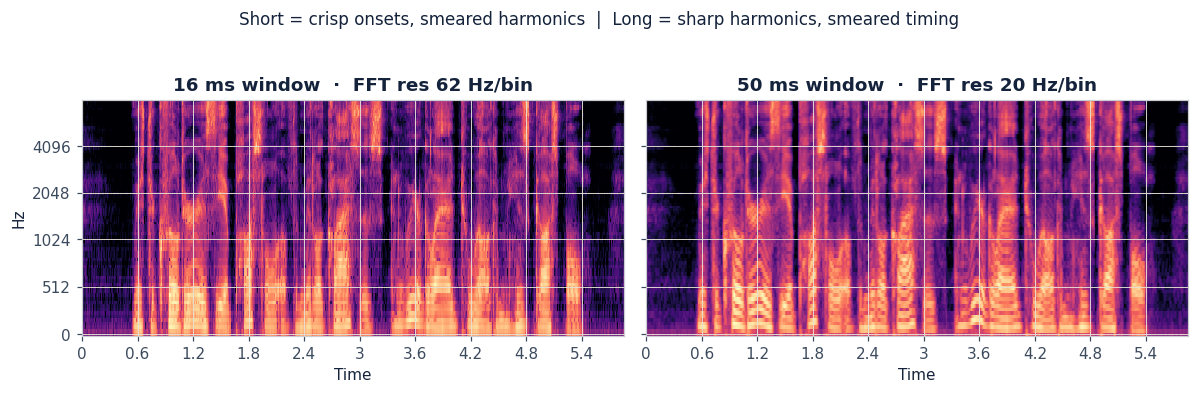

In [ ]:
fig5, ax = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for a, win_ms in zip(ax, (16, 50)):
    nf = int(win_ms/1000*sr_m)
    m = librosa.power_to_db(librosa.feature.melspectrogram(
        y=y16, sr=sr_m, n_fft=nf, hop_length=hop_length,
        n_mels=n_mels, fmax=8000), ref=np.max)
    librosa.display.specshow(m, sr=sr_m, hop_length=hop_length,
        x_axis="time", y_axis="mel", fmax=8000, ax=a, cmap="magma")
    a.set(title=f"{win_ms} ms window  ·  FFT res {sr_m/nf:.0f} Hz/bin")
ax[1].set_ylabel("")
fig5.suptitle("Short = crisp onsets, smeared harmonics  |  "
              "Long = sharp harmonics, smeared timing", y=1.04, fontsize=11)
plt.tight_layout(); plt.show()

## 4 · Speech recognition with Whisper (≈ 14 min)

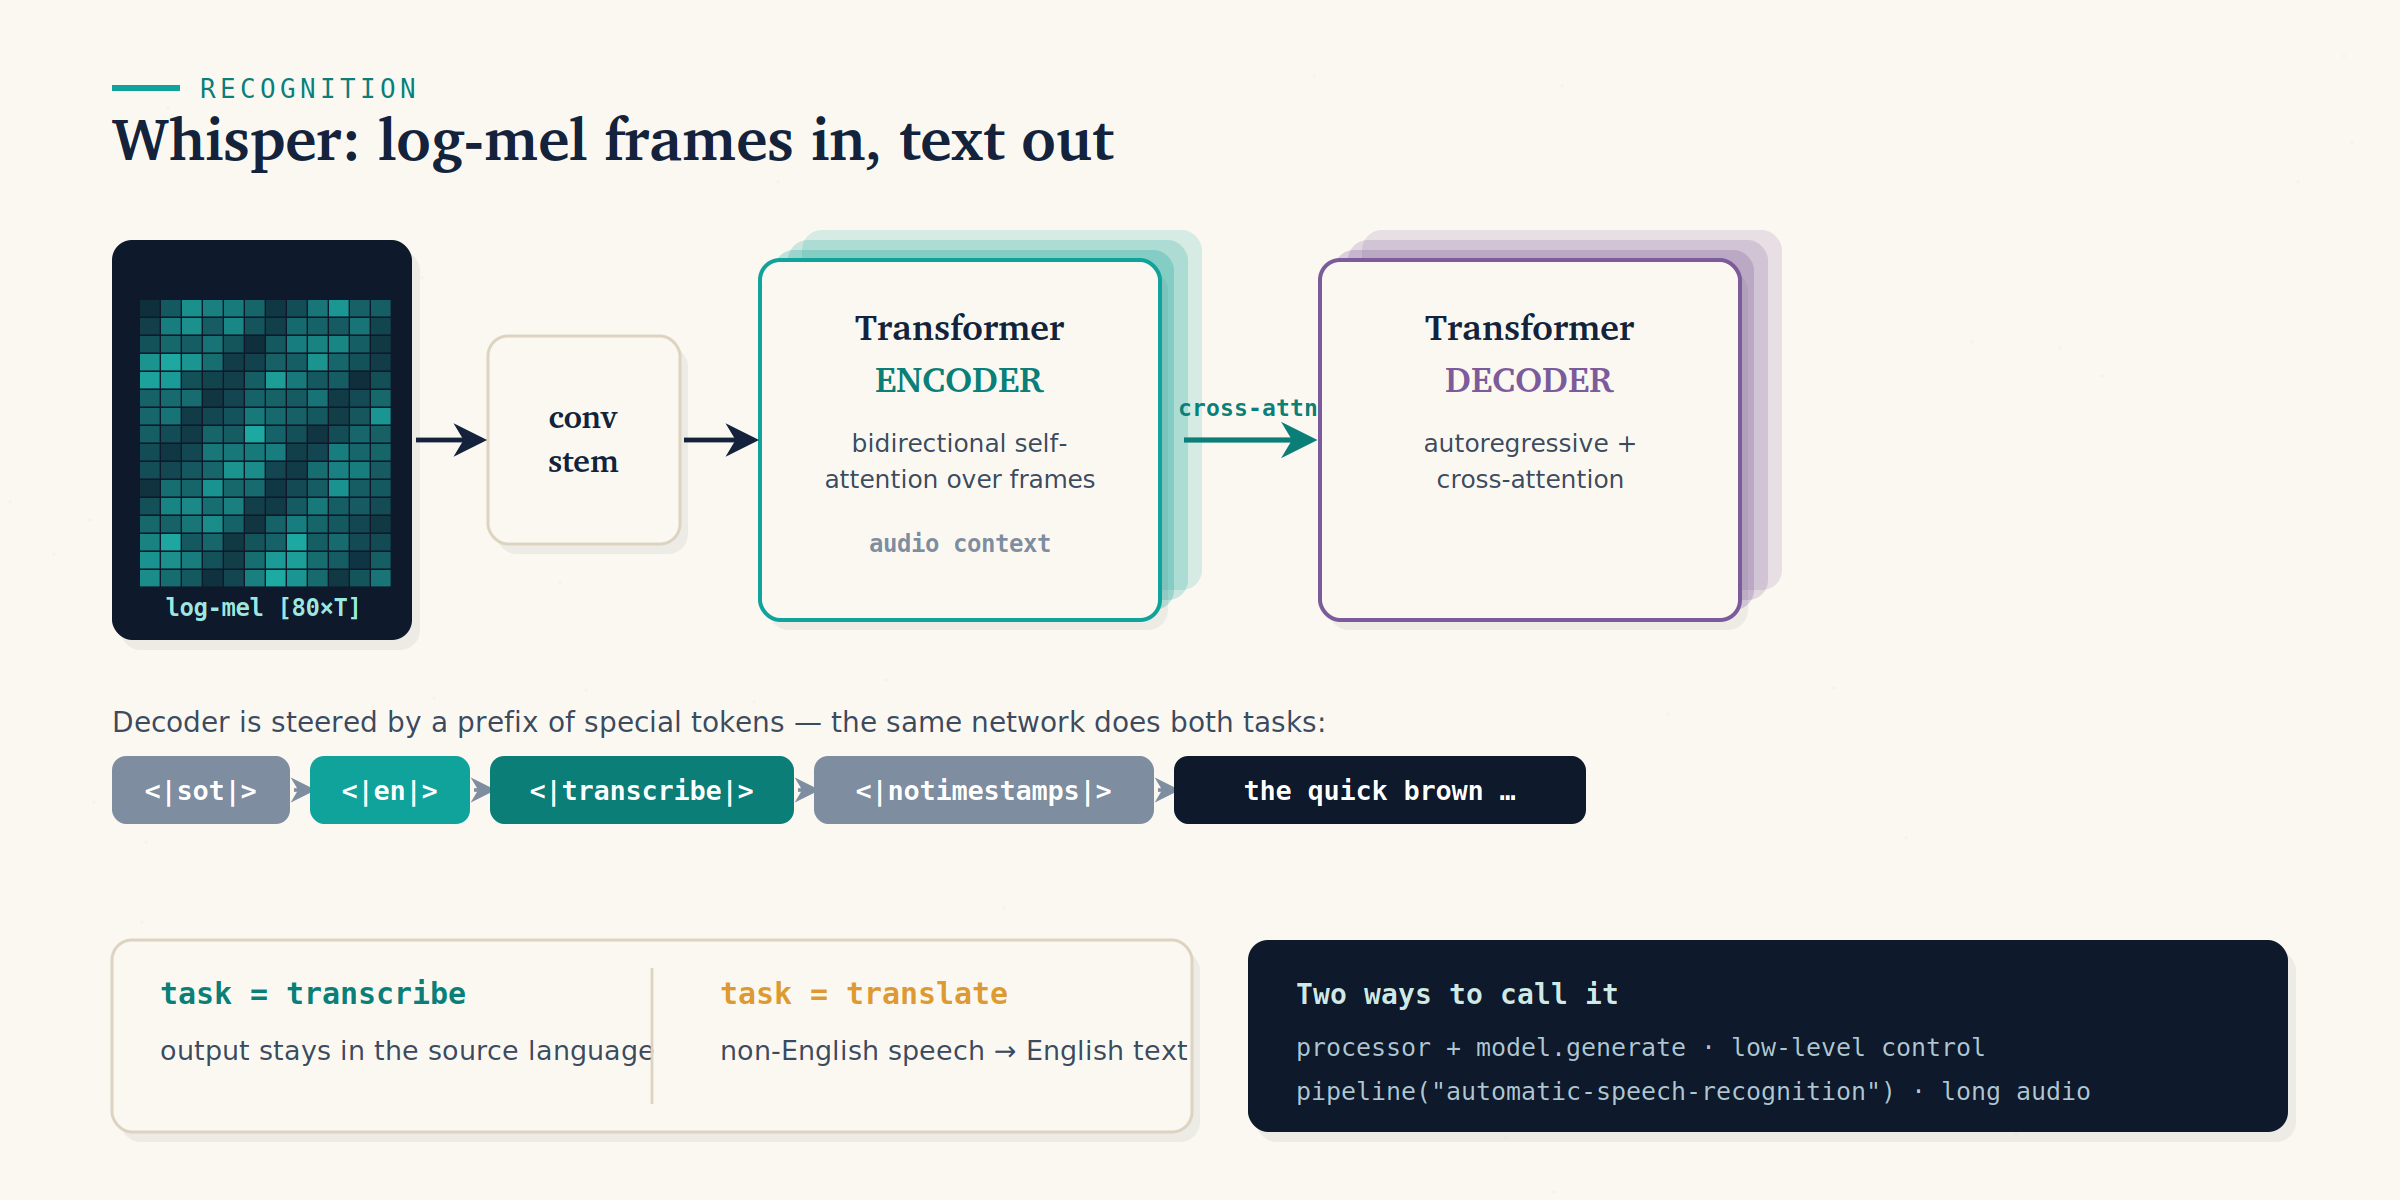

<sub><i>Encoder–decoder over 80-band log-mel. A special-token prefix steers the same weights between transcribe and translate.</i></sub>

Conv stem → Transformer **encoder** (bidirectional over frames) →
Transformer **decoder** (autoregressive + cross-attention). Task set by a
**token prefix** (`<|startoftranscript|> <|en|> <|transcribe|>
<|notimestamps|>`). Default **`whisper-base.en`** for speed; switch
`ASR_MODEL_ID` to **`whisper-large-v3-turbo`** for the production target.

Decoding is autoregressive: at each step the decoder attends to the fixed
audio memory (cross-attention) and the tokens emitted so far (causal
self-attention), predicts the next token, appends it, and repeats.

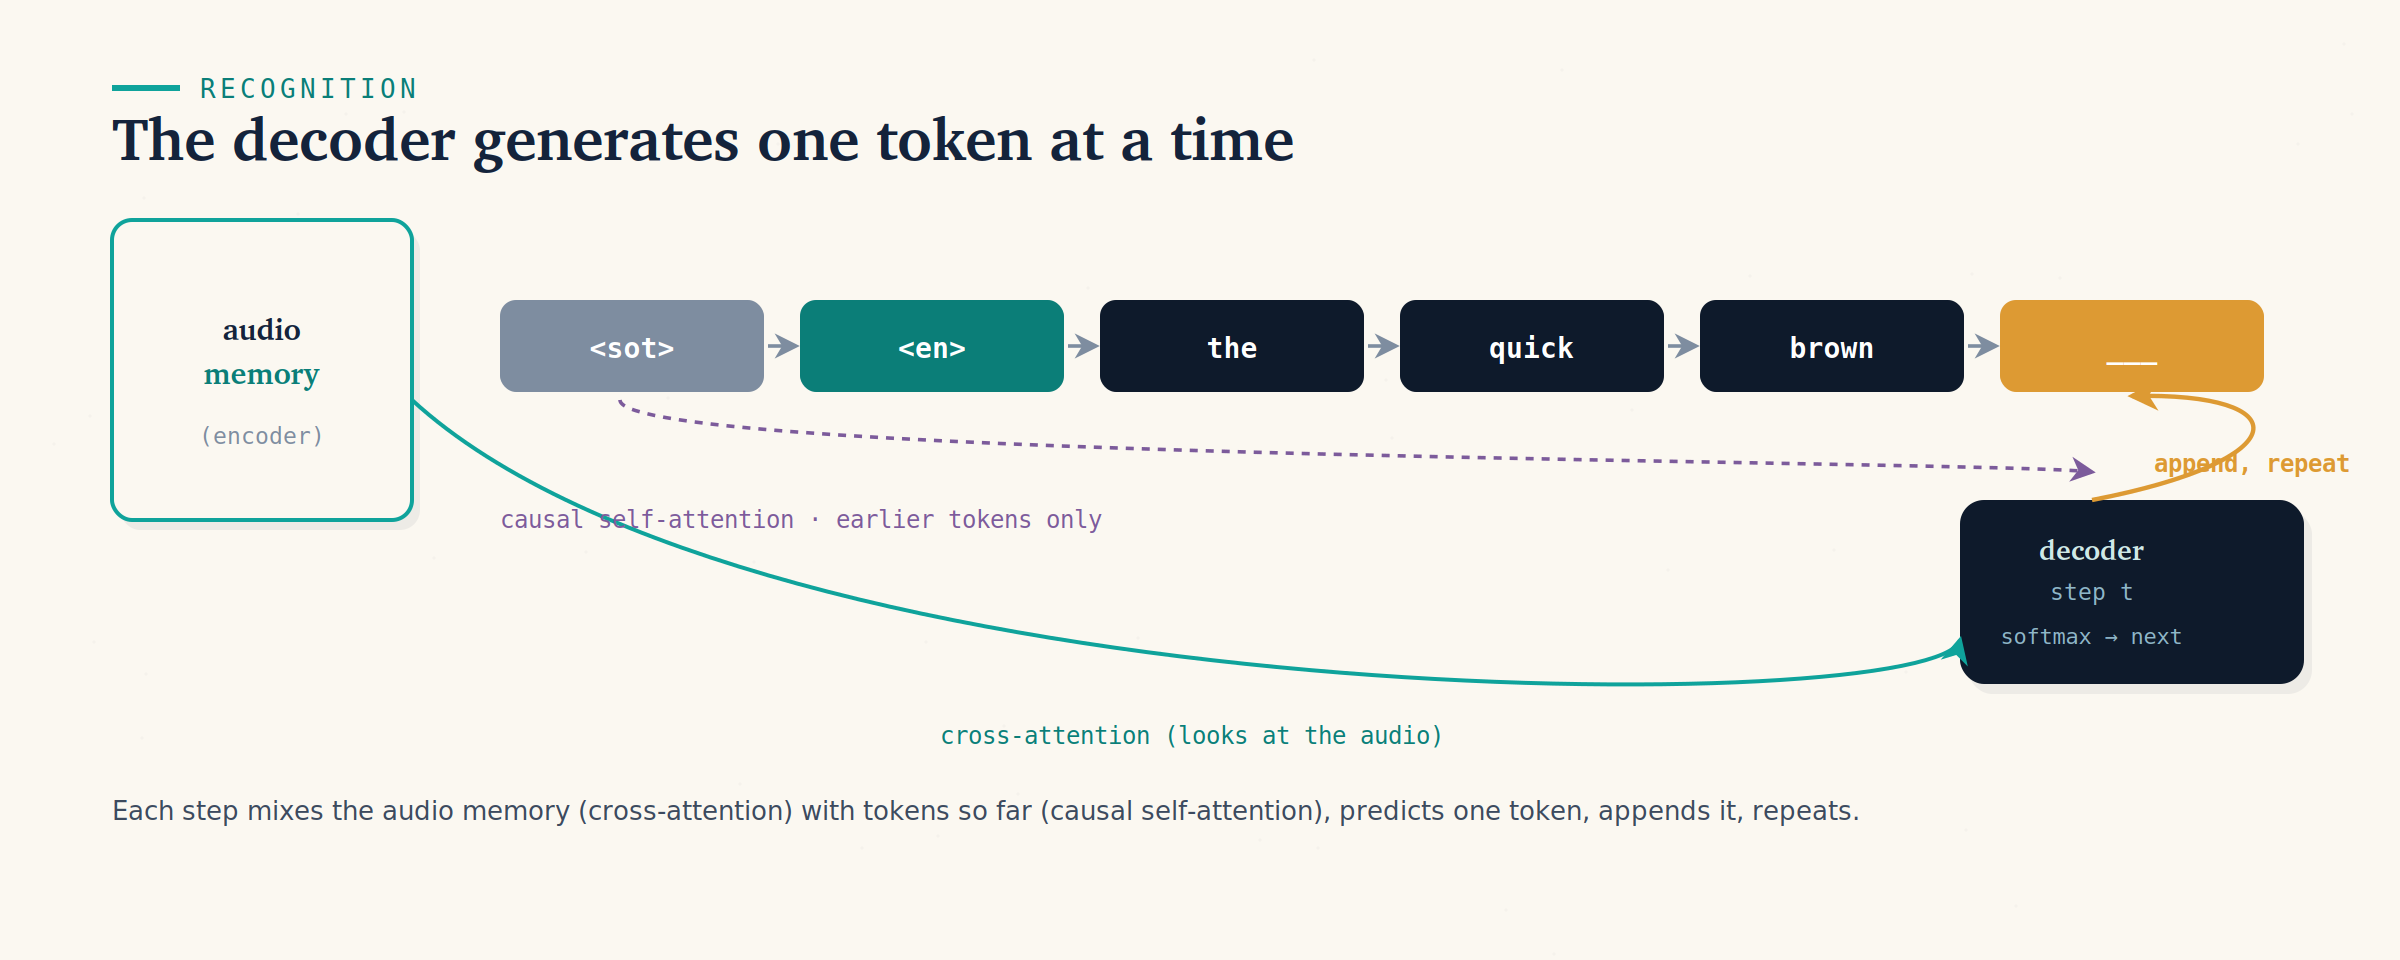

<sub><i>One token per step: cross-attention reads the audio, causal self-attention reads prior tokens, predict → append → repeat.</i></sub>

In [ ]:
# Guarded load: clean message instead of a traceback if HF is unreachable.
_ASR_READY = False
processor = model = hyp = None
if HF_OK and TORCH_OK:
    try:
        from transformers import (WhisperProcessor,
                                  WhisperForConditionalGeneration)
        processor = WhisperProcessor.from_pretrained(ASR_MODEL_ID)
        model = WhisperForConditionalGeneration.from_pretrained(
            ASR_MODEL_ID).to(device).eval()
        _ASR_READY = True
        n = sum(p.numel() for p in model.parameters())/1e6
        print(f"{ASR_MODEL_ID}  ~{n:.0f}M params on {device}")
    except Exception as e:
        print("ASR model not loaded (", type(e).__name__,
              "). Re-run in a networked GPU/CPU env to populate §4–§6.")
else:
    print("transformers/torch unavailable in this build -> §4–§6 will "
          "print run-with-network notices. Core DSP path (§1–§3) is real.")

preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/805 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/290M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

openai/whisper-base.en  ~73M params on cpu


In [ ]:
if _ASR_READY:
    feats = processor(y16, sampling_rate=16_000,
                      return_tensors="pt").input_features.to(device)
    print("input_features:", tuple(feats.shape), "(batch, 80 mel, frames)")
    with torch.no_grad():
        ids = model.generate(feats, max_new_tokens=128)
    hyp = processor.batch_decode(ids, skip_special_tokens=True)[0].strip()
    print("\nhypothesis :", hyp)
    print("reference  :", ref_text)
else:
    print("[skipped] needs the Whisper model. Expected output: the decoded "
          "transcript vs the reference sentence.")

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


input_features: (1, 80, 3000) (batch, 80 mel, frames)


Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_pr


hypothesis : Mr. Quilter is the apostle of the middle classes, and we are glad to welcome his gospel.
reference  : MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL


### 4.1 Evaluate it properly — Word Error Rate

ASR is **not** scored like text generation. **WER** = (substitutions +
insertions + deletions) / reference words, computed *after* normalization
(case, punctuation) so you measure recognition, not formatting.

First a tiny **deterministic** example (always runs, no model needed) so the
metric is concrete; then the real WER on the Whisper output when available.

In [ ]:
# Toy WER — always runs, so the concept is never skipped.
try:
    from jiwer import wer
    _ref = "the quick brown fox jumps over the lazy dog"
    _hyp = "the quick brown fox jump over lazy dog"  # 1 sub + 1 del
    print("reference :", _ref)
    print("hypothesis:", _hyp)
    print(f"toy WER   : {wer(_ref, _hyp):.3f}  "
          f"(2 word errors / 9 ref words = 0.222)")
except Exception as e:
    print("jiwer unavailable (", type(e).__name__,
          ") -> install it to compute WER.")

reference : the quick brown fox jumps over the lazy dog
hypothesis: the quick brown fox jump over lazy dog
toy WER   : 0.222  (2 word errors / 9 ref words = 0.222)


In [ ]:
# Real WER on the Whisper hypothesis (needs model + a real reference).
if _ASR_READY and not USING_SYNTH:
    from jiwer import wer
    try:
        from transformers.models.whisper.english_normalizer import \
            BasicTextNormalizer
        norm = BasicTextNormalizer()
    except Exception:
        import re
        norm = lambda s: re.sub(r"[^a-z0-9 ]", "", s.lower()).strip()
    print(f"reference (norm): {norm(ref_text)}")
    print(f"hypothesis(norm): {norm(hyp)}")
    print(f"\nWER raw        : {wer(ref_text.lower(), hyp.lower()):.3f}")
    print(f"WER normalized : {wer(norm(ref_text), norm(hyp)):.3f}  "
          f"<- report this one")
else:
    print("[skipped real WER] needs a Whisper transcript AND a reference. "
          "Run with network + LibriSpeech; the toy WER above still shows "
          "how the metric behaves.")

reference (norm): mister quilter is the apostle of the middle classes and we are glad to welcome his gospel
hypothesis(norm): mr quilter is the apostle of the middle classes and we are glad to welcome his gospel 

WER raw        : 0.176
WER normalized : 0.059  <- report this one


## 5 · Long audio, chunking and timestamps (≈ 6 min)

Whisper was trained on **fixed 30 s** windows; longer inputs must be split.
The HF `pipeline` automates this:

- `chunk_length_s=30` — 30 s windows (Whisper's native receptive field).
- `stride_length_s=5` — overlap neighbours 5 s so boundary words aren't lost;
  predictions are stitched back.
- `return_timestamps=True` — per-segment start/end times.

The stride overlap is the key: a word landing on a 30 s seam is still seen
whole inside a neighbouring chunk, and the overlapping region is merged so
nothing is doubled or dropped.

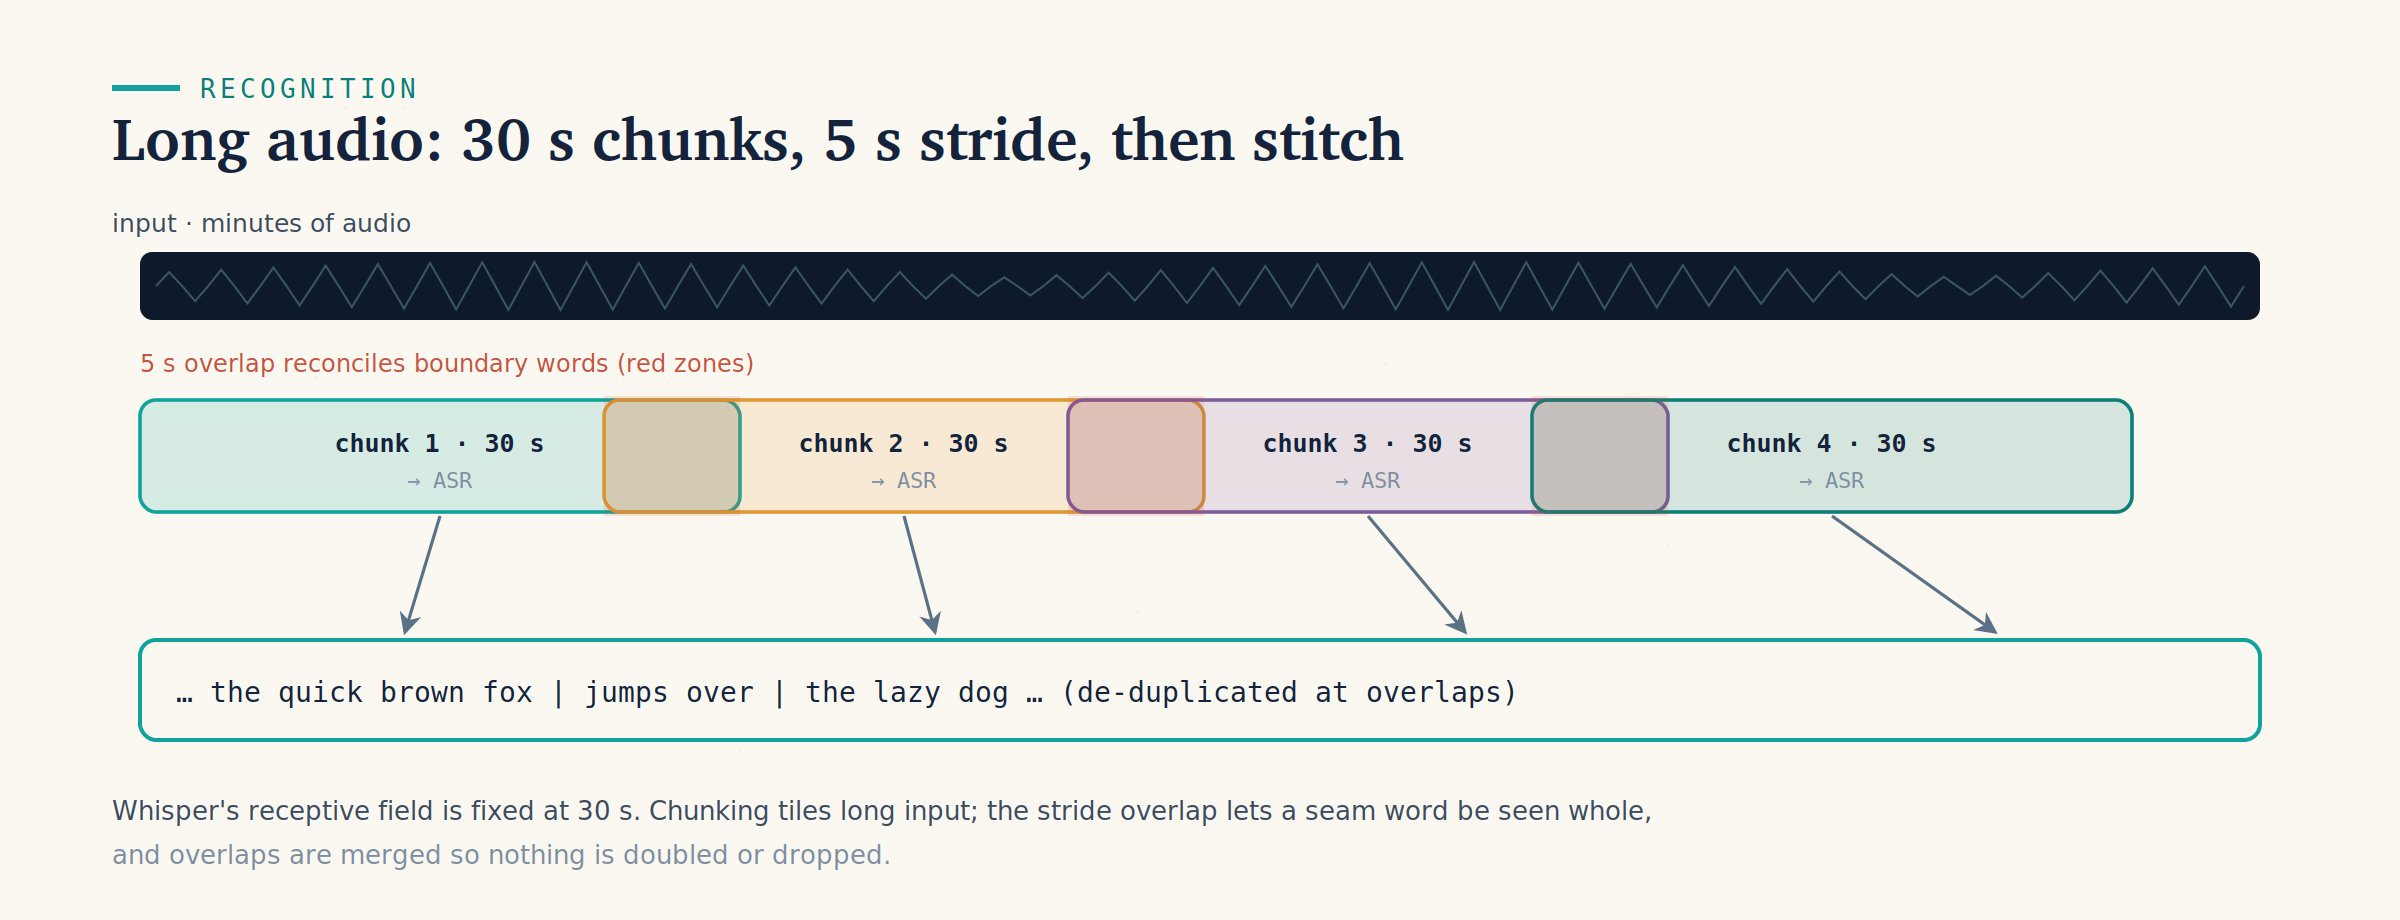

<sub><i>30 s chunks with 5 s stride; overlapping regions (red) are reconciled into one continuous, de-duplicated transcript.</i></sub>

In [ ]:
if _ASR_READY:
    from transformers import pipeline
    asr = pipeline(
        "automatic-speech-recognition", model=model,
        tokenizer=processor.tokenizer,
        feature_extractor=processor.feature_extractor,
        device=pipe_device, chunk_length_s=30, stride_length_s=5,
        return_timestamps=True)
    try:
        from datasets import load_dataset
        clip = load_dataset("distil-whisper/librispeech_long", "clean",
                             split="validation")[0]["audio"]
        wav, csr = np.asarray(clip["array"], np.float32), \
                   clip["sampling_rate"]
    except Exception as e:
        print("long clip unavailable (", type(e).__name__,
              ") -> tiling the synthetic sample to ~35 s.")
        wav, csr = np.tile(y16, max(1, int(np.ceil(35*16000/len(y16))))), \
                   16000
    print(f"clip: {len(wav)/csr:.1f} s (> 30 s -> chunked)\n")
    out = asr({"raw": wav, "sampling_rate": csr})
    for ch in out["chunks"][:6]:
        a, b = ch["timestamp"]                 # robust to None at edges
        a = 0.0 if a is None else float(a)
        b = a if b is None else float(b)
        print(f"[{a:6.2f}s -> {b:6.2f}s] {ch['text'].strip()}")
else:
    print("[skipped] needs the Whisper model. Expected: timestamped text "
          "chunks like '[ 0.00s -> 4.80s] ...'.")

Passing `generation_config` together with generation-related arguments=({'return_timestamps'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


README.md:   0%|          | 0.00/480 [00:00<?, ?B/s]

clean/validation-00000-of-00001-91350812(…):   0%|          | 0.00/1.98M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/1 [00:00<?, ? examples/s]

clip: 62.5 s (> 30 s -> chunked)

[  0.00s ->  29.40s] Mr. Quilter is the apostle of the middle classes, and we are glad to welcome his gospel. Nor is Mr. Quilter's manner less interesting than his matter. He tells us that at this festive season of the year, with Christmas and roast beef looming before us, similes drawn from eating and its results occur most readily to the mind. He has grave doubts whether Sir Frederick Layton's work is really Greek after all and
[ 29.40s ->  50.36s] can discover in it but little of Rocky Ithaca. Lynille's pictures are a sort of up-guards and atom paintings, and Mason's exquisite idols are as national as a jingo poem. Mr. Burkett Foster'sers landscapes, smile at one much in the same way that Mr. Carker used
[ 50.36s ->  52.92s] to flash his teeth.
[ 52.92s ->  59.48s] And Mr. John Collier gives his sitter a cheerful slap on the back, before he says, like a shampoo
[ 59.48s ->  61.56s] or a Turkish bath.
[ 61.56s ->  62.00s] Next man!


## 6 · Translation — actually runnable, with a cached fallback (≈ 6 min)

`base.en` can't translate, so we use a **multilingual** checkpoint and a real
**non-English** clip. Primary source: Google **FLEURS** (Italian, streamed).
To make the live demo **deterministic**, the first successful pull is cached
to `audio/non_english_sample.wav`; later runs (and offline runs) reuse the
cached file. Drop your own clip there to pin a specific example.

In [ ]:
import os, soundfile as sf
os.makedirs("audio", exist_ok=True)
CACHE = "audio/non_english_sample.wav"
it_audio = it_text = None

if os.path.exists(CACHE):                       # deterministic reuse
    it_audio, _sr = librosa.load(CACHE, sr=16_000)
    it_text = "(cached non-English clip)"
    print("using cached", CACHE, f"({len(it_audio)/16000:.1f} s)")
elif DATASETS_OK:
    try:
        from datasets import load_dataset
        s = next(iter(load_dataset("google/fleurs", "it_it",
                       split="validation", streaming=True)))
        it_audio = librosa.resample(
            np.asarray(s["audio"]["array"], np.float32),
            orig_sr=s["audio"]["sampling_rate"], target_sr=16_000)
        it_text = s["transcription"]
        sf.write(CACHE, it_audio, 16_000)       # cache for determinism
        print("fetched FLEURS it sample, cached ->", CACHE)
        print("Italian (ref):", it_text[:90], "...")
    except Exception as e:
        print("FLEURS unavailable (", type(e).__name__, ").")

if it_audio is None:
    print("No non-English clip. Put a 16 kHz WAV at", CACHE,
          "to enable a deterministic translation demo.")

README.md: 0.00B [00:00, ?B/s]

fetched FLEURS it sample, cached -> audio/non_english_sample.wav
Italian (ref): la parte settentrionale conosciuta come catena della sentinella vanta le montagne più alte ...


In [ ]:
if it_audio is not None and HF_OK and TORCH_OK:
    try:
        from transformers import pipeline
        xl = pipeline("automatic-speech-recognition",
                      model=TRANSLATE_MODEL_ID, device=pipe_device,
                      chunk_length_s=30)
        tr = xl(it_audio.copy(),
                generate_kwargs={"task":"transcribe"})["text"]
        en = xl(it_audio.copy(),
                generate_kwargs={"task":"translate"})["text"]
        print("transcribe (source) :", tr.strip())
        print("translate  (English):", en.strip())
    except Exception as e:
        print("translation model not loaded (", type(e).__name__,
              "). Re-run with network to see source vs English text.")
else:
    print("[skipped] needs a non-English clip + multilingual model. "
          "Expected: same audio -> Italian text vs English text.")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

preprocessor_config.json: 0.00B [00:00, ?B/s]

Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


transcribe (source) : La parte settentrionale, conosciuta come Catena della Sentinella, vanta le montagne più alte dell'Antartite, il massiccio del Vincent che raggiunge 4892 metri con il Monte Vincent.
translate  (English): The central part, known as the chain of the Sentinella, goes to the highest mountains of the Antarctic, the Massiccio del Vinson, which reaches 4,892 meters with the Vinson mountain.


## 7 · Recap, troubleshooting, exercise

### Recap — audio representation cheat-sheet

| Representation | Shape example | Used by |
|---|---|---|
| Waveform | `(samples,)` | raw audio input |
| Power spectrogram | `(1+n_fft/2, frames)` | intermediate |
| Log-mel | `(80, frames)` ≈ 100 frames/s | Whisper encoder |
| Token ids | `(seq_len,)` | Whisper decoder → text |
| CLAP embedding | `(512,)` (L2-normalized) | retrieval / zero-shot |

- Sample rate → bandwidth (`fs/2`); resample *with* an anti-alias filter.
- Bit depth → amplitude resolution: ~6 dB/bit.
- Voiced (periodic) vs unvoiced (noise); RMS/ZCR = intuition only.
- log-mel (25/10 ms, 80 bands → 100 fps); window length is a hard
  time–frequency trade-off.
- Whisper = encoder–decoder over log-mel; token prefix switches
  transcribe ↔ translate; long audio is chunked with stride; evaluate with
  **normalized WER**.

### Troubleshooting

- **Diagrams** → embedded as base64 in the markdown cells; they render with
  no external files. (Regenerate via `diagram_sources/render.py` only if you
  want to edit them.)
- **HF download / 403 / offline** → the DSP path still runs on the synthetic
  fallback; ASR/translation cells print a notice. Re-run with network.
- **MPS errors in the pipeline** → set `device = "cpu"` and re-run §4+.
- **`device=` TypeError** → already handled via integer `pipe_device`.
- **Empty/odd timestamps** → handled (`None` at chunk edges is coerced).

### Student exercise

1. Set `ASR_MODEL_ID = "openai/whisper-large-v3-turbo"`; re-run §4–§4.1.
   How much does **normalized WER** change vs `base.en`, and at what
   latency cost?
2. In §3.1, add a **third** window (e.g. 30 ms). Where does it sit on the
   time vs frequency trade-off — and which would you pick for fast
   consonant-heavy speech?


## 8 · OPTIONAL extension — CLAP audio↔text retrieval (≈ 10–15 min)

> **Optional.** Loads a second model + dataset. The core ASR lesson
> (§1–§6) does not depend on this. Run it if you have GPU/network time.

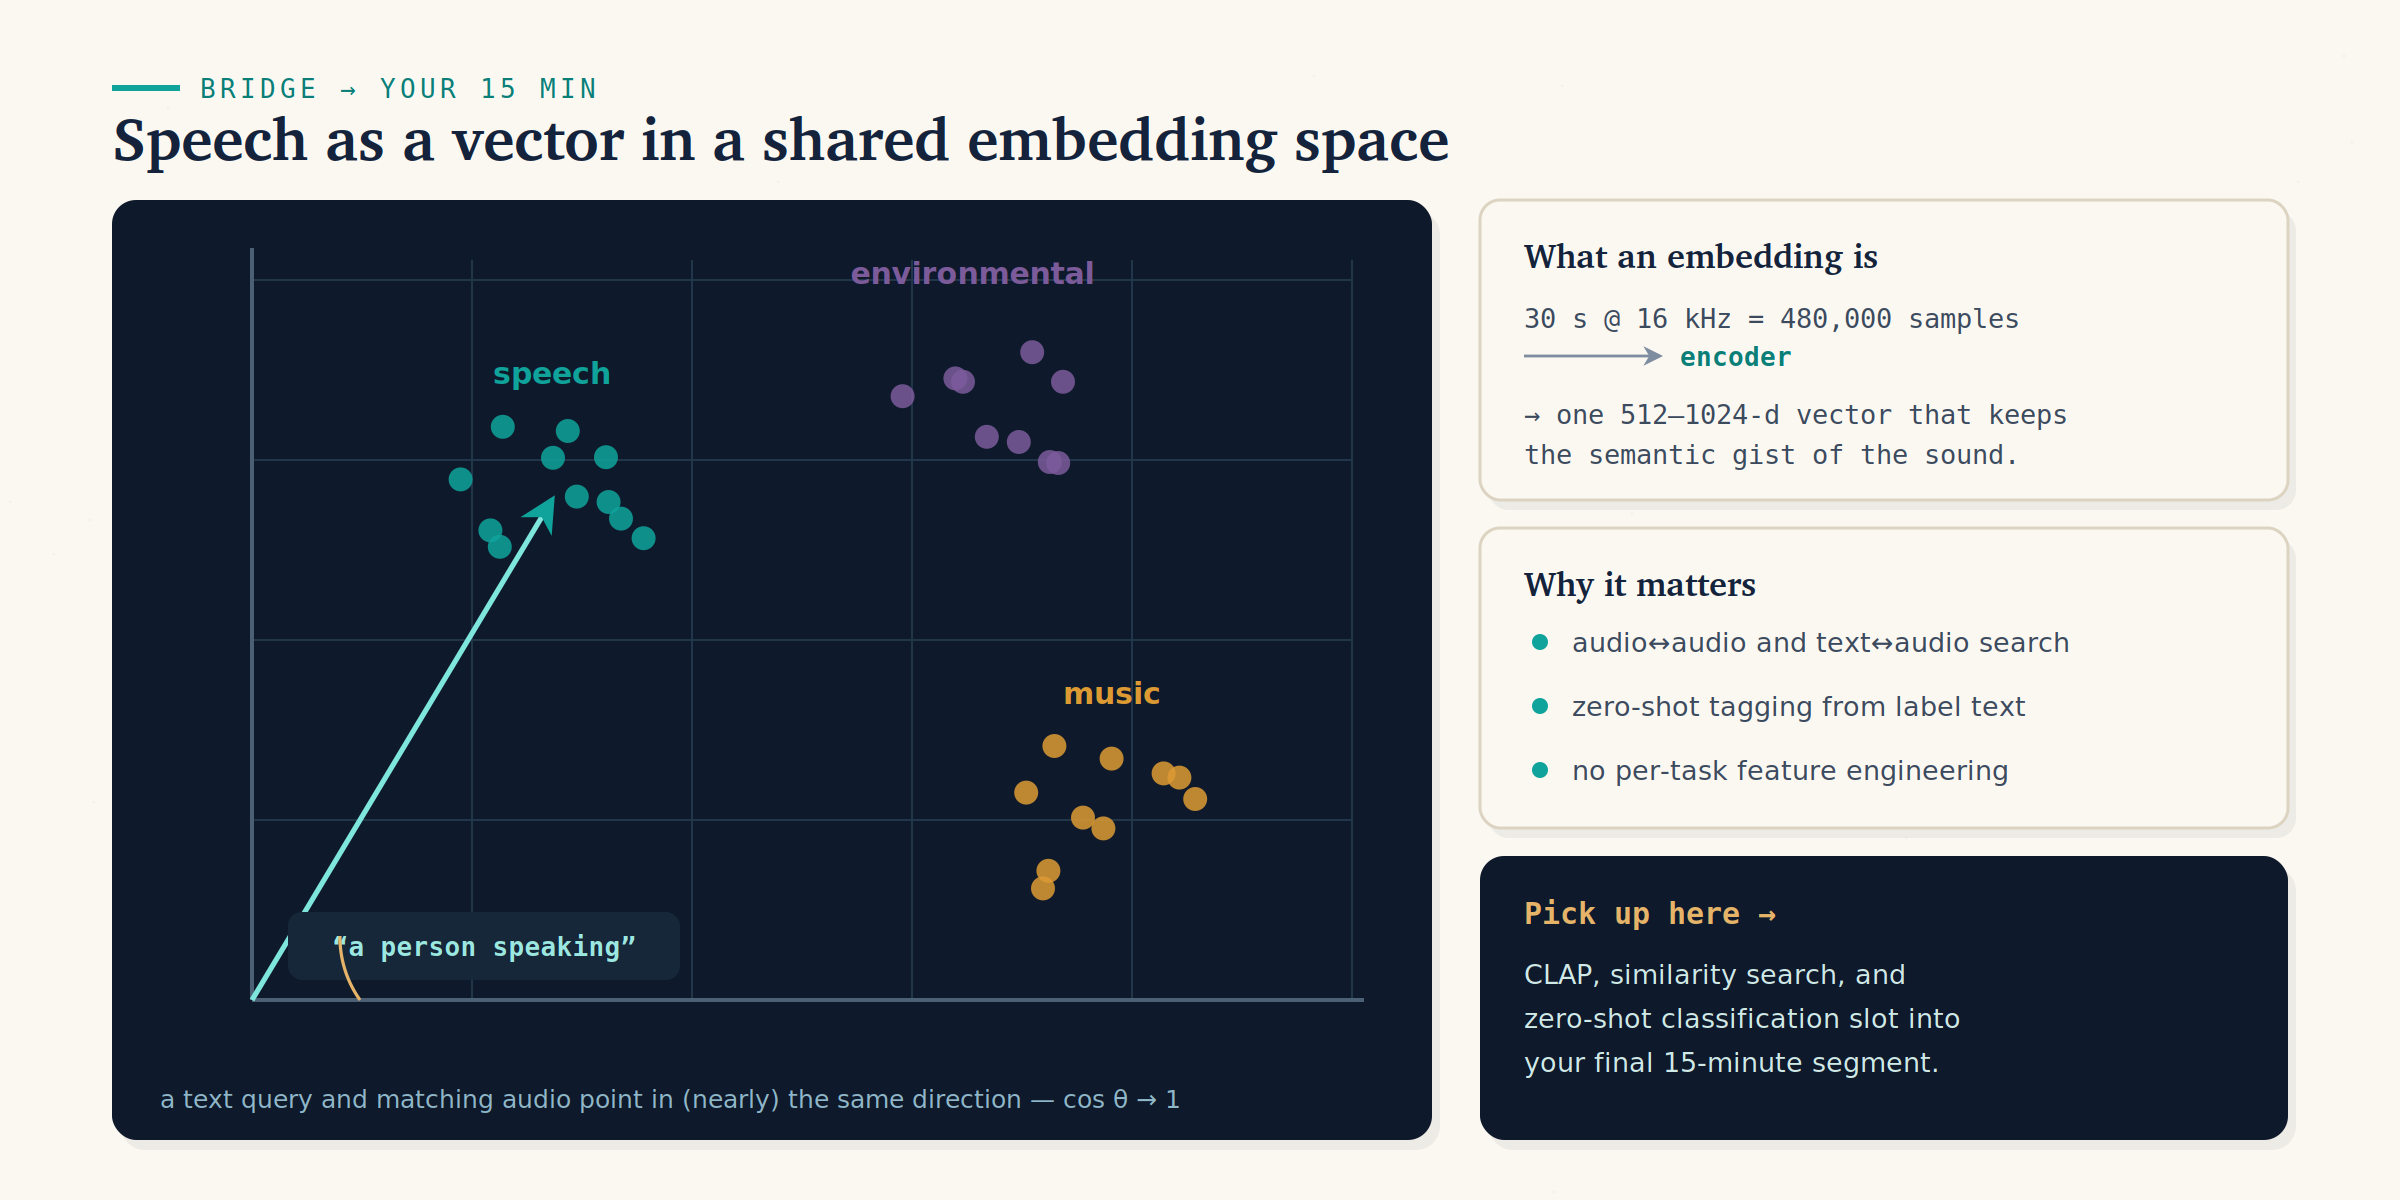

<sub><i>An encoder maps a whole clip to one 512–1024-d vector; matching audio and text point in nearly the same direction (cos θ → 1).</i></sub>

Whisper turns speech into *words*. **CLAP** maps audio and text into a
**shared** vector space, so `cos(audio, text)` is meaningful → text→audio
search and zero-shot tagging with no task-specific training.

In [ ]:
_CLAP_READY = False
clap = clap_proc = None
if HF_OK and TORCH_OK:
    try:
        from transformers import ClapModel, ClapProcessor
        clap_id = "laion/clap-htsat-unfused"
        clap_proc = ClapProcessor.from_pretrained(clap_id)
        clap = ClapModel.from_pretrained(clap_id).to(device).eval()
        _CLAP_READY = True
        print("CLAP loaded:", clap_id)
    except Exception as e:
        print("CLAP not loaded (", type(e).__name__,
              "). Optional section — safe to skip offline.")
else:
    print("[skipped] optional CLAP needs transformers + network.")

preprocessor_config.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/615M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/447 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/614M [00:00<?, ?B/s]

CLAP loaded: laion/clap-htsat-unfused


In [ ]:
CLAP_SR = 48_000     # CLAP expects 48 kHz
corpus = []
if _CLAP_READY:
    try:
        from datasets import load_dataset
        esc = load_dataset("ashraq/esc50", split="train", streaming=True)
        want = {"dog","rain","engine","crying_baby","church_bells",
                "chainsaw"}
        seen, sample_cats = set(), []
        for ex in esc:
            c = ex["category"]
            if len(sample_cats) < 8: sample_cats.append(c)
            if c in want and c not in seen:
                a = librosa.resample(
                    np.asarray(ex["audio"]["array"], np.float32),
                    orig_sr=ex["audio"]["sampling_rate"],
                    target_sr=CLAP_SR)
                corpus.append((c.replace("_"," "), a)); seen.add(c)
            if len(seen) == len(want): break
        if corpus:
            print("ESC-50 corpus:", [c for c,_ in corpus])
        else:
            print("No matching ESC-50 categories. Sample categories seen:",
                  sample_cats, "-> using synthetic corpus.")
    except Exception as e:
        print("ESC-50 unavailable (", type(e).__name__,
              ") -> synthetic corpus.")

    if not corpus:
        # Robustness-only fallback. NOTE: CLAP retrieval is far more
        # meaningful on real environmental audio than on synthetic tones.
        t = np.linspace(0, 3, CLAP_SR*3, endpoint=False).astype(np.float32)
        corpus = [
            ("speech",        librosa.resample(y16, orig_sr=16000,
                                                target_sr=CLAP_SR)),
            ("a pure tone",   0.3*np.sin(2*np.pi*440*t)),
            ("white noise",   0.1*np.random.randn(len(t)).astype(np.float32)),
            ("a rising siren",0.3*np.sin(2*np.pi*(300+200*t)*t)),
        ]
        print("synthetic corpus (robustness only):",
              [c for c,_ in corpus])
else:
    print("[skipped] CLAP not loaded.")

README.md:   0%|          | 0.00/345 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json: 0.00B [00:00, ?B/s]

ESC-50 corpus: ['dog', 'chainsaw', 'church bells', 'rain', 'engine', 'crying baby']


In [ ]:
if _CLAP_READY and corpus:
    import torch.nn.functional as F
    with torch.no_grad():
        ain = clap_proc(audio=[a for _,a in corpus],
                sampling_rate=CLAP_SR,
                return_tensors="pt").to(device)
        _ae = clap.get_audio_features(**ain)
        _ae = getattr(_ae, "audio_embeds", None) if hasattr(_ae, "audio_embeds") else _ae
        if not torch.is_tensor(_ae):
            _ae = _ae.pooler_output if hasattr(_ae, "pooler_output") else _ae.last_hidden_state.mean(1)
        aemb = F.normalize(_ae, dim=-1)
    def search(q, k=3):
        with torch.no_grad():
            tin = clap_proc(text=[q], return_tensors="pt",
                            padding=True).to(device)
            _te = clap.get_text_features(**tin)
            if not torch.is_tensor(_te):
                _te = _te.pooler_output if hasattr(_te, "pooler_output") else _te.last_hidden_state.mean(1)
            temb = F.normalize(_te, dim=-1)
        sims = (temb @ aemb.T).squeeze(0).cpu().numpy()
        print(f'query: "{q}"')
        for r, i in enumerate(sims.argsort()[::-1][:k], 1):
            print(f"  {r}. {corpus[i][0]:<16} cos={sims[i]:+.3f}")
        print()
    for q in ["a dog barking","heavy rain","a person talking",
              "an engine running"]:
        search(q)
else:
    print("[skipped] Expected: each text query ranks the audio corpus by "
          "cosine similarity, with the semantically matching clip on top.")

query: "a dog barking"
  1. dog              cos=+0.463
  2. engine           cos=+0.158
  3. church bells     cos=+0.028

query: "heavy rain"
  1. rain             cos=+0.466
  2. engine           cos=-0.006
  3. chainsaw         cos=-0.010

query: "a person talking"
  1. church bells     cos=-0.007
  2. dog              cos=-0.040
  3. rain             cos=-0.050

query: "an engine running"
  1. engine           cos=+0.374
  2. rain             cos=+0.175
  3. dog              cos=+0.098



### Extend further (springboard)

(1) swap to a real library (ESC-50 full, AudioSet-mini); (2) add
**audio→audio** search; (3) **zero-shot classification** via
`pipeline("zero-shot-audio-classification", model="laion/clap-htsat-unfused")`
with candidate label strings; (4) push embeddings into FAISS and measure
recall@k.

# The Video Modality — From Pixels to a Classifier

**A self-contained, illustrated ~60-minute notebook for mid/senior ML engineers.**

You already know images and transformers. Video adds **one axis — time** — and almost
every design decision in the field is a consequence of how that axis multiplies cost and
introduces motion as a new signal. This notebook walks the full pipeline and makes every
shape transformation explicit.

<p align="center">

</p>



### Learning objectives

By the end you should be able to:

1. Explain why raw video is expensive to store and model, and compute its memory/token cost.
2. Quantify temporal and spatial redundancy and use it to justify sampling + resizing.
3. Compare uniform, segment (TSN-style), and motion-aware frame sampling.
4. Explain why a frame-only classifier fails on temporal-order tasks — and *demonstrate* it.
5. Describe optical flow, full 3-D vs. factorized (2+1)D conv, tubelet tokenization, and the
   TimeSformer / ViViT / VideoMAE families at a practical, shape-aware level.
6. Build and honestly evaluate a video classifier (held-out metric, failure mode, fix) and
   reason about which metric a real video task needs.

---

## 0 · Setup

**Required** (core pipeline): `numpy`, `opencv-python`, `scikit-image`, `scikit-learn`,
`matplotlib`. **Optional** (only the guarded model demos): `torch`, `transformers`,
`imageio`/`imageio-ffmpeg` (only if you opt into a real video).

Uncomment the install line below on a fresh Colab / course workspace. The next cell then
*verifies* the required packages and **raises immediately** with a clear message if any are
missing — so a missing core dependency fails loudly in setup instead of three sections
later.

In [ ]:
# --- Fresh environment? Uncomment what you need -------------------------
%pip install -q numpy matplotlib opencv-python scikit-image scikit-learn
%pip install -q imageio imageio-ffmpeg          # only for USE_REAL_VIDEO
%pip install -q scikit-video                    # bundles a REAL clip, no network
%pip install -q torch transformers accelerate   # only for USE_REAL_MODEL
print("If imports below fail, uncomment the matching line above and re-run.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 18.4 MB/s eta 0:00:00
If imports below fail, uncomment the matching line above and re-run.


In [ ]:
import os, sys, time, hashlib, warnings, importlib
import numpy as np

warnings.filterwarnings("ignore")
RNG_SEED = 1234
np.random.seed(RNG_SEED)

def have(mod):
    """True iff a module can be imported (used to guard optional cells)."""
    try:
        importlib.import_module(mod); return True
    except Exception:
        return False

# ---- hard requirement check: fail loudly, here, not later ----------------
_REQUIRED = {"numpy": "numpy", "cv2": "opencv-python",
             "skimage": "scikit-image", "sklearn": "scikit-learn",
             "matplotlib": "matplotlib"}
_missing = [pip for mod, pip in _REQUIRED.items() if not have(mod)]
if _missing:
    raise ImportError(
        "Missing REQUIRED packages: " + ", ".join(_missing) +
        "  ->  %pip install -q " + " ".join(_missing) +
        "  (these are core; only torch/transformers are optional)")

import matplotlib.pyplot as plt
import matplotlib as mpl
import cv2, sklearn, skimage

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 10,
    "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.grid": True,
    "grid.alpha": 0.25, "image.cmap": "magma",
})

# ====== OFFLINE-FIRST FLAGS — flip to True to opt into network ============
USE_REAL_VIDEO = True   # True -> use a real clip in §1 (local file or download)
USE_REAL_MODEL = True   # True -> attempt VideoMAE (§6) and CLIP4Clip (§8)
VIDEO_PATH     = None    # e.g. "sample.mp4": a LOCAL file (no network needed);
                         # if None and USE_REAL_VIDEO, a tiny sample is fetched
# =========================================================================

def banner(title):
    print("=" * 64 + f"\n{title}\n" + "=" * 64)

banner("Environment")
print(f"python      : {sys.version.split()[0]}")
print(f"numpy       : {np.__version__}")
print(f"opencv      : {cv2.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"scikit-image: {skimage.__version__}")
print(f"torch       : {'present' if have('torch') else 'absent (optional)'}")
print(f"transformers: {'present' if have('transformers') else 'absent (optional)'}")
print(f"scikit-video: {'present -> real clip available offline' if have('skvideo') else 'absent (optional; enables a real bundled clip)'}")
print(f"USE_REAL_VIDEO = {USE_REAL_VIDEO}   USE_REAL_MODEL = {USE_REAL_MODEL}")
print("default: fully offline & deterministic")


Environment
python      : 3.12.13
numpy       : 2.0.2
opencv      : 4.13.0
scikit-learn: 1.6.1
scikit-image: 0.25.2
torch       : present
transformers: present
scikit-video: present -> real clip available offline
USE_REAL_VIDEO = True   USE_REAL_MODEL = True
default: fully offline & deterministic


## 1 · A video is a 4-D tensor

<p align="center">

</p>

Strip the container away and a clip is just `frames × H × W × C` — a stack of images
indexed by time, sampled at `fps`. Two facts on the diagram drive everything later:

* **Memory is linear in length.** `bytes ≈ T·H·W·C`. Ten minutes of 1080p RGB at 30 fps
  is **~112 GB** as uint8 raw RGB (`600 × 30 × 1920 × 1080 × 3` bytes ≈ 1.12 × 10¹¹ B).
  As float32 tensors the *same* data is **~448 GB**, before batching or activations. You
  *never* feed raw video to a model.
* **You cannot seek to an arbitrary frame for free.** Codecs store occasional **I-frames**
  (full keyframes) and reconstruct **P/B-frames** from neighbors (a *GOP*). Random access
  decodes from the previous keyframe forward — relevant the moment you do strided sampling.

### Acquiring a clip (offline-first)

By default (`USE_REAL_VIDEO = False`) we **do not touch the network**: the clip is a
**deterministic** synthetic clip — a moving object on a textured background. To use a real
clip, set `USE_REAL_VIDEO = True` in §0 and either point `VIDEO_PATH` at a **local `.mp4`**
(recommended — no network, just decode/sample your own file) or leave it `None` to *attempt*
a small sample download. Any failure falls back silently to the same synthetic clip, which
is also the labeled data source for the classifier in §7, so it is reusable and
reproducible.

In [ ]:
def synth_clip(T=40, H=112, W=112, motion="LR", seed=0,
               speed=1.0, jitter=0.0, clutter_seed=None):
    """Deterministic clip: a disc translating over static distractors + noise.

    motion in {LR,RL,UD,DU} -> travel direction. Returns uint8 (T,H,W,3).

    speed         scales how far the disc travels across the clip (1.0 = full
                  span, 0.5 = half) -> separable only by *motion magnitude*.
    jitter        std (px) of per-frame random shake added to the position
                  -> makes the task non-trivially separable.
    clutter_seed  if set, decorrelates background clutter from `seed` so
                  appearance varies independently of the label.

    Defaults reproduce the original clip exactly (speed=1, jitter=0).
    This same function is the labeled dataset for the classifier in section 7.
    """
    rng = np.random.default_rng(seed)
    crng = np.random.default_rng(seed if clutter_seed is None else clutter_seed)
    bg = crng.integers(18, 36, (H, W, 3), dtype=np.uint8)
    for _ in range(5):                              # static background clutter
        x, y = crng.integers(8, W - 8), crng.integers(8, H - 8)
        cv2.rectangle(bg, (x - 5, y - 5), (x + 5, y + 5),
                      tuple(int(v) for v in crng.integers(40, 90, 3)), -1)
    clip, r = np.empty((T, H, W, 3), np.uint8), 11
    for t in range(T):
        f = bg.copy()
        p = (t / (T - 1)) * speed                   # fraction of span travelled
        if   motion == "LR": cx, cy = r + (W - 2*r) * p,        H / 2
        elif motion == "RL": cx, cy = W - r - (W - 2*r) * p,    H / 2
        elif motion == "UD": cx, cy = W / 2, r + (H - 2*r) * p
        else:                cx, cy = W / 2, H - r - (H - 2*r) * p
        if jitter:
            cx += rng.normal(0, jitter); cy += rng.normal(0, jitter)
        cv2.circle(f, (int(np.clip(cx, r, W - r)), int(np.clip(cy, r, H - r))),
                   r, (235, 185, 65), -1)
        f = np.clip(f.astype(np.int16) + rng.integers(0, 6, (H, W, 3)), 0, 255)
        clip[t] = f.astype(np.uint8)
    return clip


def _decode_to_clip(path, T):
    """Decode `path`, uniformly sample T frames, resize to 112x112 RGB uint8."""
    cap = cv2.VideoCapture(path)
    fr = []
    while True:
        ok, f = cap.read()
        if not ok:
            break
        fr.append(cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
    cap.release()
    if not fr:
        raise RuntimeError("no frames decoded")
    idx = np.linspace(0, len(fr) - 1, T).round().astype(int)
    return np.stack([cv2.resize(fr[i], (112, 112)) for i in idx]).astype(np.uint8)


def load_clip(url=None, T=40):
    """Priority when USE_REAL_VIDEO: local VIDEO_PATH -> bundled scikit-video
    clip (NO network) -> small sample download. Default (flag False) and any
    failure fall back deterministically to the synthetic clip."""
    if not USE_REAL_VIDEO:
        return synth_clip(T=T, motion="LR", seed=1), "synthetic:LR (offline)", 25.0
    # 1) a LOCAL file needs no network -- the recommended real-video path
    if VIDEO_PATH:
        try:
            return _decode_to_clip(VIDEO_PATH, T), f"real-local:{VIDEO_PATH}", 25.0
        except Exception as e:
            print(f"[fallback] local '{VIDEO_PATH}' unreadable "
                  f"({type(e).__name__}); trying bundled clip.")
    # 2) a REAL clip bundled in the scikit-video wheel -- still zero network
    if have("skvideo"):
        try:
            import skvideo.datasets
            p = skvideo.datasets.bikes()          # real cyclists footage (offline)
            return _decode_to_clip(p, T), "real-bundled:bikes.mp4 (skvideo, offline)", 25.0
        except Exception as e:
            print(f"[fallback] bundled clip failed ({type(e).__name__}).")
    # 3) last resort: attempt a small sample download
    candidate = url or "imageio:cockatoo.mp4"
    try:
        import imageio.v3 as iio
        arr = iio.imread(candidate, index=None, plugin="pyav")   # network
        idx = np.linspace(0, len(arr) - 1, T).round().astype(int)
        clip = np.stack([cv2.resize(arr[i][..., :3], (112, 112)) for i in idx])
        return clip.astype(np.uint8), f"real:{candidate}", 25.0
    except Exception as e:
        print(f"[fallback] real video unavailable ({type(e).__name__}); "
              f"using deterministic synthetic clip.")
        return synth_clip(T=T, motion="LR", seed=1), "synthetic:LR", 25.0


CLIP, SOURCE, FPS = load_clip()
banner("Loaded clip")
print(f"source      : {SOURCE}")
print(f"shape (T,H,W,C) : {CLIP.shape}")
print(f"dtype       : {CLIP.dtype}")
print(f"fps         : {FPS}")
print(f"duration    : {CLIP.shape[0] / FPS:.2f} s")
print(f"raw memory  : {CLIP.nbytes / 1e6:.3f} MB  (= T*H*W*C bytes)")
print(f"sha1[:12]   : {hashlib.sha1(CLIP.tobytes()).hexdigest()[:12]}  (reproducible)")


Loaded clip
source      : real-bundled:bikes.mp4 (skvideo, offline)
shape (T,H,W,C) : (40, 112, 112, 3)
dtype       : uint8
fps         : 25.0
duration    : 1.60 s
raw memory  : 1.505 MB  (= T*H*W*C bytes)
sha1[:12]   : 32006d523fc7  (reproducible)


**Live figure — the actual frames.** Below is `CLIP` itself: a uniform stroll across
the time axis. Note how little changes between adjacent frames — that is the next section.

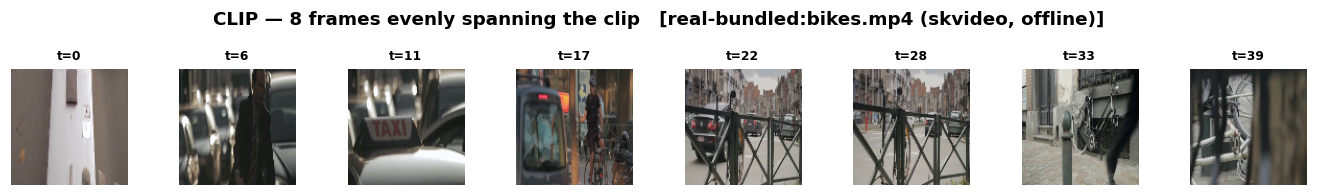

In [ ]:
def frame_grid(clip, idxs, title, cols=8):
    idxs = list(idxs)
    rows = int(np.ceil(len(idxs) / cols))
    fig, ax = plt.subplots(rows, cols, figsize=(1.55 * cols, 1.7 * rows))
    ax = np.atleast_2d(ax).reshape(rows, cols)
    for k in range(rows * cols):
        a = ax[k // cols, k % cols]; a.axis("off"); a.grid(False)
        if k < len(idxs):
            a.imshow(clip[idxs[k]]); a.set_title(f"t={idxs[k]}", fontsize=8)
    fig.suptitle(title, y=1.02, fontweight="bold")
    fig.tight_layout(); plt.show()

frame_grid(CLIP, np.linspace(0, len(CLIP) - 1, 8).round().astype(int),
           f"CLIP — 8 frames evenly spanning the clip   [{SOURCE}]")


## 1b · The same pipeline on a *real* clip


This cell self-skips with a clear notice if `scikit-video` isn't installed
(`pip install scikit-video`). The §7 classifier deliberately stays **synthetic** — it needs
many clips with *controlled* direction/speed labels for an honest held-out metric, which a
single real clip can't provide.

real clip   : bikes.mp4  shape=(250, 272, 640, 3)  130.6 MB raw  (250 frames @ ~25 fps)
             at 10 min this codec footage would be ~7.8 GB raw uint8
real  consecutive-frame: MAE~7.8  SSIM~0.874
synth consecutive-frame: MAE~2.2   SSIM~0.945  <- real footage is noisier & less redundant, but still redundant
real flow   : mean|mag|=4.49  max=40.3 px (synthetic disc was ~3 px) — real motion is full-field


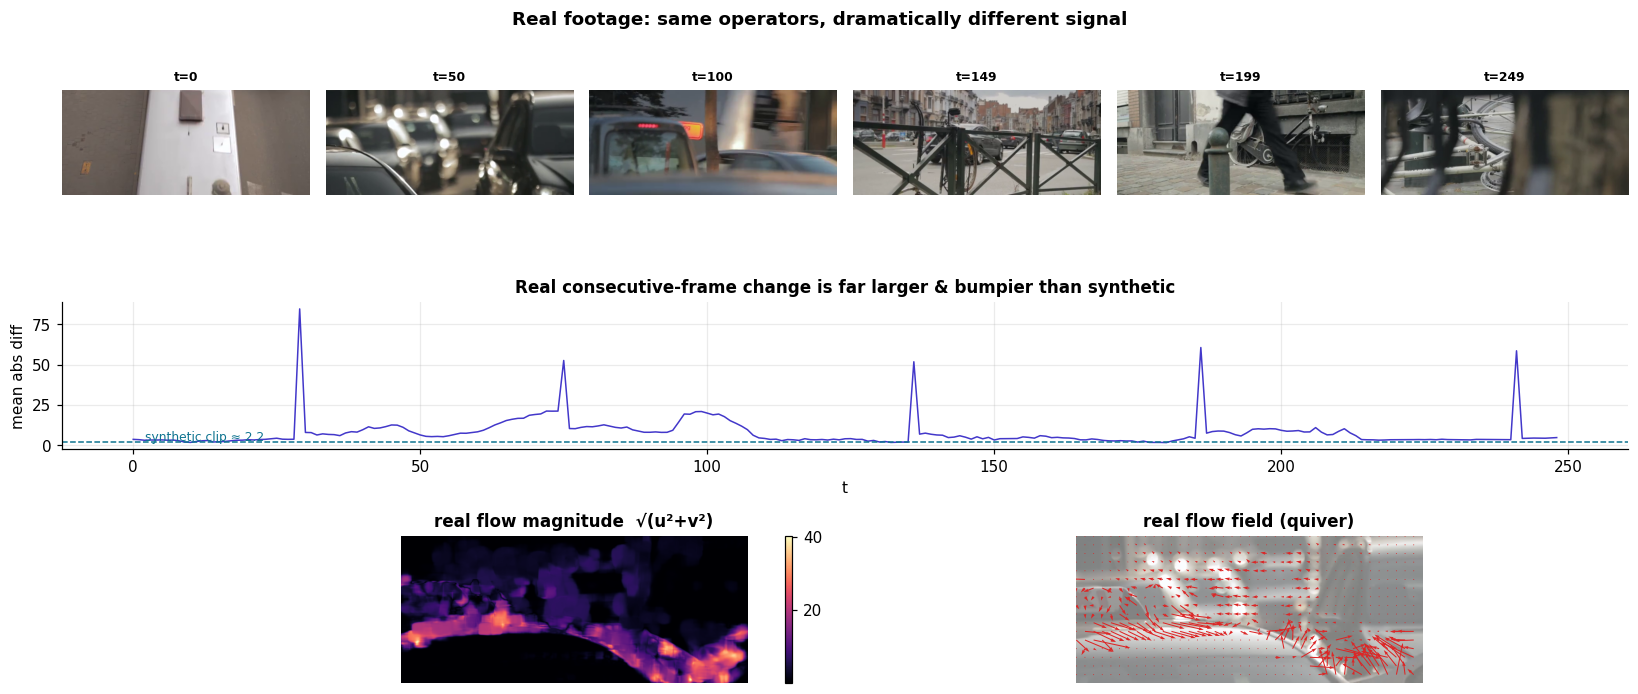

In [ ]:
def real_footage_demo():
    if not have("skvideo"):
        print("[skipped] scikit-video not installed.")
        print("Expected: `pip install scikit-video` ships a real cyclists clip "
              "(bikes.mp4) inside the wheel. This cell would then show real "
              "frames, real consecutive-frame SSIM/MAE (much lower / higher "
              "than the clean synthetic clip), and a real dense optical-flow "
              "field (full-frame, textured, large magnitude) — all offline.")
        return
    import skvideo.datasets
    from skimage.metrics import structural_similarity as ssim
    cap = cv2.VideoCapture(skvideo.datasets.bikes())
    fr = []
    while True:
        ok, f = cap.read()
        if not ok:
            break
        fr.append(cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
    cap.release()
    V = np.stack(fr)                                  # native-res REAL frames
    print(f"real clip   : bikes.mp4  shape={V.shape}  "
          f"{V.nbytes/1e6:.1f} MB raw  ({len(V)} frames @ ~25 fps)")
    print(f"             at 10 min this codec footage would be "
          f"~{V.nbytes/1e6/ (len(V)/25) * 600 / 1000:.1f} GB raw uint8")

    g = V.mean(-1).astype(np.float32)
    mae = np.array([np.abs(g[t+1]-g[t]).mean() for t in range(len(g)-1)])
    ss  = np.array([ssim(g[t], g[t+1], data_range=255)
                    for t in range(0, len(g)-1, 4)])
    syn = synth_clip(T=40, motion="LR", seed=1).mean(-1).astype(np.float32)
    syn_ss = np.mean([ssim(syn[t], syn[t+1], data_range=255)
                      for t in range(len(syn)-1)])
    print(f"real  consecutive-frame: MAE~{mae.mean():.1f}  "
          f"SSIM~{ss.mean():.3f}")
    print(f"synth consecutive-frame: MAE~2.2   SSIM~{syn_ss:.3f}  "
          f"<- real footage is noisier & less redundant, but still redundant")

    # real dense optical flow on a moving pair
    i = 60
    fl = cv2.calcOpticalFlowFarneback(
        cv2.cvtColor(V[i],   cv2.COLOR_RGB2GRAY),
        cv2.cvtColor(V[i+3], cv2.COLOR_RGB2GRAY),
        None, 0.5, 3, 15, 3, 5, 1.2, 0)
    u, vv = fl[..., 0], fl[..., 1]
    mag = np.hypot(u, vv)
    print(f"real flow   : mean|mag|={mag.mean():.2f}  max={mag.max():.1f} px "
          f"(synthetic disc was ~3 px) — real motion is full-field")

    grid_idx = np.linspace(0, len(V)-1, 6).round().astype(int)
    fig = plt.figure(figsize=(15, 6.2))
    for j, t in enumerate(grid_idx):
        ax = fig.add_subplot(3, 6, j + 1)
        ax.imshow(V[t]); ax.set_title(f"t={t}", fontsize=8)
        ax.axis("off"); ax.grid(False)
    axr = fig.add_subplot(3, 1, 2)
    axr.plot(mae, color="#4338ca", lw=1)
    axr.axhline(2.2, ls="--", c="#0e7490", lw=1)
    axr.text(2, 3.0, "synthetic clip ≈ 2.2", color="#0e7490", fontsize=8)
    axr.set(title="Real consecutive-frame change is far larger & bumpier "
                  "than synthetic", xlabel="t", ylabel="mean abs diff")
    axf = fig.add_subplot(3, 2, 5)
    im = axf.imshow(mag); axf.set_title("real flow magnitude  √(u²+v²)")
    axf.axis("off"); axf.grid(False)
    fig.colorbar(im, ax=axf, fraction=0.046)
    axq = fig.add_subplot(3, 2, 6)
    s = 16
    ys, xs = np.mgrid[0:fl.shape[0]:s, 0:fl.shape[1]:s]
    axq.imshow(V[i], alpha=0.55)
    axq.quiver(xs, ys, u[::s, ::s], -vv[::s, ::s],
               color="#dc2626", scale=300, width=0.003)
    axq.set_title("real flow field (quiver)"); axq.axis("off"); axq.grid(False)
    fig.suptitle("Real footage: same operators, dramatically different signal",
                 y=1.01, fontweight="bold")
    fig.tight_layout(); plt.show()

real_footage_demo()


## 2 · Temporal & spatial redundancy

<p align="center">

</p>

Video is the most redundant common modality. We *measure* both kinds of redundancy on the
real tensor rather than asserting them:

* **Temporal:** mean absolute difference and **SSIM** between consecutive frames. SSIM
  near 1.0 means frame *t+1* is almost a copy of *t* — dense sampling spends compute on
  near-duplicates.
* **Spatial:** local 3×3 standard deviation as a simple **texture/detail proxy** — *not* a
  formal information-theoretic measure. Large low-std regions carry little detail, which is
  exactly what resizing/patchifying discards cheaply.

mean consecutive-frame MAE : 25.530  (0 = identical)
mean consecutive-frame SSIM: 0.4976 (1 = identical)
~31% of pixels are low-detail by this proxy (spatial redundancy)


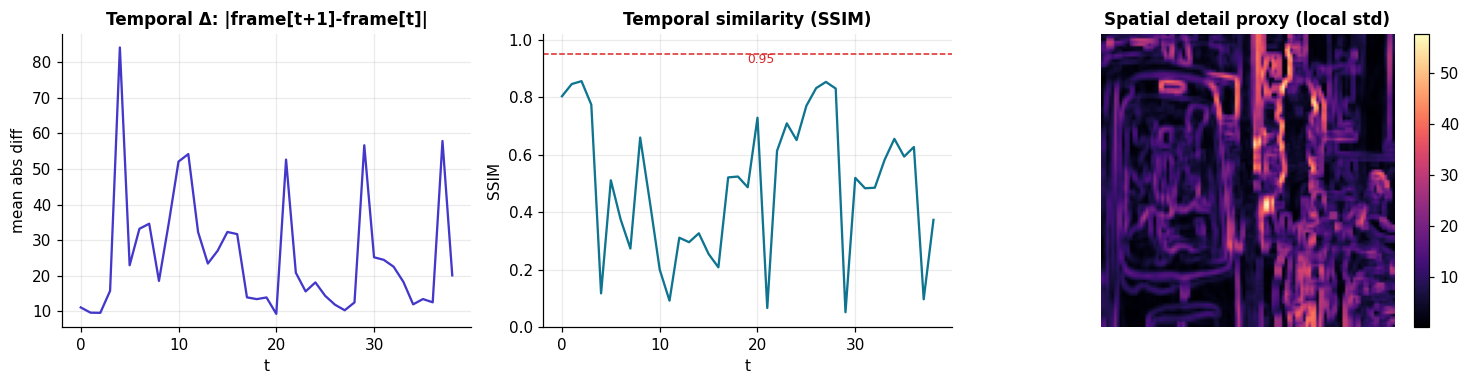

In [ ]:
from skimage.metrics import structural_similarity as ssim

gray = CLIP.mean(-1).astype(np.float32)                       # (T,H,W)
mae  = np.array([np.abs(gray[t + 1] - gray[t]).mean() for t in range(len(gray) - 1)])
ssm  = np.array([ssim(gray[t], gray[t + 1], data_range=255)
                 for t in range(len(gray) - 1)])

# spatial: local 3x3 std -- a texture/detail PROXY (not an info-theoretic measure)
mid  = gray[len(gray) // 2]
loc_mean = cv2.blur(mid, (3, 3))
loc_var  = cv2.blur(mid ** 2, (3, 3)) - loc_mean ** 2
loc_std  = np.sqrt(np.clip(loc_var, 0, None))

flat_frac = float((loc_std < loc_std.mean() * 0.5).mean())
print(f"mean consecutive-frame MAE : {mae.mean():.3f}  (0 = identical)")
print(f"mean consecutive-frame SSIM: {ssm.mean():.4f} (1 = identical)")
print(f"~{flat_frac*100:.0f}% of pixels are low-detail by this proxy "
      f"(spatial redundancy)")

fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.6))
ax[0].plot(mae, color="#4338ca"); ax[0].set(title="Temporal Δ: |frame[t+1]-frame[t]|",
          xlabel="t", ylabel="mean abs diff")
ax[1].plot(ssm, color="#0e7490"); ax[1].axhline(0.95, ls="--", c="#dc2626", lw=1)
ax[1].set(title="Temporal similarity (SSIM)", xlabel="t", ylabel="SSIM", ylim=(0, 1.02))
ax[1].text(0.5, 0.90, "0.95", color="#dc2626", fontsize=8, transform=ax[1].transAxes)
im = ax[2].imshow(loc_std); ax[2].grid(False)
ax[2].set(title="Spatial detail proxy (local std)"); ax[2].axis("off")
fig.colorbar(im, ax=ax[2], fraction=0.046)
fig.tight_layout(); plt.show()


## 3 · Frame sampling & resizing

<p align="center">

</p>

Because of that redundancy, the first real modeling decision is *which frames survive*.
Three families, in increasing sophistication and cost:

* **Uniform / fixed-stride** — cheapest, reproducible, the default; can step over a brief
  event entirely.
* **Segment-based (TSN-style)** — split into *K* equal segments, sample one frame per
  segment; keeps coverage while bounding count.
* **Content-aware** — keep frames where a signal (motion energy, scene-cut score) spikes;
  preserves rare events at higher preprocessing cost.

Below we apply uniform vs. a content-aware **motion-energy** selector to `CLIP`, then
quantify the tensor shrink from sampling + resizing.

uniform idx       : [0, 6, 11, 17, 22, 28, 33, 39]
motion-energy idx : [5, 8, 10, 11, 12, 22, 30, 38]
original tensor   : (40, 112, 112, 3)  ->  1.505 MB
sampled+resized   : (8, 64, 64, 3)  ->  0.098 MB
reduction         : 15.3x smaller (93.5% dropped)


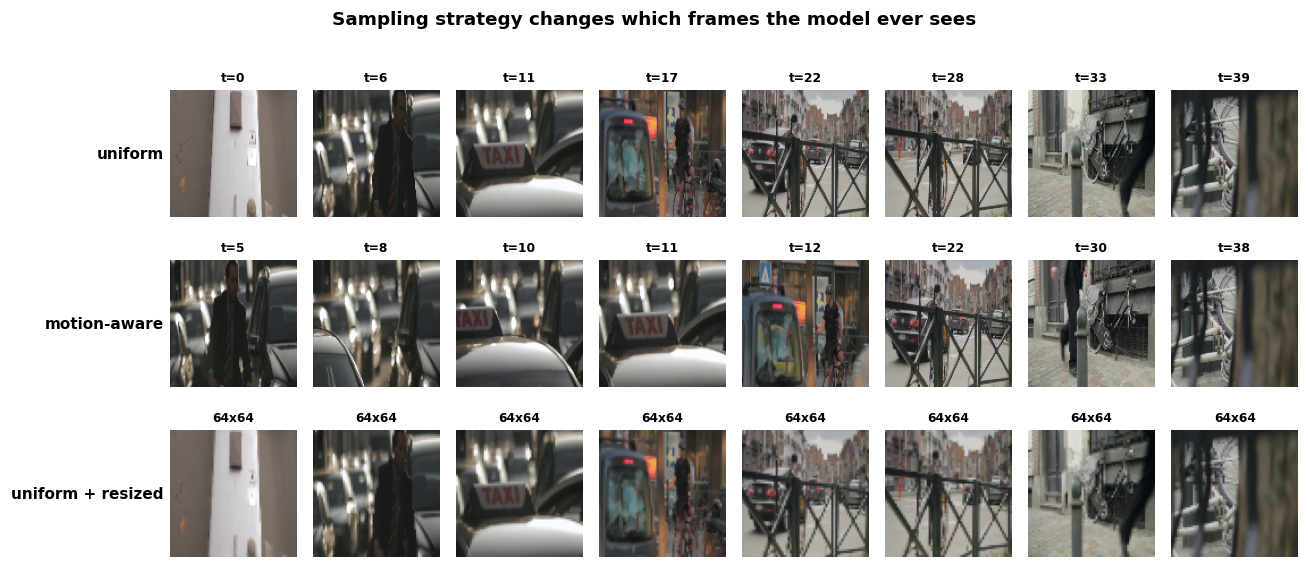

In [ ]:
def uniform_idx(T, n):
    return np.linspace(0, T - 1, n).round().astype(int)

def motion_energy(clip):
    g = clip.mean(-1).astype(np.float32)
    return np.array([0.0] + [np.abs(g[t] - g[t - 1]).mean()
                             for t in range(1, len(g))])

N = 8
u_idx = uniform_idx(len(CLIP), N)
me    = motion_energy(CLIP)
m_idx = np.sort(np.argsort(me)[-N:])               # top-N highest-motion frames

def resize_clip(clip, size):
    return np.stack([cv2.resize(f, (size, size)) for f in clip])

orig_bytes  = CLIP.nbytes
samp_resized = resize_clip(CLIP[u_idx], 64)
new_bytes   = samp_resized.nbytes

print(f"uniform idx       : {u_idx.tolist()}")
print(f"motion-energy idx : {m_idx.tolist()}")
print(f"original tensor   : {CLIP.shape}  ->  {orig_bytes/1e6:.3f} MB")
print(f"sampled+resized   : {samp_resized.shape}  ->  {new_bytes/1e6:.3f} MB")
print(f"reduction         : {orig_bytes/new_bytes:.1f}x smaller "
      f"({100*(1-new_bytes/orig_bytes):.1f}% dropped)")

fig, ax = plt.subplots(3, N, figsize=(1.5 * N, 5.2))
for j in range(N):
    ax[0, j].imshow(CLIP[u_idx[j]]); ax[0, j].set_title(f"t={u_idx[j]}", fontsize=8)
    ax[1, j].imshow(CLIP[m_idx[j]]); ax[1, j].set_title(f"t={m_idx[j]}", fontsize=8)
    ax[2, j].imshow(samp_resized[j]); ax[2, j].set_title("64x64", fontsize=8)
for a in ax.ravel(): a.axis("off"); a.grid(False)
for r, lbl in enumerate(["uniform", "motion-aware", "uniform + resized"]):
    ax[r, 0].set_ylabel(lbl, rotation=0, ha="right", va="center",
                        fontsize=10, fontweight="bold")
    ax[r, 0].axis("on"); ax[r, 0].set_xticks([]); ax[r, 0].set_yticks([])
    for s in ax[r, 0].spines.values(): s.set_visible(False)
fig.suptitle("Sampling strategy changes which frames the model ever sees",
             y=1.01, fontweight="bold")
fig.tight_layout(); plt.show()


## 4 · Spatio-temporal features

<p align="center">

</p>

A bag of independent frames cannot tell "door opening" from "door closing" — the frames
are the same set, only the *order* differs. The temporal axis must be modeled. Two
classic tools:

### 4a · Optical flow — a training-free motion field

Dense Farneback flow estimates a per-pixel displacement `(u, v)` between consecutive
frames. Its **magnitude** answers *how much* moved; its **angle** answers *which way*.
This is the cheapest motion descriptor and still a strong baseline feature.

> ⏱ *Runtime: a dense-flow pass over every adjacent pair runs in a Python loop — a few
> seconds here, but scales with `T·H·W`.*

mid-clip flow: mean dx=-0.025  mean dy=-3.272  max|mag|=4.00
clip-mean dx (sign = travel direction): +0.060


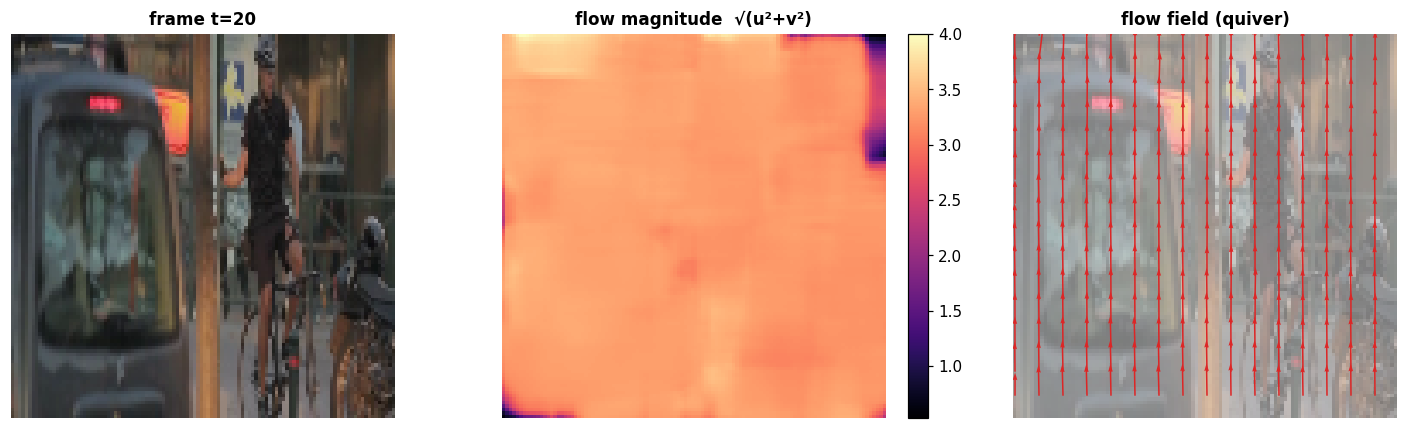

In [ ]:
i = len(CLIP) // 2
g0 = cv2.cvtColor(CLIP[i - 1], cv2.COLOR_RGB2GRAY)
g1 = cv2.cvtColor(CLIP[i],     cv2.COLOR_RGB2GRAY)
flow = cv2.calcOpticalFlowFarneback(g0, g1, None, 0.5, 3, 15, 3, 5, 1.2, 0)
u, v = flow[..., 0], flow[..., 1]
mag  = np.hypot(u, v)

# mean horizontal flow across the whole clip -> a single motion signature
dx_t = []
for t in range(len(CLIP) - 1):
    a = cv2.cvtColor(CLIP[t],     cv2.COLOR_RGB2GRAY)
    b = cv2.cvtColor(CLIP[t + 1], cv2.COLOR_RGB2GRAY)
    dx_t.append(cv2.calcOpticalFlowFarneback(a, b, None, 0.5, 3, 15, 3, 5, 1.2, 0)[..., 0].mean())
dx_t = np.array(dx_t)
print(f"mid-clip flow: mean dx={u.mean():+.3f}  mean dy={v.mean():+.3f}  "
      f"max|mag|={mag.max():.2f}")
print(f"clip-mean dx (sign = travel direction): {dx_t.mean():+.3f}")

fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.0))
ax[0].imshow(CLIP[i]); ax[0].set_title(f"frame t={i}"); ax[0].axis("off"); ax[0].grid(False)
im = ax[1].imshow(mag); ax[1].set_title("flow magnitude  √(u²+v²)")
ax[1].axis("off"); ax[1].grid(False); fig.colorbar(im, ax=ax[1], fraction=0.046)
s = 7
ys, xs = np.mgrid[0:flow.shape[0]:s, 0:flow.shape[1]:s]
ax[2].imshow(CLIP[i], alpha=0.55)
ax[2].quiver(xs, ys, u[::s, ::s], -v[::s, ::s], color="#dc2626",
             scale=40, width=0.004)
ax[2].set_title("flow field (quiver)"); ax[2].axis("off"); ax[2].grid(False)
fig.tight_layout(); plt.show()


### 4b · Full 3-D conv vs. factorized (2+1)D

A 3-D kernel `k×k×k` mixes space and time jointly but costs `∝ k³` per channel pair —
this is *why* 3-D CNN clips are capped at ~16–64 frames. Factorizing into a 2-D **spatial**
conv followed by a 1-D **temporal** conv keeps the receptive field while collapsing the
*spatio-temporal* factor from `k³` to `k²+k`. The cell below makes that gap concrete.

**Channel-aware caveat (what a real layer actually costs).** The scalar `k³` vs. `k²+k`
is intuition for the *kernel footprint*. A real layer also pays for input/output channels;
factorized convs add an intermediate width `C_mid`:

```
full 3-D conv :  k_t · k_h · k_w · C_in · C_out
(2+1)D conv  :  (k_h · k_w · C_in · C_mid)  +  (k_t · C_mid · C_out)
```

The win survives because the `k³` term no longer multiplies the full `C_in·C_out` product
— it factors into two much smaller sums (R(2+1)D / S3D). The plot shows the scale-invariant
kernel-footprint ratio; multiply through by channels for a true FLOP/param budget.

> ⚠️ **Not the same filter.** Factorization keeps a *comparable receptive-field shape* but
> changes the parameterization — it is **not mathematically identical** to an arbitrary full
> 3-D kernel unless extra low-rank/separability assumptions hold. The cell runs both on the
> same volume to make the cost structure concrete, *not* to show output equivalence.

> ⏱ *Runtime: the toy conv is pure NumPy looping over a small clip — ~5–20 s on a slow CPU.
> It exists to make the cost structure tangible, not to be fast.*

kernel size K = 3
  full  3-D params =  27  (k³)
  (2+1)D  params  =  12  (k² + k)
  parameter ratio full / (2+1)D = 2.25x
  at k=11 the ratio grows to 10.08x


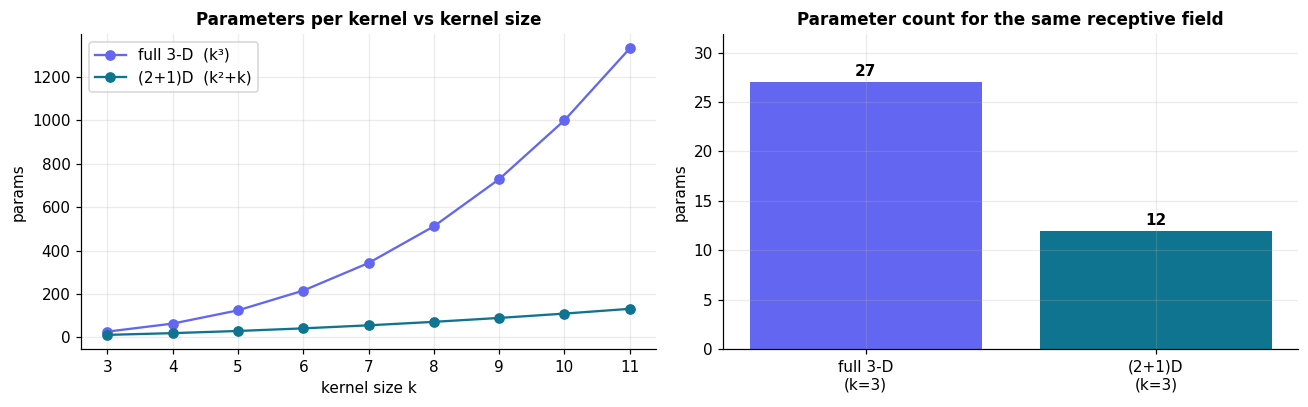

In [ ]:
def conv3d_full(vol, k):
    T, H, W = vol.shape; kt, kh, kw = k.shape
    pad = np.pad(vol, ((kt//2,)*2, (kh//2,)*2, (kw//2,)*2), mode="edge")
    out = np.zeros_like(vol)
    for dt in range(kt):
        for dh in range(kh):
            for dw in range(kw):
                out += k[dt, dh, dw] * pad[dt:dt+T, dh:dh+H, dw:dw+W]
    return out

def conv_2plus1d(vol, ks, kt):
    T, H, W = vol.shape
    ph = np.pad(vol, ((0, 0), (ks.shape[0]//2,)*2, (ks.shape[1]//2,)*2), mode="edge")
    sp = np.zeros_like(vol)
    for dh in range(ks.shape[0]):
        for dw in range(ks.shape[1]):
            sp += ks[dh, dw] * ph[:, dh:dh+H, dw:dw+W]
    pt = np.pad(sp, ((kt.shape[0]//2,)*2, (0, 0), (0, 0)), mode="edge")
    out = np.zeros_like(vol)
    for dt in range(kt.shape[0]):
        out += kt[dt] * pt[dt:dt+T]
    return out

vol = CLIP.mean(-1).astype(np.float32)
K = 3
rng = np.random.default_rng(0)
kf = rng.standard_normal((K, K, K), dtype=np.float64).astype(np.float32); kf /= kf.sum()
ks = rng.standard_normal((K, K),    dtype=np.float64).astype(np.float32); ks /= ks.sum()
kt = rng.standard_normal((K,),      dtype=np.float64).astype(np.float32); kt /= kt.sum()

# Run both on the SAME volume to make the operations concrete. These are
# NOT equivalent filters -- a random full 3-D kernel and a random factorized
# (2+1)D kernel only share a comparable receptive-field footprint. Timing is
# Python-loop bound, so we report the scale-invariant *parameter* gap.
_ = conv3d_full(vol, kf)
_ = conv_2plus1d(vol, ks, kt)

Ks = np.arange(3, 12)
p_full, p_sep = Ks**3, Ks**2 + Ks
print(f"kernel size K = {K}")
print(f"  full  3-D params = {K**3:3d}  (k³)")
print(f"  (2+1)D  params  = {K**2 + K:3d}  (k² + k)")
print(f"  parameter ratio full / (2+1)D = {K**3 / (K**2 + K):.2f}x")
print(f"  at k=11 the ratio grows to {11**3 / (11**2 + 11):.2f}x")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(Ks, p_full, "-o", color="#6366f1", label="full 3-D  (k³)")
ax[0].plot(Ks, p_sep,  "-o", color="#0e7490", label="(2+1)D  (k²+k)")
ax[0].set(title="Parameters per kernel vs kernel size",
          xlabel="kernel size k", ylabel="params"); ax[0].legend()
ax[1].bar([f"full 3-D\n(k={K})", f"(2+1)D\n(k={K})"], [K**3, K**2 + K],
          color=["#6366f1", "#0e7490"])
for xi, val in enumerate([K**3, K**2 + K]):
    ax[1].text(xi, val + 0.6, str(val), ha="center", fontweight="bold")
ax[1].set(title="Parameter count for the same receptive field",
          ylabel="params"); ax[1].set_ylim(0, K**3 * 1.18)
fig.tight_layout(); plt.show()


## 5 · Patch & tubelet tokenization

<p align="center">

</p>

Transformers need a *sequence*. A frame is cut into non-overlapping `P×P` patches; each
patch is flattened and linearly projected to one token carrying a **3-D position
`(x, y, t)`** — unlike the 1-D positions of text. A **tubelet** generalizes this to a
`P×P×t` space-time cube, dividing the token count by the tubelet depth `t`. Token count
is the single most important number for a video Transformer because attention is
*quadratic* in it.

frame (112, 112)  patch 16x16  ->  grid 7x7 = 49 tok/frame
  per-frame ViT     : 49 x 40 =   1960 tokens  (attention ∝ 1960²)
  tubelet depth 2   : 49 x 20 =    980 tokens  (attention ∝ 980²)
  tubelet depth 4   : 49 x 10 =    490 tokens  (attention ∝ 490²)


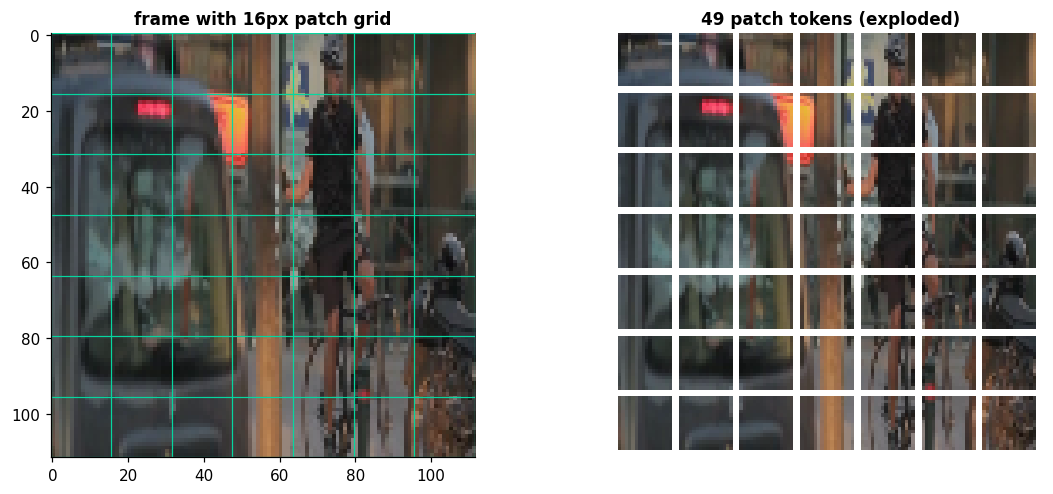

In [ ]:
def patchify(img, P):
    H, W = img.shape[:2]
    Hc, Wc = (H // P) * P, (W // P) * P
    img = img[:Hc, :Wc]
    grid = img.reshape(Hc // P, P, Wc // P, P, -1).swapaxes(1, 2)  # (gh,gw,P,P,C)
    return grid

P = 16
frame = CLIP[len(CLIP) // 2]
grid = patchify(frame, P)
gh, gw = grid.shape[:2]
tok_per_frame = gh * gw

# token-count comparison: per-frame ViT vs tubelet of depth 2 and 4
T = len(CLIP)
print(f"frame {frame.shape[:2]}  patch {P}x{P}  ->  grid {gh}x{gw} = {tok_per_frame} tok/frame")
for depth in (1, 2, 4):
    toks = tok_per_frame * (T // depth)
    tag = "per-frame ViT" if depth == 1 else f"tubelet depth {depth}"
    print(f"  {tag:<18}: {tok_per_frame} x {T//depth} = {toks:>6} tokens  "
          f"(attention ∝ {toks}²)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
ax[0].imshow(frame); ax[0].set_title(f"frame with {P}px patch grid")
for x in range(0, gw * P + 1, P): ax[0].axvline(x - .5, color="#06d6a0", lw=0.8)
for y in range(0, gh * P + 1, P): ax[0].axhline(y - .5, color="#06d6a0", lw=0.8)
ax[0].grid(False)
# mosaic with gaps to show patches are independent tokens
mosaic = np.ones((gh * (P + 2), gw * (P + 2), 3), np.uint8) * 255
for r in range(gh):
    for c in range(gw):
        mosaic[r*(P+2):r*(P+2)+P, c*(P+2):c*(P+2)+P] = grid[r, c]
ax[1].imshow(mosaic); ax[1].set_title(f"{tok_per_frame} patch tokens (exploded)")
ax[1].axis("off"); ax[1].grid(False)
fig.tight_layout(); plt.show()


## 6a · TimeSformer-style divided space-time attention

<p align="center">

</p>

The diagram above is **divided space-time attention** — the *TimeSformer* mechanism.
Joint attention over all `N` space-time tokens is `O(N²)`; splitting it into a temporal
pass (each patch attends across frames at its own location) followed by a spatial pass
(each patch attends within its frame) cuts that to `O(T²·S) + O(S²·T)`. This is one of
several ways the video-Transformer families tame the token-count blow-up — and they are
**not the same architecture**:

| Model family | Main idea | Strength | Weakness |
|---|---|---|---|
| 2-D CNN per frame | image model over sampled frames | cheap, simple | weak temporal order |
| 3-D CNN (C3D/I3D) | local spatio-temporal kernels | good motion locality | expensive for long clips |
| R(2+1)D / S3D | factorize space then time | cheaper than full 3-D | still local receptive field |
| **TimeSformer** | divided space-time attention | long-range temporal relations | token cost `O(N²)` |
| **ViViT** | factorized video transformer + tubelets | flexible tokenization | compute-heavy |
| **VideoMAE** | masked video pretraining over tubelets | data-efficient representation | not a one-line classifier story |
| Video-language (CLIP4Clip…) | joint video–text embedding | retrieval / captioning / QA | heavier infra |

Key point for the next cell: **VideoMAE does *not* use divided attention.** Its encoder is
a fairly standard ViT over **tubelets**, pretrained with masked-autoencoding. The diagram
above belongs to TimeSformer and is shown here for contrast.

## 6b · Guarded VideoMAE inference demo

The guarded cell runs `MCG-NJU/videomae-base-finetuned-kinetics` (Kinetics-400) **only if
`USE_REAL_MODEL = True`**; otherwise it self-skips with the exact shapes you would see and
**never crashes the notebook**. Watch the **sampled-frame input tensor** and the **400-way
logits** — those are the shapes that matter, not divided attention.

> **To actually run this section (`USE_REAL_MODEL = True` in §0):**
> * install the optional stack: `%pip install -q torch transformers accelerate`
> * ensure internet on first run, **or** pre-populate a local cache and set `HF_HOME`
>   (the weights download once, ~300 MB, then cache);
> * CPU works for *correctness* (a single clip is fine); use a GPU only if you need speed;
> * **expected I/O:** processor maps 16 sampled RGB frames → `pixel_values` of shape
>   `(1, 16, 3, 224, 224)`; model emits `logits` of shape `(1, 400)` → top-1 Kinetics
>   action label + softmax probability.

In [ ]:
def video_transformer_demo(clip):
    if not USE_REAL_MODEL:
        print("[skipped] USE_REAL_MODEL = False (offline default).")
        print("Expected (set USE_REAL_MODEL=True with weights available): "
              "VideoMAEImageProcessor + VideoMAEForVideoClassification "
              "(MCG-NJU/videomae-base-finetuned-kinetics) consume 16 sampled "
              "frames as a (1, 16, 3, 224, 224) tensor and emit (1, 400) "
              "Kinetics logits -> a top-1 action label + softmax prob. "
              "VideoMAE = ViT over tubelets (MAE pretraining); the divided "
              "attention in the diagram is TimeSformer's scheme, shown for "
              "contrast, not VideoMAE's internals.")
        return
    if not (have("torch") and have("transformers")):
        print("[skipped] USE_REAL_MODEL=True but torch/transformers absent.")
        print("Expected: install torch+transformers, then a "
              "(1, 16, 3, 224, 224) input -> (1, 400) Kinetics logits.")
        return
    try:
        import torch
        from transformers import (VideoMAEImageProcessor,
                                   VideoMAEForVideoClassification)
        name = "MCG-NJU/videomae-base-finetuned-kinetics"
        proc = VideoMAEImageProcessor.from_pretrained(name)   # network
        model = VideoMAEForVideoClassification.from_pretrained(name).eval()
        idx = np.linspace(0, len(clip) - 1, 16).round().astype(int)
        frames = [clip[k] for k in idx]
        inp = proc(frames, return_tensors="pt")
        with torch.no_grad():
            logits = model(**inp).logits
        p = logits.softmax(-1)[0]
        top = p.topk(5)
        print(f"input tensor : {tuple(inp['pixel_values'].shape)}  "
              f"(B, T, C, H, W)")
        print(f"logits       : {tuple(logits.shape)}  (400 Kinetics classes)")
        print("top-5 predictions:")
        for s, j in zip(top.values, top.indices):
            print(f"  {model.config.id2label[int(j)]:<32} {float(s):.3f}")
    except Exception as e:
        print(f"[skipped] model/weights unavailable "
              f"({type(e).__name__}: {str(e)[:90]}).")
        print("Expected: a (1, 16, 3, 224, 224) input and (1, 400) Kinetics "
              "logits -> a top-1 action label with its probability. "
              "(VideoMAE internals are a ViT over tubelets, not divided "
              "attention.)")

video_transformer_demo(CLIP)


Loading weights:   0%|          | 0/186 [00:00<?, ?it/s]

input tensor : (1, 16, 3, 224, 224)  (B, T, C, H, W)
logits       : (1, 400)  (400 Kinetics classes)
top-5 predictions:
  driving car                      0.054
  parkour                          0.039
  texting                          0.038
  hoverboarding                    0.031
  smoking                          0.029


## 7 · A real evaluation metric that always runs

The guarded cell above may skip offline, so we need a **classification result with a
genuine metric** that needs no downloads — and one that is *not* trivially perfect. We
build an **8-class** dataset = **4 travel directions × 2 overlapping speed bands** from the
deterministic generator, with **positional jitter** and **background decorrelated from the
label** so no single obvious feature solves it. We then escalate three models and watch the
metric move:

* **A · Frame-only baseline.** One *random* frame per clip → pixel features → classifier.
  A single unordered frame is insufficient to infer travel *direction* (the identical frame
  appears in an `LR` clip and its time-reversed `RL` counterpart) or *speed* (no temporal
  reference). Expect **≈ chance (12.5%)** — this is the lesson, demonstrated, not asserted.
* **B · Direction-only flow features** `[mean dx, std dx, mean dy, std dy]`. Encodes the
  *sign* of motion → nails direction, but is **blind to magnitude** → it **collapses
  slow vs. fast within each direction**. This is the deliberate **failure mode**; you can
  read it as a block structure in its confusion matrix.
* **C · Augmented spatio-temporal features** — add flow-**magnitude** mean/std and a
  **temporal acceleration** term. Magnitude reintroduces the speed axis → the failure mode
  *substantially* closes and held-out accuracy climbs well above B. It stays short of a
  suspicious 1.000 — overlapping speed bands and jitter keep some clips genuinely
  ambiguous, which is the honest outcome, not a bug.

The point is the *methodology* — temporal features → classifier → an honest held-out
metric, with a visible failure mode and a principled fix — which transfers directly to a
real backbone. Because 96 clips is small, we don't trust a single split: each model is
scored over **10 random 70/30 splits** (report mean ± std and min–max), and *one*
representative split (seed 42) is kept for the confusion matrices and a concrete
misclassified-clip example.

> ⏱ *Runtime: builds 96 small clips and runs dense flow over each — typically 15–45 s on
> CPU. Flow per clip is computed once and reused across feature sets B and C; the 30
> classifier fits (3 models × 10 splits) are sub-second.*

dataset : 96 clips, 8 classes (4 dir x 2 speed-bands), chance = 0.125
Repeated hold-out over 10 random 70/30 splits:
model                          mean    std    min    max
A frame-only      (256 px)    0.124  0.058  0.034  0.207   <- ~chance: a still frame can't encode order/speed
B direction-only  (4-D)       0.628  0.051  0.552  0.690   <- nails direction, COLLAPSES slow vs fast (failure mode)
C augmented       (7-D)       0.745  0.056  0.655  0.793   <- magnitude+accel substantially recover the speed axis

Representative split (seed 42): accB=0.483  accC=0.655
Per-class report for C on that split:
              precision    recall  f1-score   support

     LR-slow       0.75      1.00      0.86         3
     LR-fast       1.00      0.67      0.80         3
     RL-slow       1.00      0.25      0.40         4
     RL-fast       0.67      1.00      0.80         4
     UD-slow       0.50      0.50      0.50         4
     UD-fast       0.50      0.67      0.57         3
     DU-slo

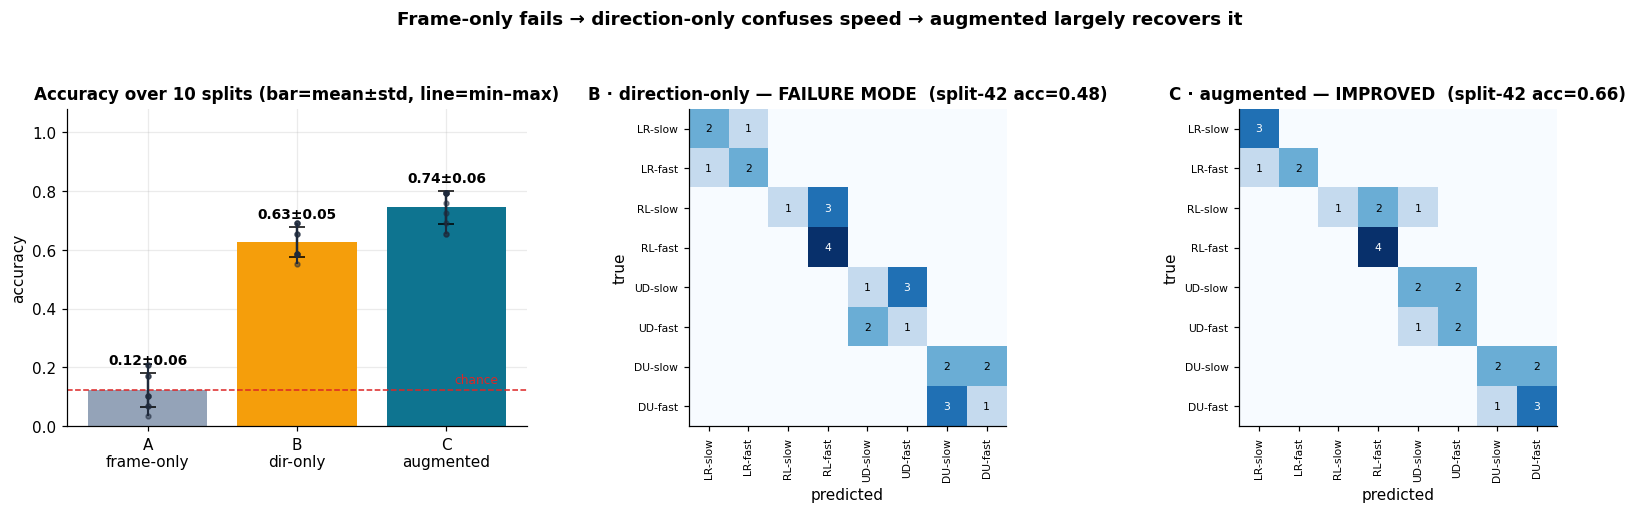

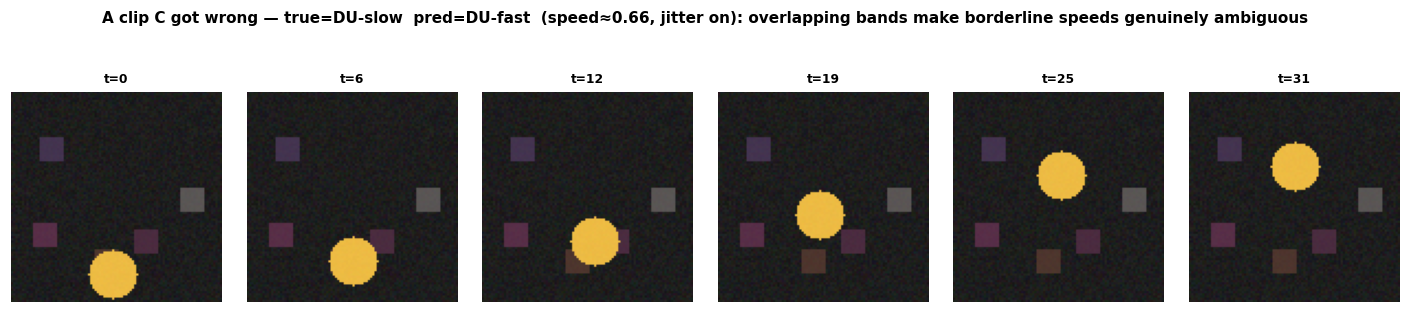

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report)

DIRS   = ["LR", "RL", "UD", "DU"]
# overlapping speed BANDS (Gaussian, clipped) so slow/fast are not cleanly
# separable -> the fix (model C) is strong but realistically imperfect.
SPEED_BANDS = {"slow": (0.70, 0.07), "fast": (0.92, 0.07)}
LABELS8 = [f"{d}-{s}" for d in DIRS for s in SPEED_BANDS]   # 8 classes

def clip_flow_stats(clip):
    """Compute dense flow ONCE; return per-pair (dx,dy,|mag|) sequences."""
    gr = [cv2.cvtColor(f, cv2.COLOR_RGB2GRAY) for f in clip]
    dx, dy, mg = [], [], []
    for a, b in zip(gr[:-1], gr[1:]):
        f = cv2.calcOpticalFlowFarneback(a, b, None, 0.5, 3, 15, 3, 5, 1.2, 0)
        dx.append(f[..., 0].mean()); dy.append(f[..., 1].mean())
        mg.append(np.hypot(f[..., 0], f[..., 1]).mean())
    return np.array(dx), np.array(dy), np.array(mg)

def feat_dir(dx, dy, mg):            # B: direction-only (blind to speed)
    return np.array([dx.mean(), dx.std(), dy.mean(), dy.std()], np.float32)

def feat_aug(dx, dy, mg):            # C: + magnitude + acceleration
    accel = np.abs(np.diff(mg)) if len(mg) > 1 else np.array([0.0])
    return np.array([dx.mean(), dx.std(), dy.mean(), dy.std(),
                     mg.mean(), mg.std(), accel.mean()], np.float32)

def st_features(clip):
    """7-D augmented spatio-temporal signature (reused by the §8 retrieval)."""
    return feat_aug(*clip_flow_stats(clip))

CLASSES = DIRS                       # kept for the §8 retrieval gallery

# ---- build the harder 8-class dataset (flow computed once per clip) -------
Xframe, XB, XC, y, META = [], [], [], [], []
N_PER = 12
for li, (d, sp) in enumerate([(d, s) for d in DIRS for s in SPEED_BANDS]):
    mu, sg = SPEED_BANDS[sp]
    for k in range(N_PER):
        sd = 100 + li * 50 + k
        spd = float(np.clip(np.random.default_rng(sd).normal(mu, sg),
                            0.45, 1.0))            # bands OVERLAP at the tails
        kw = dict(T=32, H=96, W=96, motion=d, seed=sd,
                  speed=spd, jitter=2.0, clutter_seed=7000 + k)
        clip = synth_clip(**kw)                     # bg decorrelated from label
        # A: a single RANDOM (orderless) frame, downsampled gray pixels
        rf = np.random.default_rng(sd).integers(0, len(clip))
        g  = cv2.cvtColor(clip[rf], cv2.COLOR_RGB2GRAY)
        Xframe.append(cv2.resize(g, (16, 16)).astype(np.float32).ravel() / 255.)
        dx, dy, mg = clip_flow_stats(clip)          # flow ONCE
        XB.append(feat_dir(dx, dy, mg))
        XC.append(feat_aug(dx, dy, mg))
        y.append(li); META.append(kw)
Xframe, XB, XC, y = map(np.array, (Xframe, XB, XC, y))

idx_all = np.arange(len(y))
chance  = 1.0 / len(LABELS8)

def fit_predict(X, tr, te):
    clf = make_pipeline(StandardScaler(),
                        LogisticRegression(max_iter=4000))
    clf.fit(X[tr], y[tr])
    pr = clf.predict(X[te])
    return accuracy_score(y[te], pr), pr

# ---- repeated hold-out over 10 random splits (defensible, not one lucky split)
SEEDS = list(range(10))
acc_runs = {"A": [], "B": [], "C": []}
for rs in SEEDS:
    tr, te = train_test_split(idx_all, test_size=0.3,
                              random_state=rs, stratify=y)
    acc_runs["A"].append(fit_predict(Xframe, tr, te)[0])
    acc_runs["B"].append(fit_predict(XB,     tr, te)[0])
    acc_runs["C"].append(fit_predict(XC,     tr, te)[0])
acc_runs = {k: np.array(v) for k, v in acc_runs.items()}

# ---- one REPRESENTATIVE split (seed 42) for confusion matrices + report ----
tr42, te42 = train_test_split(idx_all, test_size=0.3,
                              random_state=42, stratify=y)
accB, prB = fit_predict(XB, tr42, te42)
accC, prC = fit_predict(XC, tr42, te42)
yte = y[te42]
cmB = confusion_matrix(yte, prB)
cmC = confusion_matrix(yte, prC)

LBL = {"A": "A frame-only      (256 px)",
       "B": "B direction-only  (4-D)",
       "C": "C augmented       (7-D)"}
NOTE = {"A": "~chance: a still frame can't encode order/speed",
        "B": "nails direction, COLLAPSES slow vs fast (failure mode)",
        "C": "magnitude+accel substantially recover the speed axis"}
print(f"dataset : {len(y)} clips, {len(LABELS8)} classes "
      f"(4 dir x 2 speed-bands), chance = {chance:.3f}")
print(f"Repeated hold-out over {len(SEEDS)} random 70/30 splits:")
print(f"{'model':<28}{'mean':>7}{'std':>7}{'min':>7}{'max':>7}")
for k in ("A", "B", "C"):
    s = acc_runs[k]
    print(f"{LBL[k]:<28}{s.mean():7.3f}{s.std():7.3f}{s.min():7.3f}"
          f"{s.max():7.3f}   <- {NOTE[k]}")
print(f"\nRepresentative split (seed 42): accB={accB:.3f}  accC={accC:.3f}")
print("Per-class report for C on that split:")
print(classification_report(yte, prC, target_names=LABELS8,
                            digits=2, zero_division=0))

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
means = [acc_runs[k].mean() for k in ("A", "B", "C")]
stds  = [acc_runs[k].std()  for k in ("A", "B", "C")]
mins  = [acc_runs[k].min()  for k in ("A", "B", "C")]
maxs  = [acc_runs[k].max()  for k in ("A", "B", "C")]
xpos  = np.arange(3)
ax[0].bar(xpos, means, yerr=stds, capsize=5,
          color=["#94a3b8", "#f59e0b", "#0e7490"], zorder=2)
ax[0].vlines(xpos, mins, maxs, color="#1e293b", lw=1.4, zorder=3)
ax[0].scatter(np.repeat(xpos, len(SEEDS)),
              np.concatenate([acc_runs[k] for k in ("A", "B", "C")]),
              color="#1e293b", s=10, alpha=0.5, zorder=4)
ax[0].axhline(chance, ls="--", c="#dc2626", lw=1)
ax[0].text(2.05, chance + 0.02, "chance", color="#dc2626", fontsize=8)
for xi, (m, s) in enumerate(zip(means, stds)):
    ax[0].text(xi, m + s + 0.03, f"{m:.2f}±{s:.2f}", ha="center",
               fontweight="bold", fontsize=9)
ax[0].set(title=f"Accuracy over {len(SEEDS)} splits (bar=mean±std, line=min–max)",
          ylabel="accuracy", ylim=(0, 1.08),
          xticks=xpos, xticklabels=["A\nframe-only", "B\ndir-only",
                                     "C\naugmented"])
for a, cm, acc, ttl in [(ax[1], cmB, accB, "B · direction-only — FAILURE MODE"),
                        (ax[2], cmC, accC, "C · augmented — IMPROVED")]:
    a.imshow(cm, cmap="Blues"); a.grid(False)
    a.set(title=f"{ttl}  (split-42 acc={acc:.2f})",
          xticks=range(8), yticks=range(8),
          xlabel="predicted", ylabel="true")
    a.set_xticklabels(LABELS8, rotation=90, fontsize=7)
    a.set_yticklabels(LABELS8, fontsize=7)
    for (r, c), z in np.ndenumerate(cm):
        if z: a.text(c, r, int(z), ha="center", va="center", fontsize=7,
                     color="white" if z > cm.max() / 2 else "black")
fig.suptitle("Frame-only fails → direction-only confuses speed → augmented largely recovers it",
             y=1.05, fontweight="bold")
fig.tight_layout(); plt.show()

# ---- make the nuisance tangible: show ONE misclassified clip (model C) -----
wrong = [i for i in range(len(te42)) if prC[i] != yte[i]]
if wrong:
    w  = wrong[0]
    gi = te42[w]                                   # index into the dataset
    kw = META[gi]
    bad = synth_clip(**kw)                          # regenerate exactly
    pick = np.linspace(0, len(bad) - 1, 6).round().astype(int)
    figm, axm = plt.subplots(1, 6, figsize=(13, 2.5))
    for j, t in enumerate(pick):
        axm[j].imshow(bad[t]); axm[j].axis("off"); axm[j].grid(False)
        axm[j].set_title(f"t={t}", fontsize=8)
    figm.suptitle(
        f"A clip C got wrong — true={LABELS8[yte[w]]}  pred={LABELS8[prC[w]]}  "
        f"(speed≈{kw['speed']:.2f}, jitter on): overlapping bands make "
        f"borderline speeds genuinely ambiguous",
        fontsize=10, y=1.12, fontweight="bold")
    figm.tight_layout(); plt.show()
else:
    print("(no misclassified test clip in the representative split)")


## 8 · Optional extension — video ↔ text retrieval

<p align="center">

</p>

Classification asks *"what is this?"*; retrieval asks *"which clips match this phrase?"*.
The recipe (per the CLIP4Clip pattern): encode each clip's frames with a vision encoder,
**mean-pool + L2-normalize** into one video vector, encode the text query the same way,
rank by **cosine similarity**.

The real `Searchium-ai/clip4clip-webvid150k` path runs only if `USE_REAL_MODEL = True`.

> ⚠️ **The offline fallback is *not* semantic text↔video retrieval.** It is a deterministic
> random-projection of our engineered flow features, and the "query" is **another clip's
> embedding, not a text embedding**. It demonstrates *only the mechanics* — shared space →
> L2-normalize → dot-product → top-k — so do not read the ranking as language understanding.
> With real CLIP4Clip weights the *same* mechanics run on genuine joint image–text vectors.

> 📏 **Pick the metric for the task.** Accuracy suited the balanced toy classifier in §7.
> Real video systems use task-appropriate metrics instead: top-k accuracy / macro-F1 for
> action recognition under imbalance, **Recall@K / MRR / nDCG** for retrieval, temporal IoU
> for localization, event-level precision/recall for detection, and latency/throughput/cost
> for serving.

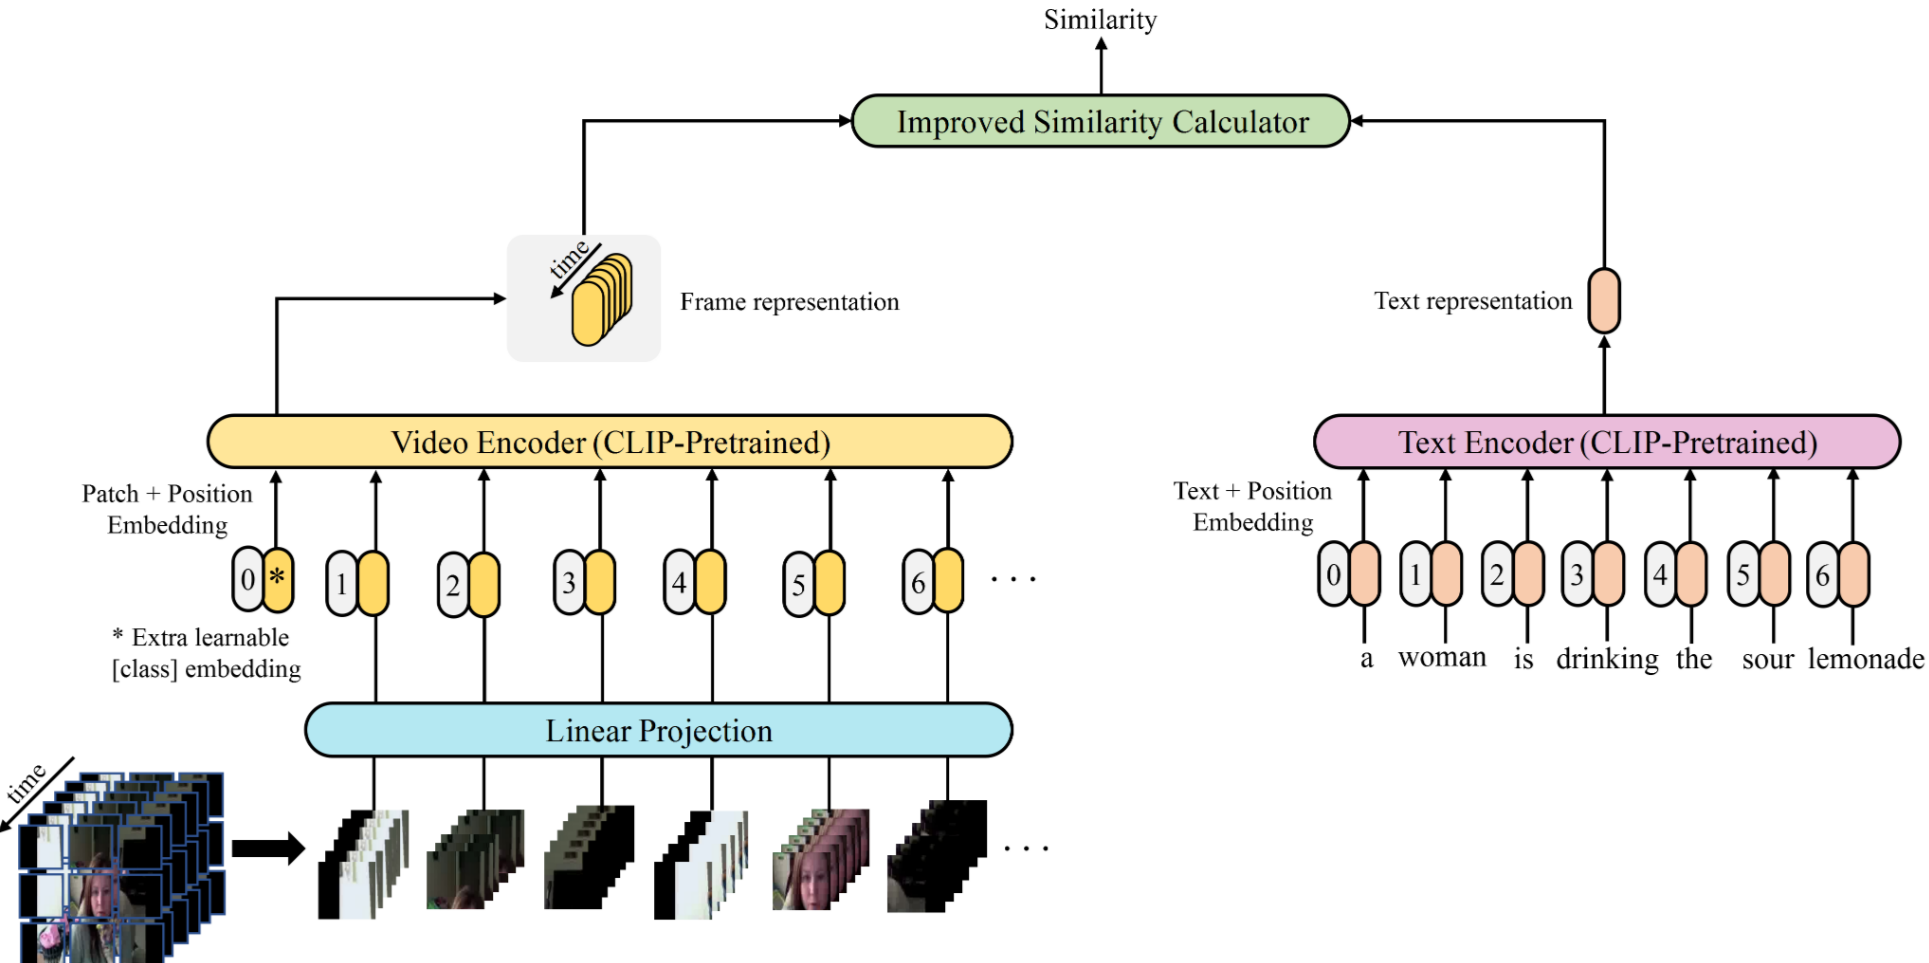

In [ ]:
def real_clip4clip_available():
    if not USE_REAL_MODEL:
        return False, "USE_REAL_MODEL=False (offline default)"
    if not (have("torch") and have("transformers")):
        return False, "USE_REAL_MODEL=True but torch/transformers absent"
    try:
        from transformers import (CLIPVisionModelWithProjection,
                                   CLIPTextModelWithProjection, CLIPTokenizer)
        n = "Searchium-ai/clip4clip-webvid150k"
        _ = CLIPVisionModelWithProjection.from_pretrained(n)   # network
        _ = CLIPTextModelWithProjection.from_pretrained(n)
        _ = CLIPTokenizer.from_pretrained(n)
        return True, "loaded"
    except Exception as e:
        return False, f"{type(e).__name__}: {str(e)[:80]}"

ok, why = real_clip4clip_available()
if ok:
    print("[real] CLIP4Clip encoders loaded — encode frames, mean-pool, "
          "L2-normalize, cosine-rank against a real TEXT embedding "
          "(genuine semantic retrieval).")
else:
    print(f"[skipped] real semantic retrieval unavailable ({why}).")
    print("Expected with weights: per-frame CLIP image_embeds -> mean over "
          "frames -> L2-normalize -> dot with a normalized TEXT embed -> "
          "top-k clips ranked by language similarity.")
    print("\n--- NON-SEMANTIC mechanics stand-in (clip-vs-clip, NOT text) ---")
    print("Embeddings are a fixed random projection of flow features; the "
          "query is another CLIP's embedding. Shows ONLY embed/normalize/"
          "dot/top-k plumbing.\n")

    rng  = np.random.default_rng(7)
    DIM  = 32
    PROJ = rng.standard_normal((7, DIM)).astype(np.float32)    # 7-D -> DIM
    def embed(clip):
        v = st_features(clip) @ PROJ                           # st_features is 7-D
        return v / (np.linalg.norm(v) + 1e-8)                  # L2 normalize

    # gallery: one prototype embedding per motion family
    gallery = {f"clip_{m}": embed(synth_clip(T=32, H=96, W=96,
                                             motion=m, seed=900 + i))
               for i, m in enumerate(CLASSES)}

    def reciprocal_rank(names, target):
        for i, n in enumerate(names, 1):
            if n == target:
                return 1.0 / i
        return 0.0

    # MANY held-out probes (jittered, unseen seeds) -> distributional metrics
    rows, per_motion = [], {m: [] for m in CLASSES}
    for m in CLASSES:
        for seed in range(1000, 1010):
            q = embed(synth_clip(T=32, H=96, W=96, motion=m,
                                 seed=seed, jitter=2.0))
            ranked = sorted(gallery.items(),
                            key=lambda kv: -float(q @ kv[1]))
            names  = [k for k, _ in ranked]
            tgt    = f"clip_{m}"
            r1 = names[0] == tgt
            r2 = tgt in names[:2]
            rr = reciprocal_rank(names, tgt)
            rows.append((r1, r2, rr)); per_motion[m].append(r1)

    R = np.array(rows, float)
    print(f"{len(R)} probe clips (10 per motion, jittered, unseen seeds) "
          f"vs a 4-item gallery:")
    print(f"  Recall@1 : {R[:,0].mean():.3f}")
    print(f"  Recall@2 : {R[:,1].mean():.3f}")
    print(f"  MRR      : {R[:,2].mean():.3f}   "
          f"(random baseline MRR ≈ {sum(1/i for i in range(1,5))/4:.3f})")
    print("  Recall@1 by motion: " +
          "  ".join(f"{m}={np.mean(per_motion[m]):.2f}" for m in CLASSES))
    print("  (distributional, not one cherry-picked ranking; still NON-"
          "semantic — clip-vs-clip, not text.)")


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

CLIPVisionModelWithProjection LOAD REPORT from: Searchium-ai/clip4clip-webvid150k
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
logit_scale                                                  | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: Searchium-ai/clip4clip-webvid150k
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
logit_scale                                                    | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encod

[real] CLIP4Clip encoders loaded — encode frames, mean-pool, L2-normalize, cosine-rank against a real TEXT embedding (genuine semantic retrieval).


## 9 · Recap — the shape cheat-sheet

Carry this table; the rest is detail.

| Stage | Object | Typical shape | Why it changes |
|---|---|---|---|
| Decoded clip | RGB frames | `(T, H, W, 3)` uint8 | raw; memory `∝ T·H·W·C` |
| Sampled | kept frames | `(T′, H, W, 3)`, `T′ ≪ T` | temporal redundancy |
| Resized | model input | `(T′, h, w, 3)`, e.g. `h=w=224` | spatial redundancy |
| Batched tensor | CNN input | `(B, C, T′, h, w)` | channels-first for conv3d |
| Patch tokens | ViT input | `(B, N, d)`, `N = T′·(h/P)·(w/P)` | sequence for attention |
| Tubelet tokens | ViViT input | `(B, N/t, d)` | depth-`t` cube ÷ token count |
| Per-frame flow | motion | `(T′-1, H, W, 2)` | `(u, v)` displacement |
| Clip embedding | retrieval | `(B, d)` L2-normalized | mean-pool + normalize |
| Class logits | classifier | `(B, n_classes)` | linear head on pooled token |

**Five things to remember**

1. Time is just another axis — but it multiplies memory and attention cost, so you
   *sample* before you model.
2. Single-frame methods are blind to order; "opening" vs. "closing" needs temporal
   modeling.
3. Full 3-D conv's kernel footprint is `∝ k³`; factorized `(2+1)D` is `∝ k²+k` for the
   same receptive field (multiply by channels for the true param/FLOP budget — see §4b).
4. Token count `N` is the lever for a video Transformer — patch size `P` and tubelet
   depth `t` set it; attention is `O(N²)`, hence divided space-time attention.
5. Retrieval = shared embedding space + unit-norm + dot product; classification = pooled
   token + linear head + an *honest held-out metric*.

### One-cell shape debugger

The recurring theme of this notebook is *controlling shape, memory, and time*. This cell
prints every major tensor transformation in one place so you can see the whole pipeline's
shapes at a glance (it reads variables already created above).

In [ ]:
def show_shape(name, x, extra=""):
    try:
        a = np.asarray(x)
        print(f"{name:<26} shape={str(a.shape):<22} dtype={str(a.dtype):<8}"
              f" {a.nbytes/1e6:8.3f} MB  {extra}")
    except Exception as e:
        print(f"{name:<26} <unavailable: {type(e).__name__}>")

banner("Shape / memory trace (raw -> model-ready)")
show_shape("raw clip CLIP",        CLIP,                 "decoded RGB frames")
show_shape("sampled (uniform)",    CLIP[u_idx],          "temporal redundancy -> fewer T")
show_shape("sampled + resized",    samp_resized,         "spatial redundancy -> smaller H,W")
show_shape("CNN tensor (B,C,T,H,W)",
           np.transpose(samp_resized, (3, 0, 1, 2))[None],"channels-first for conv3d")
show_shape("patch grid (gh,gw,P,P,C)", grid,             f"{grid.shape[0]*grid.shape[1]} patch tokens/frame")
_tok = grid.shape[0] * grid.shape[1]
show_shape("patch tokens (B,N,d)",
           np.zeros((1, _tok, 768), np.float32),          "ViT sequence (d=768 example)")
show_shape("tubelet tokens (depth 2)",
           np.zeros((1, _tok * (len(samp_resized)//2), 768), np.float32),
           "tubelet ÷ depth-t token count")
show_shape("per-frame flow",       flow[None],           "(u,v) displacement field")
show_shape("clip embedding (B,d)", np.zeros((1, 32), np.float32),
           "L2-normalized for retrieval")
show_shape("class logits (B,K)",   np.zeros((1, len(LABELS8)), np.float32),
           f"{len(LABELS8)}-way head")


Shape / memory trace (raw -> model-ready)
raw clip CLIP              shape=(40, 112, 112, 3)      dtype=uint8       1.505 MB  decoded RGB frames
sampled (uniform)          shape=(8, 112, 112, 3)       dtype=uint8       0.301 MB  temporal redundancy -> fewer T
sampled + resized          shape=(8, 64, 64, 3)         dtype=uint8       0.098 MB  spatial redundancy -> smaller H,W
CNN tensor (B,C,T,H,W)     shape=(1, 3, 8, 64, 64)      dtype=uint8       0.098 MB  channels-first for conv3d
patch grid (gh,gw,P,P,C)   shape=(7, 7, 16, 16, 3)      dtype=uint8       0.038 MB  49 patch tokens/frame
patch tokens (B,N,d)       shape=(1, 49, 768)           dtype=float32     0.151 MB  ViT sequence (d=768 example)
tubelet tokens (depth 2)   shape=(1, 196, 768)          dtype=float32     0.602 MB  tubelet ÷ depth-t token count
per-frame flow             shape=(1, 112, 112, 2)       dtype=float32     0.100 MB  (u,v) displacement field
clip embedding (B,d)       shape=(1, 32)                dtype=float32 

> **What this notebook is *not*.** It teaches video-tensor mechanics: shape/memory
> budgeting, redundancy, sampling, optical flow, 3-D vs. factorized conv cost, patch/tubelet
> tokenization, and honest evaluation methodology. It is **not** a benchmark of modern video
> foundation models — the offline default uses deterministic synthetic clips so every result
> is reproducible and every claim is checkable. The guarded VideoMAE / CLIP4Clip cells show
> *where* a real backbone plugs in and *what shapes* it consumes, not state-of-the-art
> numbers.

## 10 · Production video pipeline checklist

The notebook is modeling-centric; a shippable system wraps the same shape transformations
in operational concerns:

1. **Decode** — container/codec handling, fps normalization, keyframe-aware seeking,
   corrupt-stream fallbacks.
2. **Sample** — uniform vs. segment (TSN-style) vs. event-/shot-aware; fixed seed for
   reproducibility; bound max frames per clip.
3. **Transform** — resize/crop, normalize to the backbone's stats, channels-first batch
   layout, consistent dtype.
4. **Model** — 2-D CNN per frame, 3-D CNN, TimeSformer/ViViT/VideoMAE, or a video–language
   model; pick by latency/accuracy budget.
5. **Postprocess** — temporal aggregation (mean/attention pool), class smoothing,
   thresholds, dedupe across overlapping windows.
6. **Evaluate & monitor** — task-appropriate metric (see §8 note), plus latency,
   throughput, cost, and input-drift checks in production.

## 11 · Troubleshooting

| Symptom | Likely cause | Fix |
|---|---|---|
| `cv2.VideoCapture` opens but `read()` returns `False` immediately | seeking landed between keyframes / bad codec | decode sequentially from a keyframe; install `ffmpeg`/`pyav`; re-encode to H.264 |
| Sampled frames look duplicated | stride finer than scene change; pulled the same GOP | increase stride, or switch to segment / motion-aware sampling |
| Optical flow is all zeros or explodes | frames identical, or huge motion vs. window | check consecutive-frame MAE first; tune Farneback `winsize`/`levels`; convert to gray |
| `[skipped] USE_REAL_MODEL=False` | offline default | expected; set `USE_REAL_MODEL=True` in §0 with a local weights cache / `HF_HOME` |
| `[skipped] model/weights unavailable` | no network / blocked host even with flag on | provide a local weights cache or `HF_HOME`, then re-run that cell |
| `ImportError: Missing REQUIRED packages` in §0 | core dep absent in a fresh env | run the matching `%pip install` line in the install cell, restart kernel |
| 3-D CNN OOM | clip too long for `k³` memory | fewer frames, smaller `h,w`, or factorized `(2+1)D` / a Transformer backbone |
| Transformer slow / OOM | token count `N` too large | larger patch `P`, tubelet depth `t>1`, fewer frames; prefer divided attention |
| Classifier accuracy ≈ chance | features carry no temporal info (the §7 frame-only case) | use order-sensitive features (flow, temporal gradients), not per-frame stats |
| Retrieval ranks look random | embeddings not L2-normalized before dot product | normalize **both** video and text vectors; cosine == dot on unit vectors |

## 12 · Student exercise

§7 already shows the *direction × speed* story. Push it one rung harder so a single hand-set
feature can no longer save you:

1. **Add an occlusion or camera-jitter nuisance.** Extend `synth_clip` with either a
   moving occluder rectangle that briefly hides the disc, or a global per-frame translation
   (camera shake) that adds a *common-mode* flow to every pixel.
2. **Show the regression.** Re-run model **C** (the 7-D augmented features) and demonstrate
   that camera shake inflates `mean dx/dy` (it now measures camera, not object) so
   *direction* accuracy degrades — read it off the confusion matrix.
3. **Engineer a fix.** Make the motion descriptor robust: subtract the per-frame *median*
   flow (a crude global-motion estimate) before computing statistics, or switch to
   flow **relative to the frame median**. Report the recovered held-out accuracy.
4. **Add a retrieval metric.** Build a tiny gallery with the §8 stand-in and report
   **Recall@1** and **MRR** over several held-out probe clips (not just one), so the
   metric is a distribution, not an anecdote.
5. **Write-up (4–5 sentences):** which features track the *object* vs. the *camera*, why
   global-motion compensation is the standard preprocessing step before flow-based
   features, and which §11 row your failure corresponds to.

*Stretch:* set `USE_REAL_MODEL=True` on a machine with weights, run the guarded VideoMAE
path, map its Kinetics logits to your labels via nearest-prototype, and compare to model C.

## 13 · References & further reading

Models / methods touched in this notebook (search by title for the canonical paper):

* **TimeSformer** — *Is Space-Time Attention All You Need for Video Understanding?*
  (Bertasius, Wang, Torresani, 2021) — divided space-time attention.
* **ViViT** — *ViViT: A Video Vision Transformer* (Arnab et al., 2021) — factorized
  encoders + tubelet embeddings.
* **VideoMAE** — *VideoMAE: Masked Autoencoders are Data-Efficient Learners for
  Self-Supervised Video Pre-Training* (Tong et al., 2022) — tubelet tokens + MAE.
* **R(2+1)D** — *A Closer Look at Spatiotemporal Convolutions for Action Recognition*
  (Tran et al., 2018) — the (2+1)D factorization.
* **TSN** — *Temporal Segment Networks* (Wang et al., 2016) — segment-based sampling.
* **Farnebäck optical flow** — *Two-Frame Motion Estimation Based on Polynomial Expansion*
  (Farnebäck, 2003) — the dense-flow algorithm used here.
* **CLIP4Clip** — *CLIP4Clip: An Empirical Study of CLIP for End-to-End Video Clip
  Retrieval* (Luo et al., 2021) — mean-pooled CLIP video retrieval.
* **Kinetics** — *The Kinetics Human Action Video Dataset* (Kay et al., 2017) — the 400-way
  label space of the guarded VideoMAE demo.

Library docs: OpenCV `calcOpticalFlowFarneback`, Hugging Face `transformers`
(`VideoMAEForVideoClassification`, CLIP), scikit-learn `LogisticRegression` /
`confusion_matrix`.

---
*End of notebook. Re-run top-to-bottom anytime — the default path is fully deterministic
and offline (`USE_REAL_VIDEO = USE_REAL_MODEL = False`).*